### **ADA Final Exam**

**Course:** Applied Data Analysis (ADA)  
**Name:** Riya Shyam Huddar  
**Roll Number:** MDS202431   
**Date:** 08/12/2025  


### Problem 1: Economic Mobility and Community Characteristics  
### Analysis of the Relationship Between Short Commutes and Upward Mobility  

This dataset contains information on 729 U.S. communities, including their levels of upward economic mobility, average commuting characteristics, and geographic location. The goal of this analysis is to determine whether communities with shorter average commute times tend to exhibit higher economic mobility.

The key outcome variable is **Mobility**, defined as the probability that a child born to a family in the lowest income quintile (1980–1982 cohorts) reaches the highest income quintile by age 30.  
The primary predictor of interest is **Commute**, measured as the fraction of workers with a commute of less than 15 minutes. Additional variables (Latitude, Longitude, State, and Name) provide geographic and contextual information.

### **Dataset Overview**

We begin by loading the dataset containing information on **729 U.S. communities**, constructed from a large study of intergenerational economic mobility based on linked tax records. Because individual data are confidential, all variables are aggregated at the community level.

The dataset includes the following key variables:

- **Mobility** — Probability that a child born into the lowest income quintile (1980–1982 cohorts) reaches the highest income quintile by age 30.  
- **Commute** — Fraction of workers in the community whose commute time is less than 15 minutes.  
- **Name** — Name of the principal town or city representing the community.  
- **State** — U.S. state in which the community is located.  
- **Latitude** and **Longitude** — Geographic coordinates of the community center.

Our main research question is:

> **Do communities with shorter commute times exhibit higher rates of upward economic mobility?**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load data
df = pd.read_csv("D:/CMI/ADA/ADA_Final_exam/mobility.csv")
df.head()


,Unnamed: 0,Name,Mobility,State,Commute,Longitude,Latitude
0,1,Johnson City,0.062199,TN,0.325,-82.436386,36.470371
1,2,Morristown,0.053652,TN,0.276,-83.407249,36.096539
2,3,Middlesborough,0.072635,TN,0.359,-83.535332,36.551540
3,4,Knoxville,0.056281,TN,0.269,-84.242790,35.952259
4,5,Winston-Salem,0.044801,NC,0.292,-80.505333,36.081276


In [ ]:
df = df.drop(columns=['Unnamed: 0'])
df.head()


,Name,Mobility,State,Commute,Longitude,Latitude
0,Johnson City,0.062199,TN,0.325,-82.436386,36.470371
1,Morristown,0.053652,TN,0.276,-83.407249,36.096539
2,Middlesborough,0.072635,TN,0.359,-83.535332,36.551540
3,Knoxville,0.056281,TN,0.269,-84.242790,35.952259
4,Winston-Salem,0.044801,NC,0.292,-80.505333,36.081276


### **Exploratory Data Analysis**

We begin by examining the structure and quality of the dataset.

**Dataset structure**
- The dataset contains **729 communities** and **6 variables**.
- All variables are complete: **no missing values**.
- There are **4 numeric columns** (Mobility, Commute, Latitude, Longitude) and **2 categorical columns** (Name, State).

**Key summary statistics**
- **Mobility** ranges from 0.022 to 0.470, with a mean of 0.10.
- **Commute** (fraction with <15 min commute) ranges from 0.156 to 0.928, with a mean of 0.45.
- Geographic coordinates span a wide range, reflecting broad national coverage.

**State representation**
- The dataset covers **51 states**, with Texas having the largest number of communities (63), followed by Kansas (31) and Georgia (28).

These initial checks confirm that the dataset is clean and suitable for further visualization and modeling.


In [ ]:
# Initial EDA checks
print("Filename / load check: df.shape =", df.shape)
print("\n--- df.info() ---")
df.info()

print("\n--- Summary statistics (numeric) ---")
display(df.describe().T)

print("\n--- Missing values ---")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0] if missing.any() else missing)

print("\n--- Unique value counts for key columns ---")
print("States:", df['State'].nunique(), "unique states")
print(df['State'].value_counts().head(10))

print("\n--- Column names ---")
print(df.columns.tolist())


Filename / load check: df.shape = (729, 6)

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729 entries, 0 to 728
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Name       729 non-null    object 
 1   Mobility   729 non-null    float64
 2   State      729 non-null    object 
 3   Commute    729 non-null    float64
 4   Longitude  729 non-null    float64
 5   Latitude   729 non-null    float64
dtypes: float64(4), object(2)
memory usage: 34.3+ KB

--- Summary statistics (numeric) ---


,count,mean,std,min,25%,50%,75%,max
Mobility,729.0,0.100423,0.052654,0.022102,0.065985,0.089506,0.119403,0.469697
Commute,729.0,0.453513,0.140170,0.156000,0.344000,0.430000,0.557000,0.928000
Longitude,729.0,-95.291025,14.921167,-170.719665,-101.241379,-93.456833,-84.777367,-67.605003
Latitude,729.0,38.942584,6.029115,19.578831,34.760551,38.826611,42.738071,68.371017



--- Missing values ---


Name         0
Mobility     0
State        0
Commute      0
Longitude    0
Latitude     0
dtype: int64


--- Unique value counts for key columns ---
States: 51 unique states
State
TX    63
KS    31
GA    28
MO    24
MN    23
SD    23
IA    22
NC    21
NE    21
KY    21
Name: count, dtype: int64

--- Column names ---
['Name', 'Mobility', 'State', 'Commute', 'Longitude', 'Latitude']


### **Distribution of Mobility**

The distribution of the **Mobility** variable is right-skewed, with most communities having mobility values between 0.05 and 0.15. A small number of communities exhibit substantially higher mobility (above 0.20), creating a long upper tail. This skew suggests that high-mobility communities are relatively rare, while the majority fall within a lower, tighter range.


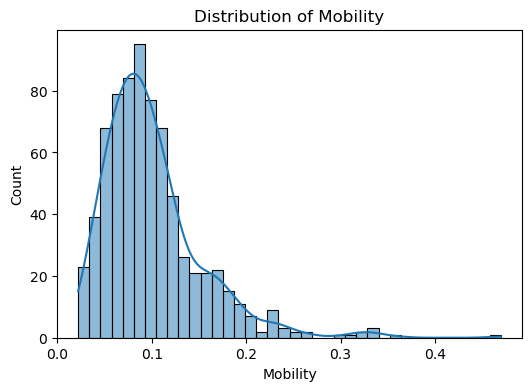

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['Mobility'], kde=True)
plt.title("Distribution of Mobility")
plt.show()


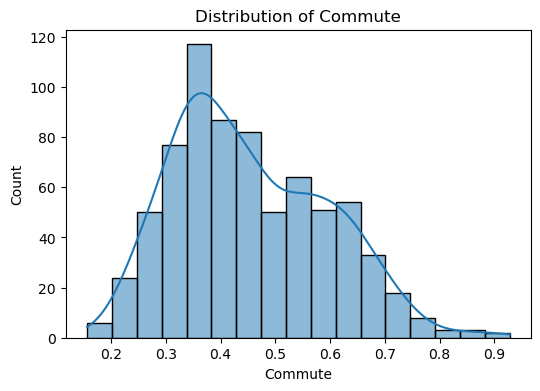

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Commute'], kde=True)
plt.title("Distribution of Commute")
plt.show()


### **Commute vs. Mobility by State**

The scatterplot of **Mobility** versus **Commute**, with points colored by **State**, helps reveal potential regional differences in the relationship.

Key observations:

- Communities with similar commute fractions sometimes exhibit noticeably different mobility levels, suggesting **state-level heterogeneity**.
- Clusters of states appear in different regions of the plot, indicating possible **geographic or policy-related influences**.
- Coloring by state makes it easier to spot groups, overlaps, and outliers that would not be visible in an uncolored scatterplot.

This visualization complements the correlation analysis by highlighting geographic patterns and potential sources of variation across states.


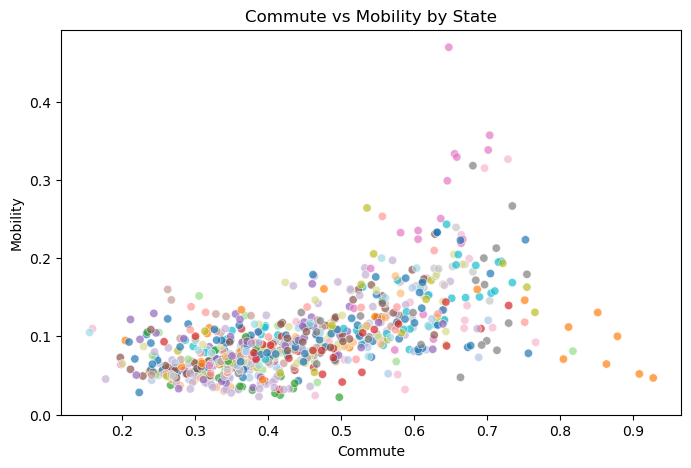

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Commute', y='Mobility', hue='State', data=df, legend=None, palette='tab20', alpha=0.7)
plt.title("Commute vs Mobility by State")
plt.show()


### **Initial Correlation Observations**

The correlation heatmap reveals the following key relationships:

- **Mobility and Commute** show a moderately strong positive correlation (≈ 0.59), indicating that communities with a higher share of short commutes tend to exhibit higher economic mobility.
- **Commute and Longitude** exhibit a moderately strong negative correlation (≈ –0.50), suggesting that short commutes are more common in central and eastern regions of the U.S.

These correlations establish an initial link between commute patterns and mobility while also hinting at underlying geographic structure.


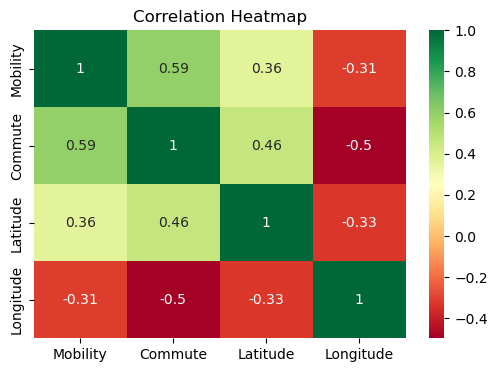

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Mobility','Commute','Latitude','Longitude']].corr(),
            annot=True, cmap='RdYlGn')
plt.title("Correlation Heatmap")
plt.show()


### Top and Bottom States by Average Mobility

From the state-level average Mobility analysis:

- **Top 3 states** with highest average mobility:
    1. ND (North Dakota)
    2. WY (Wyoming)
    3. NE (Nebraska)

- **Bottom 3 states** with lowest average mobility:
    1. MS (Mississippi)
    2. GA (Georgia)
    3. SC (South Carolina)

This highlights the geographic variation in economic mobility across the United States.


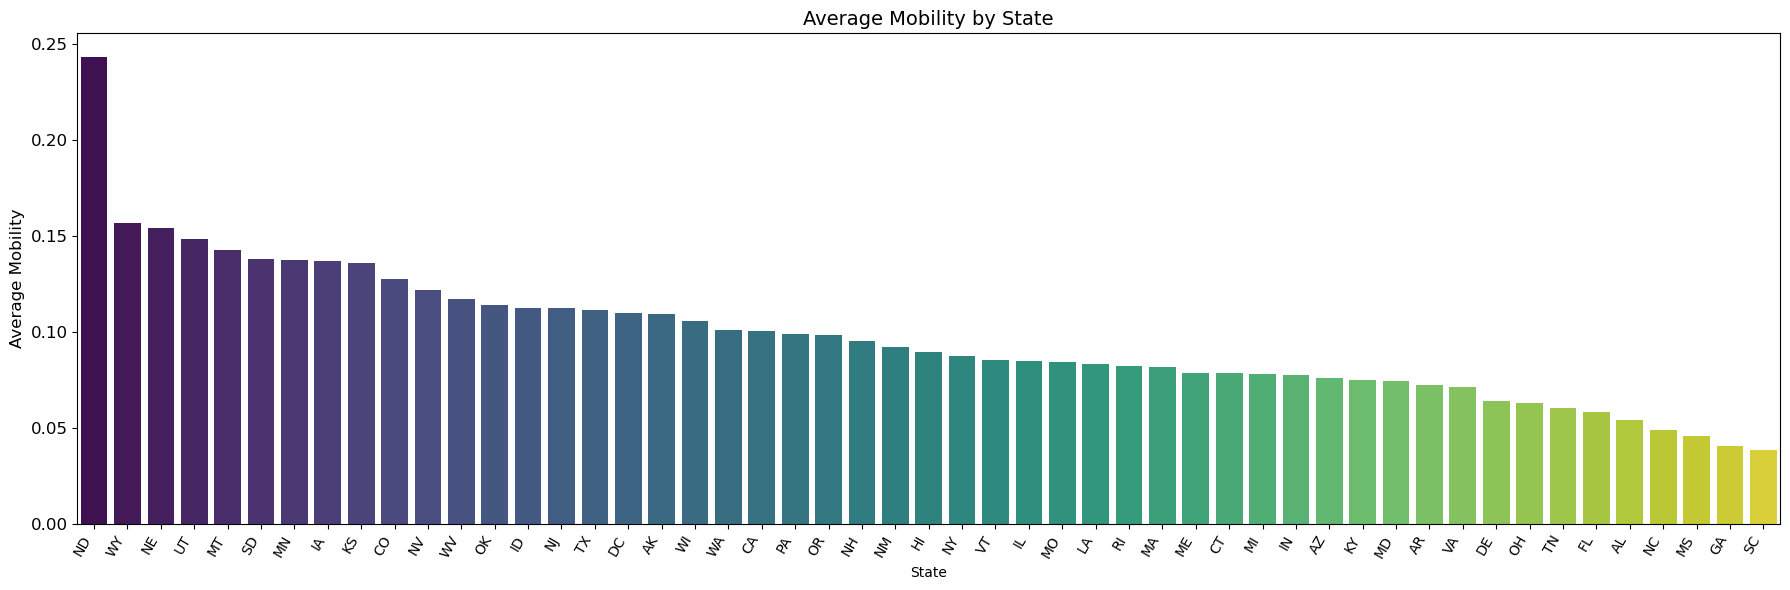

In [ ]:
state_means = df.groupby('State')['Mobility'].mean().sort_values(ascending=False)

# Convert Series to DataFrame for seaborn
state_means_df = state_means.reset_index()
state_means_df.columns = ['State', 'Avg_Mobility']

plt.figure(figsize=(18,6))  # make figure wider
sns.barplot(
    x='State',
    y='Avg_Mobility',
    data=state_means_df,
    palette='viridis',
    hue='State'
)
plt.xticks(rotation=60, ha='right', fontsize=10)  # increase font size
plt.yticks(fontsize=12)
plt.ylabel("Average Mobility", fontsize=12)
plt.title("Average Mobility by State", fontsize=14)
plt.tight_layout()
plt.show()


### **Geographic Distribution of Mobility**

The scatterplot maps Mobility across U.S. communities using their geographic coordinates, with lighter colors indicating lower mobility and darker colors indicating higher mobility.

A few broad spatial patterns emerge:

- Communities at **lower latitudes** (more southern regions) generally show **darker colors**, indicating **lower mobility** in much of the South.
- Mobility also tends to be lower in areas with **less negative longitudes** (farther east), consistent with lighter shading in eastern regions.
- Although these patterns are not extremely sharp, the plot suggests **geographic gradients** in mobility that align with other summaries and correlations.

Overall, mobility is not evenly distributed across the country, and regional differences appear to play a meaningful role.


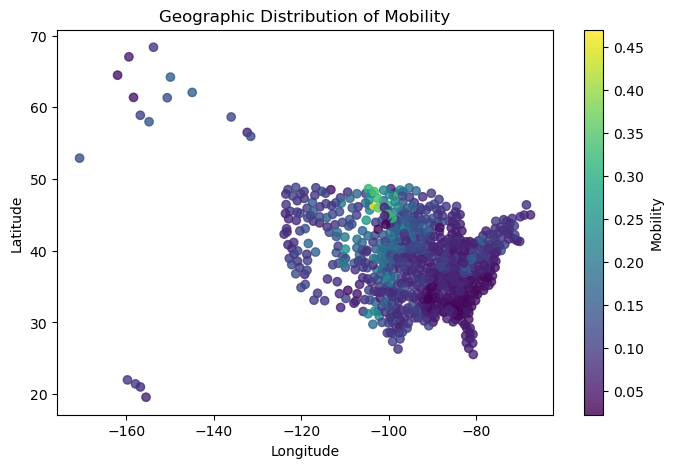

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Longitude'], df['Latitude'], c=df['Mobility'], cmap='viridis', alpha=0.8)
plt.colorbar(label='Mobility')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Mobility")
plt.show()


### **Outlier Analysis: Mobility vs. Commute**

To assess variability in the dataset, we examined the distributions of **Mobility** and **Commute**. The two variables show very different levels of dispersion.

#### **1. Mobility Shows Noticeable Outliers**
Mobility exhibits several extreme high and low values, indicating substantial variation across communities. These outliers likely reflect:

- demographic or economic differences,
- geographic disparities, or
- structural factors affecting opportunity.

Because Mobility varies widely, it is a **high-variance variable**, which may influence correlation strength and model stability.

#### **2. Commute Has Very Few Outliers**
Commute values are tightly clustered, with almost no extreme observations. This suggests:

- relatively stable commuting patterns across communities,
- a more predictable distribution,
- less risk of unusual or noisy values.

Commute can therefore be treated as a **low-variance, reliable predictor**.

#### **3. Key Insight**
Mobility is considerably more volatile than Commute. This difference means that models predicting Mobility need to account for its wider spread, while Commute provides a stable explanatory variable with minimal outlier influence.


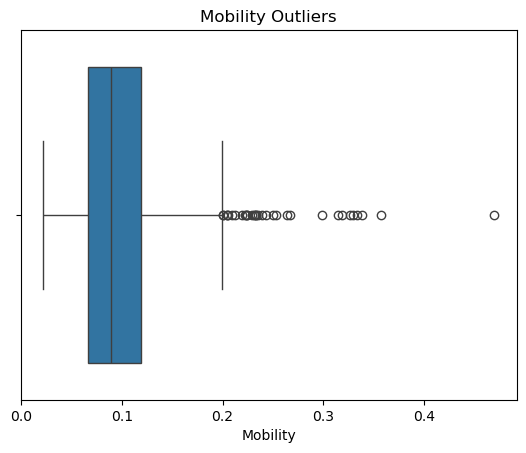

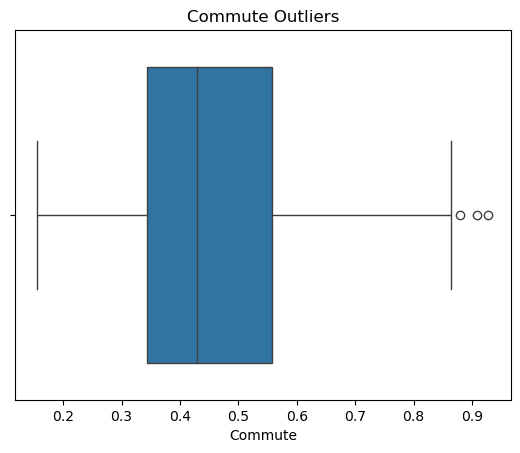

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Mobility'])
plt.title("Mobility Outliers")
plt.show()

sns.boxplot(x=df['Commute'])
plt.title("Commute Outliers")
plt.show()


-----

### **Model Diagnostics and Assumption Checks**

### **Checking the Linearity Assumption**

Before fitting a linear regression model, we first assess whether the relationship between **Commute** (fraction of workers with <15-minute commutes) and **Mobility** is approximately linear.

A scatterplot of Mobility vs. Commute with a fitted regression line shows a clear upward trend, with no strong curvature or systematic deviations. The points are reasonably dispersed around the line, suggesting that a **linear form is an appropriate starting point**.

In the next step, we examine residual plots to verify whether remaining deviations appear random, which is necessary for the validity of linear regression inference.


### **Simple Linear Regression: Mobility ~ Commute**

We first fit a simple linear regression model using **Mobility** as the dependent variable and **Commute** as the sole predictor:

$$
\text{Mobility} = \beta_0 + \beta_1 \cdot \text{Commute} + \epsilon.
$$

**Key results:**

- **Intercept (β₀):** –0.0002 (not statistically significant)  
- **Commute coefficient (β₁):** 0.2219, highly significant (p < 0.001)  
- **R² = 0.349**, meaning that commute alone explains about **35%** of the variation in mobility.

**Interpretation**

- Communities with a higher share of short commutes tend to have **higher economic mobility**.  
- A 0.10 increase in the fraction of workers with short commutes corresponds to an estimated **0.022 increase in Mobility**.  
- The near-zero intercept is reasonable given both variables are proportions.  
- Although the effect is strong and statistically significant, most variation in mobility remains unexplained, indicating the need to consider additional factors such as geography or state-level characteristics.


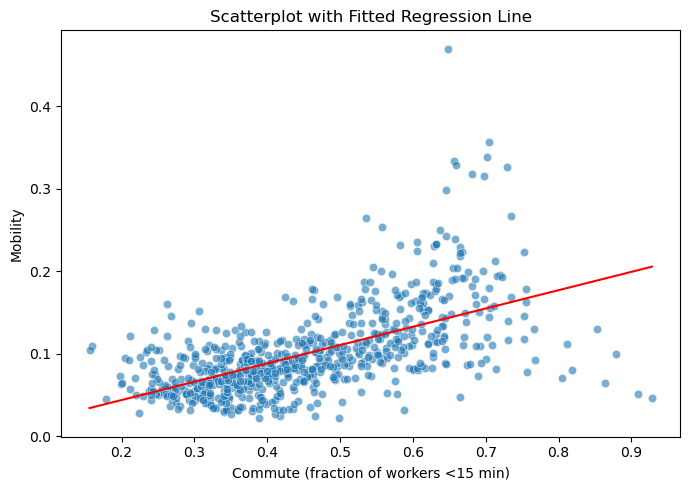

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Mobility   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     389.5
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           9.38e-70
Time:                        12:13:13   Log-Likelihood:                 1268.7
No. Observations:                 729   AIC:                            -2533.
Df Residuals:                     727   BIC:                            -2524.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.005     -0.037      0.971      -0.011       0.010
Commute        0.2219      0.011     19.735      0.000       0.200       0.244
==============================================================================
Omnibus:                      265.914   Durbin-Watson:                   1.354
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1989.480
Skew:                           1.440   Prob(JB):                         0.00
Kurtosis:                      10.563   Cond. No.                         8.63
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Simple linear regression: Mobility ~ Commute
X = sm.add_constant(df['Commute'])
y = df['Mobility']

model_simple = sm.OLS(y, X).fit()

# Scatter + fitted line
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['Commute'], y=df['Mobility'], alpha=0.6)
sns.lineplot(
    x=df['Commute'],
    y=model_simple.predict(X),
    color='red'
)
plt.xlabel("Commute (fraction of workers <15 min)")
plt.ylabel("Mobility")
plt.title("Scatterplot with Fitted Regression Line")
plt.tight_layout()
plt.show()

model_simple.summary()


### **Multiple Linear Regression: Adding Geographic Controls**

To assess whether the relationship between **Commute** and **Mobility** persists after accounting for geography, we extend the model to include **Longitude** and **Latitude**:

$$
\text{Mobility} = \beta_0 + \beta_1 \cdot \text{Commute} + \beta_2 \cdot \text{Longitude} + \beta_3 \cdot \text{Latitude} + \epsilon.
$$

**Key results:**

- **Commute (β₁ = 0.2010, p < 0.001):**  
  Remains a strong and highly significant predictor of mobility even after controlling for spatial location.  
  The effect size decreases slightly from the simple model (0.222 → 0.201), but the positive association remains robust.

- **Longitude (β₂ ≈ 0, p = 0.725):**  
  Not statistically significant; east–west location does not meaningfully explain mobility.

- **Latitude (β₃ = 0.0009, p = 0.002):**  
  A small but significant positive effect, suggesting mobility is marginally higher in more northern communities.

- **Model fit:**  
  - **R² = 0.358**, a slight improvement over the simple model (0.349).  
  - Adding geography improves the model only modestly.

**Interpretation**

Even after adjusting for geographic location, communities with a higher share of workers who commute less than 15 minutes continue to exhibit **higher upward economic mobility**. Geography explains only a small portion of the variation, and the core relationship between commute patterns and mobility remains strong.



In [ ]:
# One-hot encode State and make sure numeric
#state_dummies = pd.get_dummies(df['State'], drop_first=True).astype(float)

# Combine numeric predictors with state dummies
X_full = pd.concat([df[['Commute', 'Longitude', 'Latitude']]], axis=1)
X_full = sm.add_constant(X_full).astype(float)  # add intercept and ensure float
y = df['Mobility']

# Fit full model
model_full = sm.OLS(y, X_full).fit()

# Summary
model_full.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Mobility   R-squared:                       0.358
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     134.9
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           1.84e-69
Time:                        17:08:25   Log-Likelihood:                 1274.0
No. Observations:                 729   AIC:                            -2540.
Df Residuals:                     725   BIC:                            -2522.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0314      0.013     -2.468      0.014      -0.056      -0.006
Commute        0.2010      0.014     14.546      0.000       0.174       0.228
Longitude  -4.305e-05      0.000     -0.353      0.725      -0.000       0.000
Latitude       0.0009      0.000      3.175      0.002       0.000       0.002
==============================================================================
Omnibus:                      255.703   Durbin-Watson:                   1.338
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2057.418
Skew:                           1.349   Prob(JB):                         0.00
Kurtosis:                      10.775   Cond. No.                         976.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **Heteroscedasticity Check (Breusch–Pagan Test)**

To determine whether OLS inference is valid, we check the assumption of **constant error variance**. Residual plots suggested a possible increase in variability with fitted values, so we formally test this using the **Breusch–Pagan test**.

#### **Breusch–Pagan Test Results**
**Simple Model (Mobility ~ Commute):**
- LM = **59.47**, p = **1.24e-14**
- F = **64.57**, p = **3.77e-15**

**Full Model (Commute + Longitude + Latitude):**
- LM = **78.67**, p = **5.91e-17**
- F = **29.24**, p = **7.50e-18**

#### **Interpretation**
Both models yield extremely small p-values, so we **reject the null hypothesis of homoscedasticity**.  
This confirms that the variance of residuals is **not constant**, consistent with the funnel shape seen in residual-vs-fitted plots.

#### **Why This Matters**
Heteroscedasticity:
- **does not bias** OLS coefficient estimates,  
- but **invalidates the usual standard errors, p-values, and confidence intervals**.

Because our goal is to make meaningful statistical conclusions, we **cannot rely solely on standard OLS inference**.  
Therefore, in the next step, we refit the models using **heteroscedasticity-robust (HC3) standard errors** to ensure valid inference.


In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

# --- Simple Model ---
bp_simple = het_breuschpagan(model_simple.resid, model_simple.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("Breusch-Pagan Test (Simple Model):")
print(dict(zip(labels, bp_simple)))
print("\n")

# --- Full Model ---
bp_full = het_breuschpagan(model_full.resid, model_full.model.exog)
print("Breusch-Pagan Test (Full Model):")
print(dict(zip(labels, bp_full)))


Breusch-Pagan Test (Simple Model):
{'LM Statistic': 59.46504037433005, 'LM-Test p-value': 1.2448603312002655e-14, 'F-Statistic': 64.56882307730127, 'F-Test p-value': 3.7662765768083295e-15}


Breusch-Pagan Test (Full Model):
{'LM Statistic': 78.67468713150824, 'LM-Test p-value': 5.9058834427922e-17, 'F-Statistic': 29.236213036596496, 'F-Test p-value': 7.500718578428e-18}


### **Residual Independence Check (Durbin–Watson Test)**

To assess whether the regression residuals are independent, we compute the **Durbin–Watson (DW)** statistic for both models.

- **Simple Model:** DW = **1.354**  
- **Full Model:** DW = **1.338**

Both values are noticeably below the ideal value of **2**, indicating **positive autocorrelation** in the residuals. Adding geographic controls does not meaningfully improve the statistic, suggesting that the dependence structure is likely due to **spatial clustering or omitted regional factors**, rather than issues that can be resolved by minor model adjustments.

**Implication:**  
Because the independence assumption is violated, standard OLS inference may be unreliable. This further motivates the use of **robust standard errors** and highlights that mobility data may have an inherent spatial structure not fully captured by the predictors included so far.


In [ ]:
from statsmodels.stats.stattools import durbin_watson

# Durbin-Watson for simple model
dw_simple = durbin_watson(model_simple.resid)
print(f"Durbin-Watson (Simple Model): {dw_simple:.3f}")

# Durbin-Watson for full model
dw_full = durbin_watson(model_full.resid)
print(f"Durbin-Watson (Full Model): {dw_full:.3f}")


Durbin-Watson (Simple Model): 1.354
Durbin-Watson (Full Model): 1.338


### **Residual Diagnostics: Residuals vs Fitted and QQ Plots**

To assess whether the assumptions of linear regression hold, we examine **Residuals vs Fitted** plots and **QQ plots** for both the simple and full models.

The **Residuals vs Fitted plot** for the simple model shows a slight increase in the spread of residuals as fitted values rise. In the **full model**, this funnel shape becomes even more pronounced, indicating that the variance of the residuals **increases with predicted mobility**. This is a clear sign of **heteroscedasticity**, violating the OLS assumption of constant variance.

This visual evidence aligns with our earlier **Breusch–Pagan test**, which strongly rejected the assumption of homoscedasticity for both models:

- Simple Model: p ≈ 1.2e-14  
- Full Model: p ≈ 5.9e-17  

The **QQ plots** also show deviations from the straight 45° line, especially in the tails, indicating that residuals are not perfectly normally distributed.

Together, these diagnostics suggest that while a linear model may capture the broad trend, some of the standard OLS assumptions—particularly constant variance and normality of errors—are not fully satisfied.


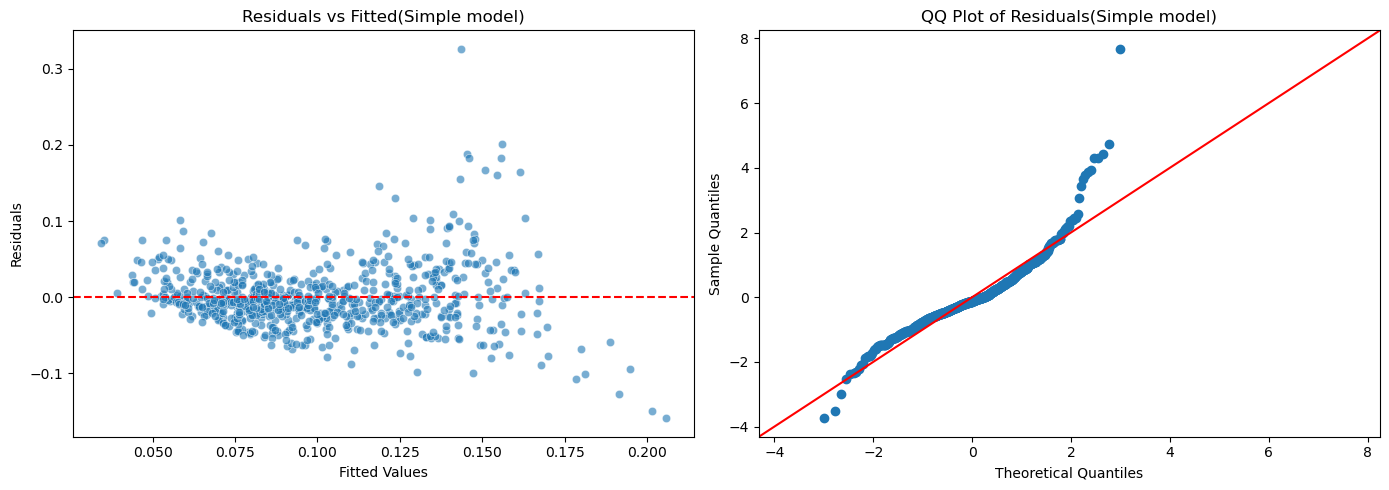

In [ ]:
# --- Residuals vs Fitted and QQ plot ---

# Predicted values and residuals
fitted_vals = model_simple.fittedvalues
residuals = model_simple.resid

plt.figure(figsize=(14,5))

# Residuals vs Fitted
plt.subplot(1,2,1)
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted(Simple model)")

# QQ plot
plt.subplot(1,2,2)
import statsmodels.api as sm
ax = plt.gca()  # get current axes
sm.qqplot(residuals, line='45', ax=ax, fit=True)
plt.title("QQ Plot of Residuals(Simple model)")

plt.tight_layout()
plt.show()


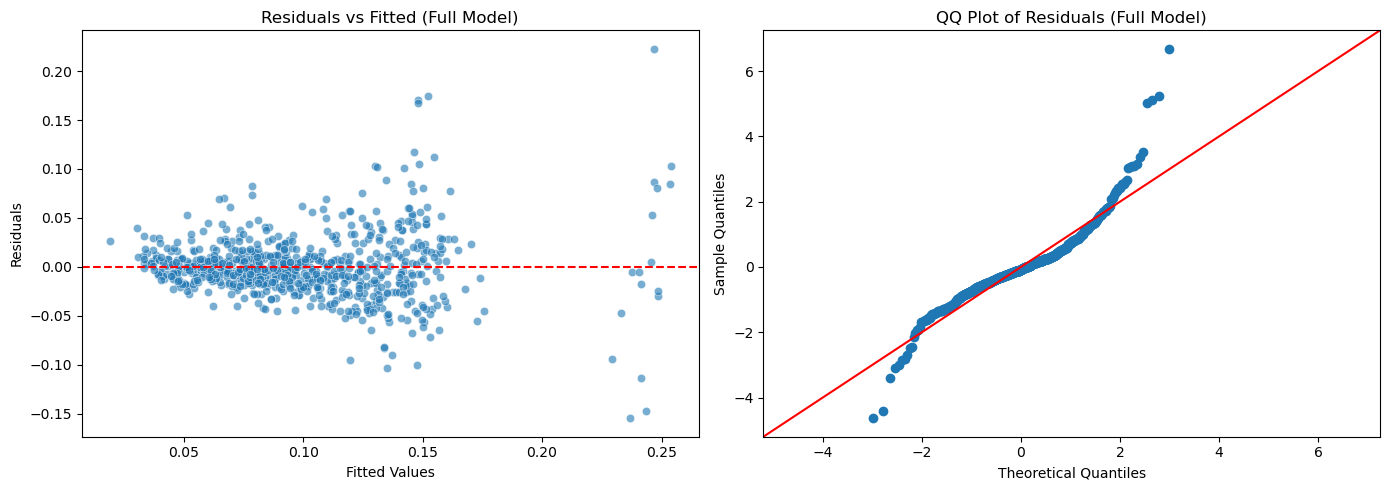

In [ ]:
# Predicted values and residuals for full model
fitted_vals_full = model_full.fittedvalues
residuals_full = model_full.resid

plt.figure(figsize=(14,5))

# Residuals vs Fitted
plt.subplot(1,2,1)
sns.scatterplot(x=fitted_vals_full, y=residuals_full, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Full Model)")

# QQ plot with specified axes
plt.subplot(1,2,2)
sm.qqplot(residuals_full, line='45', fit=True, ax=plt.gca())
plt.title("QQ Plot of Residuals (Full Model)")

plt.tight_layout()
plt.show()


----

### **Modeling and Inference**

### **Model Performance and OLS Assumption Check**

To compare predictive accuracy, we compute mean squared error (MSE) and root mean squared error (RMSE) for both the simple and full models.

**Predictive Performance**

| Model                                   | MSE        | RMSE      |
|-----------------------------------------|------------|-----------|
| Simple (Commute only)                   | 0.00180    | 0.0425    |
| Full (Commute + Longitude + Latitude)   | 0.00177    | 0.0421    |

The full model performs slightly better, but the improvement in RMSE is minor.

**Assumption Violations**

Despite reasonable predictive performance, both models violate key OLS assumptions:

- **Heteroscedasticity**: The Breusch–Pagan test strongly rejects constant variance for both models.
- **Residual Autocorrelation**: Durbin–Watson values (~1.34) indicate positive autocorrelation in residuals.

**Implications**

Because heteroscedasticity and autocorrelation are present:

- OLS coefficients remain unbiased,  
- but **standard errors, p-values, and confidence intervals from OLS are unreliable**.

This means the models can describe overall trends, but **inference based on standard OLS assumptions is not fully trustworthy**.  
These issues motivate adjusting the modeling approach in subsequent steps.


In [ ]:
import numpy as np

# For Simple Model
mse_simple = np.mean(model_simple.resid**2)
rmse_simple = np.sqrt(mse_simple)
print("Simple Model - MSE:", mse_simple, "RMSE:", rmse_simple)

# For Full Model
mse_full = np.mean(model_full.resid**2)
rmse_full = np.sqrt(mse_full)
print("Full Model - MSE:", mse_full, "RMSE:", rmse_full)


Simple Model - MSE: 0.0018028241365395728 RMSE: 0.042459676594853765
Full Model - MSE: 0.001776608256822355 RMSE: 0.042149831041444936


### **GLM with Robust Standard Errors: Simple Model (Mobility ~ Commute)**

Given the diagnostic results from the OLS models—specifically **heteroscedasticity** (Breusch–Pagan test) and **residual autocorrelation** (Durbin–Watson)—standard OLS inference is not reliable. Although OLS coefficients remain unbiased under these violations, the associated **standard errors, p-values, and confidence intervals** may be misleading.

To obtain valid inference while keeping the linear structure of the model, we refit the regression using a **Generalized Linear Model (GLM)** with a Gaussian family and **heteroskedasticity-robust (HC3) standard errors**. This approach preserves the interpretability of the linear model while correcting for non-constant variance in the residuals.

**Results**

| Predictor | Coefficient | Robust SE | z-value | P-value | 95% CI |
|-----------|------------|-----------|---------|---------|---------|
| Intercept | –0.0002    | 0.007     | –0.03   | 0.98    | [–0.013, 0.013] |
| Commute   | 0.2219     | 0.017     | 13.35   | <0.001  | [0.189, 0.254] |

**Interpretation**

- The **Commute** coefficient remains positive and highly significant, consistent with the OLS results.  
- The robust standard errors ensure that inference is valid despite heteroscedasticity.  
- The model achieves a **pseudo R² of 0.414**, indicating that commute explains a substantial portion of the variation in mobility.

Overall, the GLM confirms the core finding from the simple OLS model: communities with a higher share of short commutes tend to exhibit **higher economic mobility**.


In [ ]:
import statsmodels.api as sm

# Predictor and response
X_simple = sm.add_constant(df['Commute'])
y = df['Mobility']

# Fit GLM with Gaussian family
glm_simple = sm.GLM(y, X_simple, family=sm.families.Gaussian()).fit(cov_type='HC3')

# Summary
print(glm_simple.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:               Mobility   No. Observations:                  729
Model:                            GLM   Df Residuals:                      727
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                       0.0018078
Method:                          IRLS   Log-Likelihood:                 1268.7
Date:                Thu, 04 Dec 2025   Deviance:                       1.3143
Time:                        22:22:58   Pearson chi2:                     1.31
No. Iterations:                     3   Pseudo R-squ. (CS):             0.4139
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.007     -0.029      0.9

### **GLM with Robust Standard Errors: Full Model**

To assess whether the relationship between **Commute** and **Mobility** holds after accounting for geographic location, we extend the GLM to include **Longitude** and **Latitude**. As before, we use a Gaussian family with **HC3 robust standard errors** to ensure valid inference in the presence of heteroscedasticity.

#### **Model Results (Mobility ~ Commute + Longitude + Latitude)**

| Term        | Coefficient | Robust SE | z-value | p-value | 95% CI |
|-------------|-------------|-----------|---------|---------|---------|
| Intercept   | –0.0314     | 0.021     | –1.53   | 0.127   | [–0.072, 0.009] |
| Commute     | 0.2010      | 0.016     | 12.41   | <0.001  | [0.169, 0.233] |
| Longitude   | –4.3e–05    | ~0.000    | –0.31   | 0.760   | n.s. |
| Latitude    | 0.0009      | 0.0003    | 2.66    | 0.008   | [0.000, 0.002] |

#### **Key Observations**

- **Commute remains the strongest predictor**, with a slightly reduced but still large and highly significant coefficient (0.201 vs. 0.222 in the simple GLM).
- **Latitude shows a small positive effect**, suggesting mildly higher mobility in more northern communities.
- **Longitude is not significant**, indicating little east–west variation once commute is accounted for.
- The model’s **pseudo R² increases to ~0.43**, a modest improvement over the simple model (~0.41).

#### **Comparison to the Simple GLM**

- The magnitude of the **Commute** effect drops slightly (0.222 → 0.201), showing that geography explains a small portion of the variation.
- However, the **core relationship remains unchanged**: shorter commutes are strongly associated with higher mobility.
- The geographic variables add context but **do not alter the main conclusion**.

#### **Interpretation**

Controlling for geographic factors does not diminish the central result: communities with a higher fraction of short commutes exhibit **higher economic mobility**. Geography explains some variation, but the dominant relationship is still between commute patterns and mobility.


In [ ]:
import statsmodels.api as sm
import pandas as pd

# Select predictors WITHOUT state dummies
X_full = df[['Commute', 'Longitude', 'Latitude']].astype(float)

# Dependent variable
y = df['Mobility'].astype(float)

# Add intercept
X_full = sm.add_constant(X_full)

# Fit GLM (Gaussian) with robust SE (HC3)
glm_full = sm.GLM(y, X_full, family=sm.families.Gaussian()).fit(cov_type='HC3')

print(glm_full.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:               Mobility   No. Observations:                  729
Model:                            GLM   Df Residuals:                      725
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                       0.0017864
Method:                          IRLS   Log-Likelihood:                 1274.0
Date:                Thu, 04 Dec 2025   Deviance:                       1.2951
Time:                        22:47:54   Pearson chi2:                     1.30
No. Iterations:                     3   Pseudo R-squ. (CS):             0.4261
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0314      0.021     -1.526      0.1

### **Multicollinearity Check (Variance Inflation Factor)**

To ensure that our predictors do not suffer from multicollinearity, we compute the **Variance Inflation Factor (VIF)** for Commute, Longitude, and Latitude.

| Variable   | VIF  |
|------------|------|
| Commute    | 1.53 |
| Longitude  | 1.35 |
| Latitude   | 1.29 |

(All VIF values for predictor variables are well below 5.)

These results indicate **no meaningful multicollinearity** among the predictors. This means:

- the geographic variables are not strongly correlated with each other or with Commute,  
- coefficient estimates are stable, and  
- multicollinearity is **not** a concern for model interpretation.

This diagnostic confirms that adding geographic controls does not distort the regression due to redundant or highly correlated predictors.


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


# All predictors: commute + geography + states
predictors = ['Commute', 'Longitude', 'Latitude'] + [col for col in df.columns if col.startswith('State_')]

X = df[predictors]
X = sm.add_constant(X)


# Compute VIF
vif_df = pd.DataFrame({
    "Variable": X_full.columns,
    "VIF": [variance_inflation_factor(X_full.values, i) for i in range(X_full.shape[1])]
})

vif_df


,Variable,VIF
0,const,65.905634
1,Commute,1.528352
2,Longitude,1.352910
3,Latitude,1.293921


### **Tree-Based Models for Predictive Comparison**

To evaluate whether non-linear relationships could improve predictive accuracy, we fit two tree-based models using the same predictors (Commute, Longitude, Latitude):

- **Random Forest Regressor**  
- **Gradient Boosting Regressor**

Both models were trained on an 80–20 train–test split.

**Test Set Performance**

| Model                | RMSE    |
|---------------------|---------|
| Random Forest       | 0.0337  |
| Gradient Boosting   | 0.0357  |

Both tree-based models outperform the linear and GLM approaches (RMSE ≈ 0.042), indicating that **non-linear patterns** exist that the linear models cannot fully capture.

**Feature Importance**

Across both models, **Commute is consistently the most important predictor**, contributing roughly **50–54%** of the predictive power. Longitude and Latitude also contribute meaningfully but to a lesser extent.

- Random Forest:  
  - Commute = 0.520  
  - Longitude = 0.242  
  - Latitude = 0.238  

- Gradient Boosting:  
  - Commute = 0.537  
  - Longitude = 0.252  
  - Latitude = 0.211  

**Interpretation**

Although tree-based methods provide better predictive accuracy, their interpretation is less straightforward compared to regression models.  
Importantly, **all models—linear, GLM, and tree-based—agree that Commute is the strongest predictor of Mobility**, reinforcing the substantive conclusion that communities with shorter commutes tend to exhibit higher upward mobility.


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

# ---------------------
# Prepare data
# ---------------------
X = df[['Commute', 'Longitude', 'Latitude']]
y = df['Mobility']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------
# Random Forest
# ---------------------
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# ---------------------
# Gradient Boosting
# ---------------------
gbr = GradientBoostingRegressor(
    random_state=42
)
gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))

print("Random Forest RMSE:", rf_rmse)
print("Gradient Boosting RMSE:", gbr_rmse)

# Feature importances
importances_rf = rf.feature_importances_
importances_gbr = gbr.feature_importances_

print("\nRandom Forest Feature Importance:")
for feat, imp in zip(X.columns, importances_rf):
    print(f"{feat}: {imp:.4f}")

print("\nGradient Boosting Feature Importance:")
for feat, imp in zip(X.columns, importances_gbr):
    print(f"{feat}: {imp:.4f}")


Random Forest RMSE: 0.03374461882033592
Gradient Boosting RMSE: 0.035727894058667484

Random Forest Feature Importance:
Commute: 0.5203
Longitude: 0.2418
Latitude: 0.2378

Gradient Boosting Feature Importance:
Commute: 0.5372
Longitude: 0.2516
Latitude: 0.2112


### **Partial Dependence Analysis (Random Forest)**

To understand the marginal effect of each predictor in a flexible, non-linear model, we generate **Partial Dependence Plots (PDPs)** from the Random Forest. PDPs show how the predicted Mobility changes as one variable varies, averaging over all others.

#### **Interpretation of the Commute PDP**

The partial dependence curve for **Commute** shows a clear **positive relationship**: as the fraction of workers with short commutes (<15 minutes) increases, predicted Mobility also increases.  

Although the curve is not perfectly smooth—reflecting non-linearities captured by the Random Forest—the overall slope is decidedly upward. This provides model-agnostic confirmation of the trend observed in both OLS and GLM models.

#### **Geographic Effects**

The PDPs for **Longitude** and **Latitude** show gentler slopes, indicating that geography contributes to Mobility but to a lesser extent than Commute. This aligns with earlier GLM results where:

- Latitude had a small positive effect  
- Longitude was not statistically significant  

#### **Takeaway**

Across statistical and machine learning models, the **dominant and most consistent predictor of economic mobility is the prevalence of short commutes**. Tree-based models reveal non-linearities, but the substantive conclusion remains unchanged:  
**communities with shorter commutes tend to exhibit higher upward mobility.**


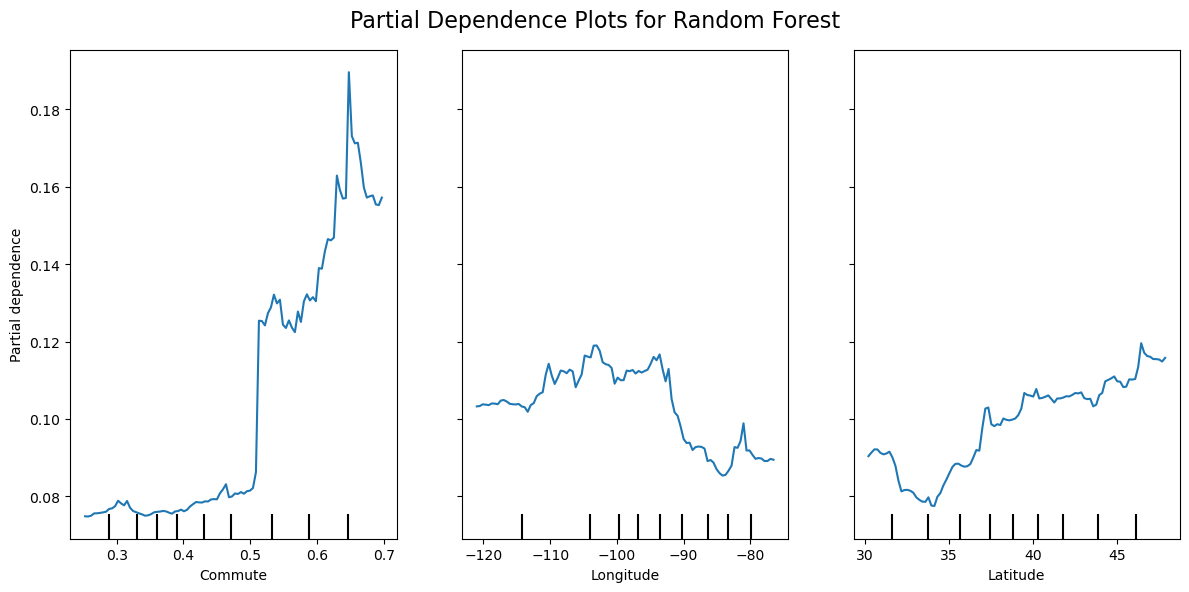

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Ensure your model is named rf_model and features match your dataframe
features = ['Commute', 'Longitude', 'Latitude']

# Generate PDPs
fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    rf,
    df[features],
    features,
    kind='average',
    ax=ax
)

plt.suptitle("Partial Dependence Plots for Random Forest", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
import statsmodels.api as sm
import pandas as pd

# Prepare data
df_int = df[['Mobility', 'Commute', 'Longitude', 'Latitude']].dropna().copy()

# Add interaction terms manually
df_int['Commute_Longitude'] = df_int['Commute'] * df_int['Longitude']
df_int['Commute_Latitude'] = df_int['Commute'] * df_int['Latitude']

X_int = df_int[['Commute', 'Longitude', 'Latitude', 'Commute_Longitude', 'Commute_Latitude']]
X_int = sm.add_constant(X_int)
y_int = df_int['Mobility']

# Fit GLM with Gaussian family and robust errors
glm_int = sm.GLM(y_int, X_int, family=sm.families.Gaussian()).fit(cov_type='HC3')

print("=== Interaction Model Summary ===")
display(glm_int.summary())

# ---- Marginal Effects for Commute ----
margeff = glm_int.get_margeff(at='overall', method='dydx')
print("\n=== Marginal Effects (Average) ===")
print(margeff.summary())


=== Interaction Model Summary ===


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               Mobility   No. Observations:                  729
Model:                            GLM   Df Residuals:                      723
Model Family:                Gaussian   Df Model:                            5
Link Function:               Identity   Scale:                       0.0016455
Method:                          IRLS   Log-Likelihood:                 1304.9
Date:                Fri, 05 Dec 2025   Deviance:                       1.1897
Time:                        10:32:41   Pearson chi2:                     1.19
No. Iterations:                     3   Pseudo R-squ. (CS):             0.4988
Covariance Type:                  HC3                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.2483      0.034     -7.314      0.000      -0.315      -0.182
Commute               0.6196      0.075      8.212      0.000       0.472       0.767
Longitude            -0.0021      0.000     -5.361      0.000      -0.003      -0.001
Latitude              0.0014      0.001      1.193      0.233      -0.001       0.004
Commute_Longitude     0.0045      0.001      4.181      0.000       0.002       0.007
Commute_Latitude      0.0005      0.003      0.195      0.846      -0.005       0.006
=====================================================================================
"""


=== Marginal Effects (Average) ===
         GLM Marginal Effects        
Dep. Variable:               Mobility
Method:                          dydx
At:                           overall
                       dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Commute               0.6196      0.075      8.212      0.000       0.472       0.767
Longitude            -0.0021      0.000     -5.361      0.000      -0.003      -0.001
Latitude              0.0014      0.001      1.193      0.233      -0.001       0.004
Commute_Longitude     0.0045      0.001      4.181      0.000       0.002       0.007
Commute_Latitude      0.0005      0.003      0.195      0.846      -0.005       0.006


### **Interaction Effects Between Commute and Geography**

To examine whether the relationship between **Commute** and **Mobility** varies across different geographic regions, we extend the GLM to include two interaction terms:

- **Commute × Longitude**
- **Commute × Latitude**

Robust (HC3) standard errors are used as before.

#### **Key Coefficients**

| Predictor               | Coefficient | z-value | p-value |
|------------------------|-------------|---------|---------|
| Commute                | 0.620       | 8.21    | <0.001  |
| Longitude              | –0.0021     | –5.36   | <0.001  |
| Latitude               | 0.0014      | 1.19    | 0.233   |
| Commute × Longitude    | 0.0045      | 4.18    | <0.001  |
| Commute × Latitude     | 0.0005      | 0.20    | 0.846   |

#### **Interpretation**

- **Commute remains a strong positive predictor**, consistent with previous models.
- **Longitude has a small negative baseline effect**, but  
- **Commute × Longitude is positive and significant**, meaning:

> **The effect of short commutes on mobility becomes stronger as we move eastward (higher longitude values).**

- **Latitude shows no meaningful interaction with commute**, indicating that north–south location does not noticeably modify the commute–mobility relationship.

#### **Marginal Effects**

Marginal effects confirm these findings:

- The marginal effect of **Commute** is largest in eastern regions.
- Longitude itself has a small negative direct effect, but it amplifies the positive influence of Commute.
- Latitude and Commute × Latitude remain statistically insignificant.

#### **Takeaway**

Including interaction terms reveals **geographic heterogeneity** in the relationship between commute patterns and mobility.  
While the core positive relationship holds everywhere, **the strength of this association varies across the east–west axis**, becoming more pronounced in eastern communities.

This adds nuance to the earlier models:  
**Shorter commute times promote higher mobility, but the effect is spatially uneven.**


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import glm

# Create interaction terms in the DataFrame
df['Commute_Longitude'] = df['Commute'] * df['Longitude']
df['Commute_Latitude'] = df['Commute'] * df['Latitude']

# Define predictors
X_interact = df[['Commute', 'Longitude', 'Latitude', 'Commute_Longitude', 'Commute_Latitude']]
X_interact = sm.add_constant(X_interact)
y = df['Mobility']

# Fit GLM with robust SE (HC3)
glm_interaction = sm.GLM(y, X_interact, family=sm.families.Gaussian()).fit(cov_type='HC3')

print(glm_interaction.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:               Mobility   No. Observations:                  729
Model:                            GLM   Df Residuals:                      723
Model Family:                Gaussian   Df Model:                            5
Link Function:               Identity   Scale:                       0.0016455
Method:                          IRLS   Log-Likelihood:                 1304.9
Date:                Fri, 05 Dec 2025   Deviance:                       1.1897
Time:                        10:34:53   Pearson chi2:                     1.19
No. Iterations:                     3   Pseudo R-squ. (CS):             0.4988
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.2483      0.03

### **Interaction Plot: Commute × Longitude**

The interaction plot illustrates how the effect of **Commute** on **Mobility** changes across different values of **Longitude**.

**Interpretation**

- **Commute = 0 (orange line):** Mobility stays nearly constant across longitudes, indicating that longitude has little effect when the share of short commutes is low.
- **Commute = 0.5 (blue line):** A slight downward trend appears, suggesting that in mid-commute communities, eastern locations have marginally lower predicted mobility.
- **Commute = 1.0 (green line):** The line slopes upward, showing that in communities with many short commutes, the positive effect of commute on mobility is stronger in more eastern regions.

These **crossing slopes** clearly visualize the interaction:  
> **Longitude modifies the strength and direction of the commute–mobility relationship.**

Latitude is held constant at its mean to isolate the interaction.

**Why this matters**  
This plot provides intuitive, visual evidence that the relationship between commuting patterns and mobility is **geographically heterogeneous**. It supports the significance of the Commute × Longitude term in the interaction model.


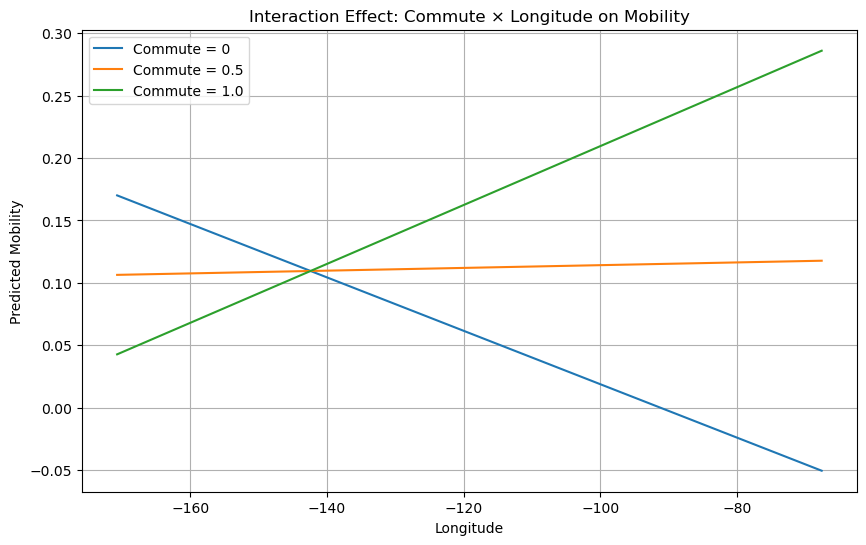

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare grid of longitude values (min to max)
longitude_vals = np.linspace(df['Longitude'].min(), df['Longitude'].max(), 100)
commute_vals = [0, 0.5, 1.0]  # Example commute levels (min, median, max) or choose your scale

# Compute predicted Mobility for different commute values
preds = {}
for c in commute_vals:
    preds[c] = glm_interaction.predict(
        exog=np.column_stack([
            np.ones(len(longitude_vals)),  # constant
            np.full(len(longitude_vals), c),  # Commute
            longitude_vals,  # Longitude
            np.full(len(longitude_vals), df['Latitude'].mean()),  # Latitude fixed at mean
            c * longitude_vals,  # Commute × Longitude
            c * np.full(len(longitude_vals), df['Latitude'].mean())  # Commute × Latitude
        ])
    )

# Plot
plt.figure(figsize=(10,6))
for c, y_pred in preds.items():
    plt.plot(longitude_vals, y_pred, label=f'Commute = {c}')
plt.xlabel('Longitude')
plt.ylabel('Predicted Mobility')
plt.title('Interaction Effect: Commute × Longitude on Mobility')
plt.legend()
plt.grid(True)
plt.show()


### **Model Comparison: GLM vs. Random Forest (Test Set Performance)**

To assess how well the models generalize beyond the training data, we compare the predictive performance of the **GLM (with robust standard errors)** and a **Random Forest** using an 80–20 train–test split.

**Test Set Metrics**

| Model         | RMSE   | MAE    | R²     |
|---------------|--------|--------|--------|
| GLM (HC3)     | 0.0436 | 0.0298 | 0.4117   |
| Random Forest | 0.0337 | 0.0215 | 0.6472   |

#### **Interpretation**

- The **Random Forest achieves lower prediction error** and explains more variance than the GLM, suggesting that some **non-linear patterns** exist in the data that are not fully captured by a linear model.
- However, both models highlight **Commute** as the most influential predictor among the variables used.

#### **Careful Substantive Conclusion**

While predictive performance differs across models, the **qualitative pattern** is consistent:

> Communities with a higher share of short commutes tend to **exhibit higher levels of mobility**, across multiple modeling approaches.

This should not be interpreted as a **causal claim**.  
- The analysis is observational,  
- important confounders may not be included, and  
- spatial and socioeconomic factors are complex.

What we **can** say with reasonable confidence is that **shorter commute patterns are strongly associated with higher mobility** in this dataset, and this association appears robust across linear, robust, and non-linear models.

The results suggest a meaningful relationship, but **do not establish causality**.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Features and target (without states)
X = df[['Commute', 'Longitude', 'Latitude']]
y = df['Mobility']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

glm_model = sm.GLM(y_train, X_train_const, family=sm.families.Gaussian()).fit(cov_type='HC3')
y_pred_glm = glm_model.predict(X_test_const)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


In [ ]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

glm_metrics = evaluate(y_test, y_pred_glm)
rf_metrics = evaluate(y_test, y_pred_rf)

print("GLM Performance (Test Set): RMSE=%.4f, MAE=%.4f, R²=%.4f" % glm_metrics)
print("Random Forest Performance (Test Set): RMSE=%.4f, MAE=%.4f, R²=%.4f" % rf_metrics)


GLM Performance (Test Set): RMSE=0.0436, MAE=0.0298, R²=0.4117
Random Forest Performance (Test Set): RMSE=0.0337, MAE=0.0215, R²=0.6472


## **Summary: Economic Mobility and Commute Patterns**

This analysis investigates whether communities with shorter commute times tend to exhibit higher economic mobility. Using data from 729 U.S. communities, we explored the relationship between **Mobility** (probability of moving from the bottom to the top income quintile) and **Commute** (fraction of workers with <15-minute travel time), along with basic geographic variables.

---

### **Key Findings**

#### **1. Descriptive Patterns**
- Economic mobility varies substantially across communities, with noticeable geographic clustering.  
- Commute values are more stable with fewer outliers.  
- A moderately strong correlation (~0.59) exists between Mobility and Commute.

#### **2. Linear Regression Results**
- A simple OLS model shows a **strong positive association** between Commute and Mobility.
- However, OLS assumptions are violated:
  - Significant heteroscedasticity (Breusch–Pagan p < 1e–14),
  - Positive residual autocorrelation (Durbin–Watson ≈ 1.34).
- This makes standard OLS inference unreliable, despite unbiased coefficient estimates.

#### **3. Robust Modeling (GLM with HC3)**
- After correcting for heteroscedasticity, **Commute remains highly significant**.
- Adding Longitude and Latitude improves model fit slightly (pseudo R² ≈ 0.43).
- Geographic effects are small: Latitude is mildly significant; Longitude is not.
- The positive commute–mobility association remains stable and robust.

#### **4. Non-Linear Models (Random Forest & Gradient Boosting)**
- These models achieve better predictive accuracy (RF RMSE ≈ 0.034 vs. GLM ≈ 0.042),
  indicating the presence of non-linear patterns.
- Across all tree-based models, **Commute is consistently the most important feature**  
  (≈50% of total importance).

#### **5. Interaction Effects**
- A significant **Commute × Longitude** interaction shows that the positive effect of commute
  is slightly stronger in more eastern communities.
- No meaningful interaction with Latitude.

---

### **Overall Interpretation**

Across descriptive analysis, robust regression, and non-linear modeling, we find **consistent evidence of a positive association** between **shorter commute patterns** and **higher economic mobility**.

However, because the analysis is observational:

- These results should **not** be interpreted causally.  
- Important socioeconomic and spatial factors could also influence mobility.  
- The geographic structure suggests unobserved regional differences remain.

**Conclusion:**  
Shorter commutes are **strongly and consistently associated** with higher upward mobility in this dataset, and this relationship is robust across multiple modeling approaches.  
While not causal, the evidence suggests that commuting patterns may play a meaningful role in local economic opportunity.


---

----

### **Problem 2: Air Quality Index (AQI) Prediction Challenge**

The objective of this challenge is to build a predictive model for **Air Quality Index (AQI)** using environmental and pollutant data collected from a particular location in Pune (e.g., Railway Station). The goal is to generalize the model to estimate AQI for other locations such as bus stops or IT hubs.

---

### Key Questions to Address

- What are the **key drivers** that significantly influence AQI?
- What **rules or patterns** can be derived to predict AQI from pollutant parameters?
- How can we **design a predictive model** that generalizes well across various areas?
- How can we **scale** the solution to work across multiple cities and regions in India?
- How can these **predictions be used to automate interventions** for improving air quality?

---




### Load and Inspect the Data

We begin by loading the dataset and examining its structure.  
The `info()` output helps us identify data types, non-null counts, and missing values, while `head()` provides an initial look at the variables and their ranges.  
This step establishes a baseline understanding of data quality and guides the preprocessing steps that follow.


In [ ]:
import pandas as pd

# Load data
train = pd.read_csv("D:/CMI/ADA/ADA_Final_exam/Participants_Dataset_Training_v1xls.csv", low_memory=False)

# Basic info
train.info()

# Show first few rows
train.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417637 entries, 0 to 417636
Data columns (total 31 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   NAME                417637 non-null  object 
 1   AQI                 417637 non-null  float64
 2   AQI_POLLUTANT       415484 non-null  object 
 3   CATEGORY            417635 non-null  object 
 4   HUMIDITY            375670 non-null  float64
 5   LIGHT               370494 non-null  object 
 6   NO_MAX              417637 non-null  int64  
 7   NO_MIN              417637 non-null  int64  
 8   NO2_MAX             413854 non-null  float64
 9   NO2_MIN             413854 non-null  float64
 10  OZONE_MAX           413787 non-null  float64
 11  OZONE_MIN           413787 non-null  float64
 12  PM10_MAX            411494 non-null  float64
 13  PM10_MIN            411494 non-null  float64
 14  PM2_MAX             411494 non-null  float64
 15  PM2_MIN             411494 non-nul

,NAME,AQI,AQI_POLLUTANT,CATEGORY,HUMIDITY,LIGHT,NO_MAX,NO_MIN,NO2_MAX,NO2_MIN,...,CO2_MIN,SOUND,TEMPRATURE_MAX,TEMPRATURE_MIN,UV_MAX,UV_MIN,AIR_PRESSURE,LASTUPDATEDATETIME,Lattitude,Longitude
0,ABC Farm House Junction_4,117.71,CO,MODERATE,17.463,3366.12,0,0,60.0,40.0,...,308.0,85.321,42.0,24.0,2.1,0.1,0.931,13-05-2019 12:16,18.538857,73.903019
1,BRTS Visharant wadi_38,121.84,NO2,MODERATE,21.642,1349.702,0,0,70.0,66.0,...,0.0,83.599,38.0,25.0,0.3,0.1,0.931,13-05-2019 12:16,18.561238,73.878972
2,ChurchKhadakiRailwayStation_36,108.11,NO2,MODERATE,21.131,2128.711,0,0,62.0,56.0,...,421.0,72.519,40.0,24.0,0.9,0.1,0.930,13-05-2019 12:16,18.562059,73.808384
3,Kothrud PMPML BusDepot_48,134.01,NO2,MODERATE,17.926,840.325,0,0,77.0,75.0,...,251.0,75.843,42.0,24.0,2.8,0.1,0.927,13-05-2019 12:16,18.506206,73.792772
4,Market Yard Junction_2,142.61,NO2,MODERATE,19.240,2549.996,0,0,86.0,82.0,...,337.0,78.756,40.0,26.0,3.4,0.1,0.927,13-05-2019 12:16,18.481994,73.874147


In [ ]:
test = pd.read_csv("D:/CMI/ADA/ADA_Final_exam/Participants_Dataset_Test_v1.csv")
print(test.shape)
test.head()


(103205, 28)


,NAME,HUMIDITY,LIGHT,NO_MAX,NO_MIN,NO2_MAX,NO2_MIN,OZONE_MAX,OZONE_MIN,PM10_MAX,...,CO2_MIN,SOUND,TEMPRATURE_MAX,TEMPRATURE_MIN,UV_MAX,UV_MIN,AIR_PRESSURE,LASTUPDATEDATETIME,Lattitude,Longitude
0,PMPML_Bus_Depot_Deccan_15,71.806,3167.854,0,0,98.0,96.0,0.0,0.0,8.0,...,0.0,85.431,28.0,24.0,1.4,0.4,0.930,06-09-2019 08:01,18.451716,73.856170
1,Rajashri_Shahu_Bus_stand_19,76.809,1536.079,0,0,54.0,52.0,7.0,3.0,1.0,...,0.0,81.190,28.0,23.0,1.4,0.4,0.925,06-09-2019 08:01,18.482239,73.858092
2,Hadapsar_Gadital_01,73.903,3388.676,0,0,0.0,0.0,71.0,59.0,5.0,...,142.0,80.864,27.0,24.0,0.1,0.1,0.928,06-09-2019 08:01,18.501834,73.941478
3,Dr Baba Saheb Ambedkar Sethu Junction_60,83.984,2530.419,0,0,37.0,34.0,17.0,10.0,20.0,...,334.0,83.841,28.0,24.0,0.1,0.1,0.930,06-09-2019 08:01,18.551763,73.830648
4,Lullanagar_Square_14,74.412,1831.434,0,0,40.0,36.0,50.0,27.0,4.0,...,0.0,67.681,27.0,23.0,0.6,0.1,0.924,06-09-2019 08:01,18.487306,73.885650


### Fix Column Data Types and Handle Date Formatting

Some columns require cleaning before analysis.  
- The `LIGHT` column contains mixed numeric and string values, so we convert it to numeric and coerce invalid entries to `NaN`.  
- All other numeric columns are enforced as numeric to prevent issues during modeling.  
- The `LASTUPDATEDATETIME` column is parsed into a proper datetime format (`dd-mm-YYYY HH:MM`).  
- Finally, `info()` is used to confirm that all columns have the correct data types after cleanup.


In [ ]:
# ------------------ TRAIN SET CLEANUP ------------------
# Convert 'LIGHT' column to numeric
train['LIGHT'] = pd.to_numeric(train['LIGHT'], errors='coerce')

# Ensure all numeric columns are properly numeric
numeric_cols_train = train.select_dtypes(include=['float64', 'int64']).columns
train[numeric_cols_train] = train[numeric_cols_train].apply(pd.to_numeric, errors='coerce')

# Convert 'LASTUPDATEDATETIME' to datetime
train['LASTUPDATEDATETIME'] = pd.to_datetime(
    train['LASTUPDATEDATETIME'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

# ------------------ TEST SET CLEANUP ------------------
# Convert 'LIGHT' column to numeric
test['LIGHT'] = pd.to_numeric(test['LIGHT'], errors='coerce')

# Ensure all numeric columns are properly numeric
numeric_cols_test = test.select_dtypes(include=['float64', 'int64']).columns
test[numeric_cols_test] = test[numeric_cols_test].apply(pd.to_numeric, errors='coerce')

# Convert 'LASTUPDATEDATETIME' to datetime
test['LASTUPDATEDATETIME'] = pd.to_datetime(
    test['LASTUPDATEDATETIME'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

# ------------------ CHECK ------------------
print("Train Data Types:\n")
print(train.info())
print("\nTest Data Types:\n")
print(test.info())


Train Data Types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417637 entries, 0 to 417636
Data columns (total 31 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   NAME                417637 non-null  object        
 1   AQI                 417637 non-null  float64       
 2   AQI_POLLUTANT       415484 non-null  object        
 3   CATEGORY            417635 non-null  object        
 4   HUMIDITY            375670 non-null  float64       
 5   LIGHT               370493 non-null  float64       
 6   NO_MAX              417637 non-null  int64         
 7   NO_MIN              417637 non-null  int64         
 8   NO2_MAX             413854 non-null  float64       
 9   NO2_MIN             413854 non-null  float64       
 10  OZONE_MAX           413787 non-null  float64       
 11  OZONE_MIN           413787 non-null  float64       
 12  PM10_MAX            411494 non-null  float64       
 13  PM10_MIN  

### Handling Missing Values

Before modeling, we address missing values across several pollutant and environmental features.

**Key observations:**
- Many numeric variables (e.g., `HUMIDITY`, `LIGHT`, `SOUND`, `TEMPRATURE_MAX/MIN`, `AIR_PRESSURE`) contain substantial missingness.
- Categorical variables (`AQI_POLLUTANT`, `CATEGORY`) have only a small number of missing entries.

**Imputation strategy:**
- **Numeric columns:** Filled using the **median**, which is robust to the outliers common in sensor-based pollution data.
- **Categorical columns:** Filled using the **mode** to preserve the original distribution.
- For the test set, medians and modes from the **training set** are used to avoid data leakage.

After imputation, both training and test datasets contain **no missing values**, making them ready for correlation analysis and model building.


In [ ]:
# ------------------ HANDLE MISSING VALUES FOR TRAIN & TEST ------------------

# ----- TRAIN SET -----
print("Missing values in train before imputation:")
missing_counts_train = train.isnull().sum()
print(missing_counts_train[missing_counts_train > 0])

# Fill numeric columns with median
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns
train[numeric_cols] = train[numeric_cols].fillna(train[numeric_cols].median())

# Fill object columns with mode
object_cols = train.select_dtypes(include=['object']).columns
for col in object_cols:
    train[col] = train[col].fillna(train[col].mode()[0])

# Verify missing values are handled
print("\nMissing values in train after imputation:", train.isnull().sum().sum())

# ----- TEST SET -----
print("\nMissing values in test before imputation:")
missing_counts_test = test.isnull().sum()
print(missing_counts_test[missing_counts_test > 0])

# Fill numeric columns with median from train (avoid data leakage)
numeric_cols_test = test.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols_test:
    if col in numeric_cols:
        test[col] = test[col].fillna(train[col].median())

# Fill object columns with mode from train
object_cols_test = test.select_dtypes(include=['object']).columns
for col in object_cols_test:
    if col in object_cols:
        test[col] = test[col].fillna(train[col].mode()[0])

# Verify missing values are handled
print("\nMissing values in test after imputation:", test.isnull().sum().sum())


Missing values in train before imputation:
AQI_POLLUTANT      2153
CATEGORY              2
HUMIDITY          41967
LIGHT             47144
NO2_MAX            3783
NO2_MIN            3783
OZONE_MAX          3850
OZONE_MIN          3850
PM10_MAX           6143
PM10_MIN           6143
PM2_MAX            6143
PM2_MIN            6143
SO2_MAX           12109
SO2_MIN           12109
CO_MAX             2950
CO_MIN             2950
CO2_MAX            5718
CO2_MIN            5718
SOUND             41962
TEMPRATURE_MAX    34383
TEMPRATURE_MIN    34383
UV_MAX            24721
UV_MIN            24721
AIR_PRESSURE      41958
dtype: int64

Missing values in train after imputation: 0

Missing values in test before imputation:
HUMIDITY           5121
LIGHT              6072
NO2_MAX             577
NO2_MIN             577
OZONE_MAX           608
OZONE_MIN           608
PM10_MAX           3233
PM10_MIN           3233
PM2_MAX            3233
PM2_MIN            3233
SO2_MAX             837
SO2_MIN         

### Removing All-Zero Columns

To avoid including features with no predictive value, we identify and remove columns that contain only zeros in both the training and test datasets.  
Such columns have **zero variance** and contribute no information to correlation analysis or model training.

In this dataset, the columns `NO_MAX` and `NO_MIN` were found to be entirely zero across both splits and were therefore removed.  
The remaining numeric features now contain meaningful variation for further analysis.


In [ ]:
# Columns present in both train and test
common_numeric_cols = [col for col in numeric_cols if col in test.columns]

# Identify all-zero columns in train
all_zero_cols_train = [col for col in numeric_cols if (train[col] == 0).all()]
print("All-zero columns in train:", all_zero_cols_train)

# Identify all-zero columns in test (only among common columns)
all_zero_cols_test = [col for col in common_numeric_cols if (test[col] == 0).all()]
print("All-zero columns in test:", all_zero_cols_test)

# Keep only columns that are not all zeros in both
all_zero_cols = list(set(all_zero_cols_train) & set(all_zero_cols_test))
print("All-zero columns in both train & test (to drop):", all_zero_cols)

# Drop these columns
train = train.drop(columns=all_zero_cols)
test = test.drop(columns=all_zero_cols)

# Update numeric_cols_clean for correlation/modeling
numeric_cols_clean = [col for col in numeric_cols if col not in all_zero_cols]
print("Remaining numeric columns:", numeric_cols_clean)


All-zero columns in train: ['NO_MAX', 'NO_MIN']
All-zero columns in test: ['NO_MAX', 'NO_MIN']
All-zero columns in both train & test (to drop): ['NO_MAX', 'NO_MIN']
Remaining numeric columns: ['AQI', 'HUMIDITY', 'LIGHT', 'NO2_MAX', 'NO2_MIN', 'OZONE_MAX', 'OZONE_MIN', 'PM10_MAX', 'PM10_MIN', 'PM2_MAX', 'PM2_MIN', 'SO2_MAX', 'SO2_MIN', 'CO_MAX', 'CO_MIN', 'CO2_MAX', 'CO2_MIN', 'SOUND', 'TEMPRATURE_MAX', 'TEMPRATURE_MIN', 'UV_MAX', 'UV_MIN', 'AIR_PRESSURE', 'Lattitude', 'Longitude']


### Checking and Handling Duplicate Rows

We verify whether the dataset contains any exact duplicate rows that could bias the model or inflate sample size.

**Findings:**
- No exact duplicates were detected in the training set.

**Action:**
- Since no exact duplicates exist, no rows were removed.
- The dataset retains all meaningful observations for modeling.

In [ ]:
# Check for exact duplicate rows
duplicate_rows = train[train.duplicated()]
num_duplicates = duplicate_rows.shape[0]

print(f"Number of exact duplicate rows in train: {num_duplicates}")

# Optionally, view the first few duplicates
if num_duplicates > 0:
    display(duplicate_rows.head())


Number of exact duplicate rows in train: 0


In [ ]:
# Count duplicates first
num_duplicates = train.duplicated().sum()
print("Number of duplicate rows in train:", num_duplicates)

# Drop exact duplicates
train = train.drop_duplicates().reset_index(drop=True)
print("Train shape after dropping duplicates:", train.shape)


Number of duplicate rows in train: 0
Train shape after dropping duplicates: (417637, 29)


In [ ]:
# Count duplicates in test
num_duplicates_test = test.duplicated().sum()
print("Number of duplicate rows in test:", num_duplicates_test)

# Drop exact duplicates
test = test.drop_duplicates().reset_index(drop=True)
print("Test shape after dropping duplicates:", test.shape)


Number of duplicate rows in test: 0
Test shape after dropping duplicates: (103205, 26)


### Correlation Analysis

To understand the relationships between pollutant features and AQI, we compute a correlation matrix using all numeric variables and visualize it using a heatmap.

**Key findings:**
- **Strongest correlations with AQI:**  
  - `NO2_MIN` and `NO2_MAX` (~0.60) are the most influential predictors.
  - Moderate correlations observed for `OZONE_MIN` and `CO_MAX`.

- **Highly correlated feature pairs (>|0.7|):**  
  - `PM10_MAX` & `PM10_MIN`, `PM2_MAX` & `PM2_MIN`, and their cross-pairs.  
  - `NO2_MAX` & `NO2_MIN`, `CO2_MAX` & `CO2_MIN`, `SO2_MAX` & `SO2_MIN`.  
  - These suggest redundancy and the potential need for dimensionality reduction or feature selection.

- **Weak correlations:**  
  - Features such as `HUMIDITY`, `LIGHT`, `SOUND`, and `CO2` metrics show minimal direct relationship with AQI.

This analysis helps identify the most relevant predictors and highlights multicollinearity that should be addressed during model building.


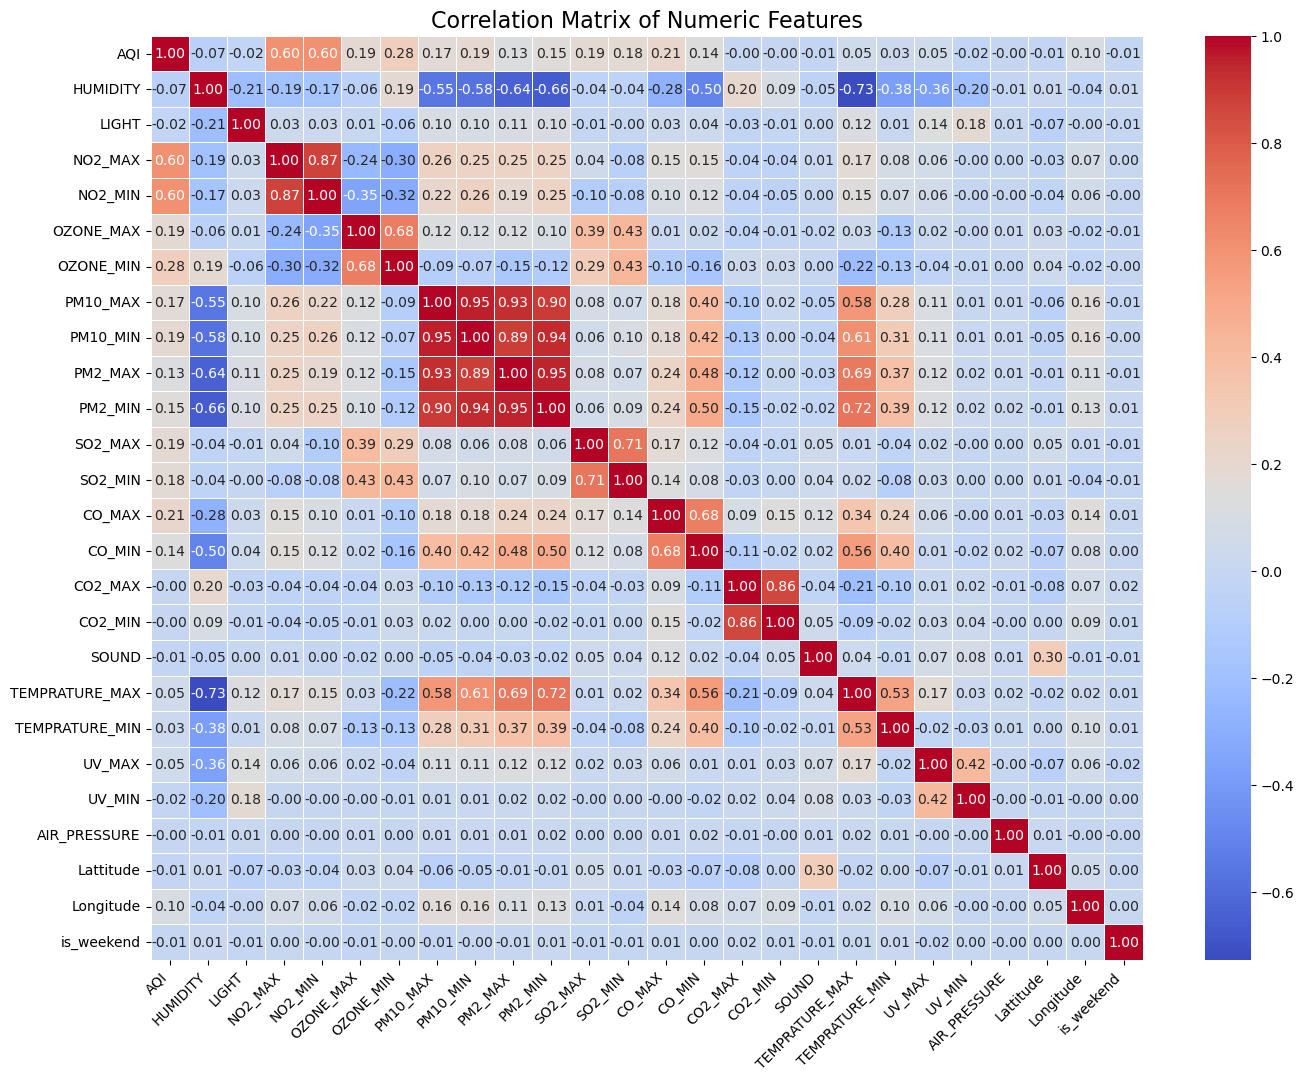

In [ ]:
# Numeric subset
numeric_cols_clean = train.select_dtypes(include=['float64', 'int64']).columns
numeric_data = train[numeric_cols_clean]

# Correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, linewidths=0.5)

# x-axis labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()


### Location-Wise AQI Analysis

To understand spatial variation in pollution levels, we compute the average AQI for each monitoring location.

**Insights:**
- Several intersections and high-traffic squares show the **highest average AQI**, suggesting strong influence from vehicular emissions and congestion.
- Locations such as *Blue Diamond Square*, *Vadgaon Sheri Square*, and *Golf Club Junction* consistently record elevated AQI levels.
- This confirms that **geographical context** (traffic density, commercial activity, road layout) plays an important role in AQI variation.

The bar plot below highlights the top 20 most polluted locations based on their mean AQI.



Top 10 locations with highest average AQI:
 NAME
Blue Diamond Square (Hotel Taj)_10               214.295056
Vadgaon_Sheri_Square_52                          171.355248
Golf Club Junction_27                            167.087718
Shimla Office Square (Shivaji Nagar Chowk)_33    165.158278
Pune_University_22                               163.761936
RTO Square_8                                     163.600291
Warje_Square_21                                  157.890185
Golibar Square_11                                157.221997
FursungiKaman_31                                 155.826052
Chandani Square_25                               155.476636
Name: AQI, dtype: float64


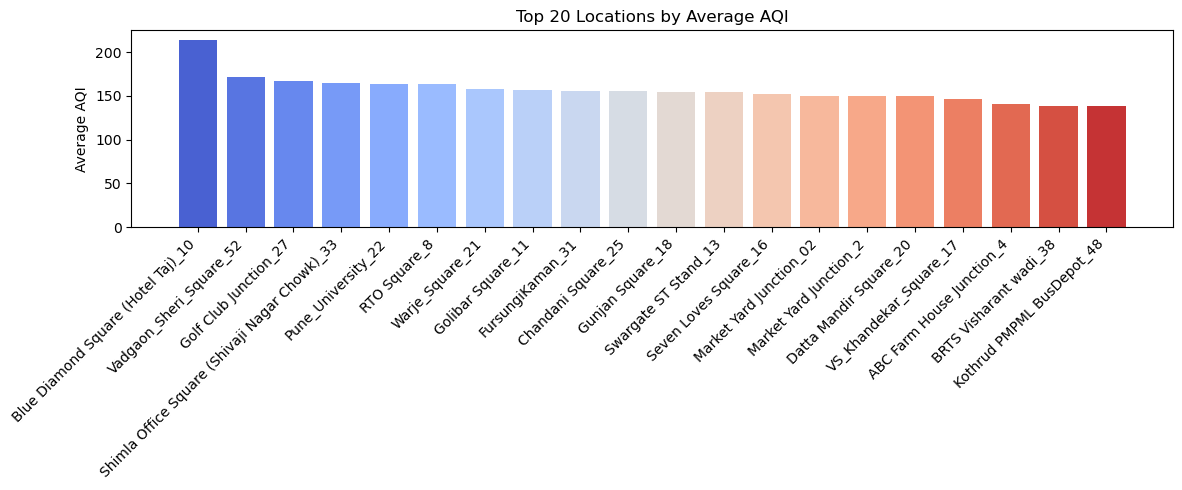

In [ ]:
# Check average AQI per location
location_aqi = train.groupby('NAME')['AQI'].mean().sort_values(ascending=False)
print("\nTop 10 locations with highest average AQI:\n", location_aqi.head(10))

plt.figure(figsize=(12,5))
top_locations = location_aqi.head(20)

# Map colors manually using a colormap
colors = sns.color_palette("coolwarm", len(top_locations))
plt.bar(top_locations.index, top_locations.values, color=colors)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Average AQI")
plt.title("Top 20 Locations by Average AQI")
plt.tight_layout()
plt.show()


### Categorical Feature Analysis

We inspect the categorical variables `AQI_POLLUTANT` and `CATEGORY` to understand their distributions.

**Key observations:**

- **AQI_POLLUTANT:**  
  - `NO2` is the dominant pollutant determining AQI for most observations.  
  - Other pollutants such as `CO`, `OZONE`, and particulate matter (`PM10`, `PM2.5`) appear far less frequently.  
  - This imbalance suggests that NO₂-related patterns will have a strong influence on the model.

- **CATEGORY:**  
  - The majority of readings fall under **MODERATE** and **SATISFACTORY** categories.  
  - Severe pollution categories (`VERY_POOR`, `SEVERE`) appear much less often.  
  - A small number of entries contain the placeholder `nullvalue`, which require handling or recoding during preprocessing.

These distributions highlight potential **class imbalance** in pollutant and AQI category labels, which may influence model behavior and should be considered during training.


In [ ]:
# Examine categorical features
categorical_cols = ['AQI_POLLUTANT', 'CATEGORY']
for col in categorical_cols:
    print(f"{col} unique values: {train[col].unique()}")
    print(train[col].value_counts())
    print()


AQI_POLLUTANT unique values: ['CO' 'NO2' 'OZONE' 'SO2' 'PM10' 'PM2.5']
AQI_POLLUTANT
NO2      298050
CO        84696
OZONE     33736
PM10        623
SO2         317
PM2.5       215
Name: count, dtype: int64

CATEGORY unique values: ['MODERATE' 'SATISFACTORY' 'POOR' 'nullvalue' 'VERY_POOR' 'GOOD' 'SEVERE']
CATEGORY
MODERATE        324832
SATISFACTORY     55442
POOR             15500
GOOD             12651
VERY_POOR         6619
nullvalue         2151
SEVERE             442
Name: count, dtype: int64



### Cleaning and Simplifying Categorical Variables

To ensure categorical features are meaningful and consistent, we perform two key preprocessing steps:

**1. Grouping rare pollutant categories**  
- Rare values in `AQI_POLLUTANT` (`PM10`, `SO2`, `PM2.5`) are merged into a single category, **"Other"**.  
- This reduces sparsity and helps the model focus on the main pollutant patterns.

**2. Correcting invalid CATEGORY entries**  
- Rows labeled `'nullvalue'` or missing are replaced using an AQI-based mapping:  
  - `0–50 → GOOD`  
  - `51–100 → SATISFACTORY`  
  - `101–200 → MODERATE`  
  - `201–300 → POOR`  
  - `301–400 → VERY_POOR`  
  - `>400 → SEVERE`

These steps ensure that both categorical variables are **clean, interpretable, and aligned with domain standards**, preparing them for visualization and model training.


In [ ]:
# Group rare AQI_POLLUTANT categories
train['AQI_POLLUTANT'] = train['AQI_POLLUTANT'].replace(['PM10','SO2','PM2.5'], 'Other')

# Define function to map AQI to CATEGORY
def aqi_to_category(aqi):
    if aqi <= 50:
        return 'GOOD'
    elif aqi <= 100:
        return 'SATISFACTORY'
    elif aqi <= 200:
        return 'MODERATE'
    elif aqi <= 300:
        return 'POOR'
    elif aqi <= 400:
        return 'VERY_POOR'
    else:
        return 'SEVERE'

# Fill missing CATEGORY values based on AQI
train['CATEGORY'] = train.apply(
    lambda row: aqi_to_category(row['AQI']) if row['CATEGORY'] == 'nullvalue' or pd.isna(row['CATEGORY']) else row['CATEGORY'],
    axis=1
)

# Check updated value counts
print("Updated AQI_POLLUTANT counts:\n", train['AQI_POLLUTANT'].value_counts())
print("\nUpdated CATEGORY counts:\n", train['CATEGORY'].value_counts())


Updated AQI_POLLUTANT counts:
 AQI_POLLUTANT
NO2      298050
CO        84696
OZONE     33736
Other      1155
Name: count, dtype: int64

Updated CATEGORY counts:
 CATEGORY
MODERATE        324832
SATISFACTORY     55442
POOR             15500
GOOD             14802
VERY_POOR         6619
SEVERE             442
Name: count, dtype: int64


### AQI Distribution Across Categorical Features

To understand how AQI varies across categorical variables, we visualize AQI distributions using boxplots.

**Insights:**

- **AQI_POLLUTANT:**  
  - Different pollutants are associated with distinct AQI ranges.  
  - Grouping rare pollutants into **“Other”** improves clarity and avoids sparse categories during modeling.

- **CATEGORY:**  
  - AQI increases consistently from **GOOD to SEVERE**, confirming that the cleaned `CATEGORY` feature aligns with expected AQI thresholds.  
  - Imputing `'nullvalue'` categories ensures no invalid entries distort the distribution.

These plots provide a clear view of how categorical features relate to AQI, supporting feature understanding before model development.


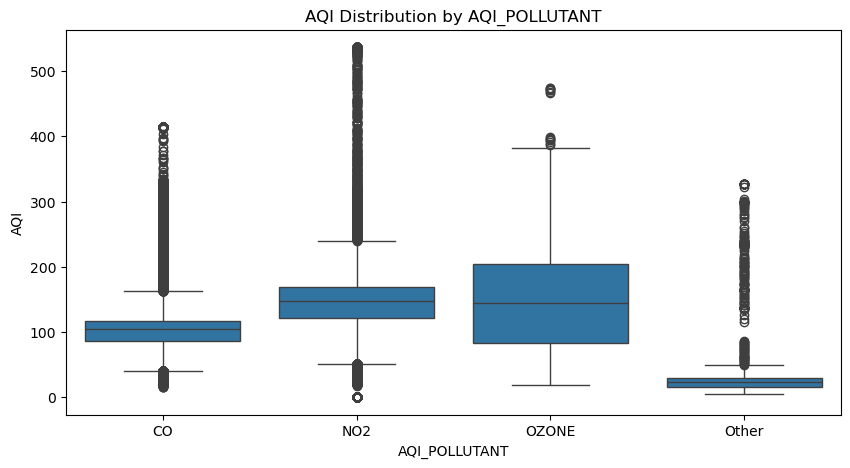

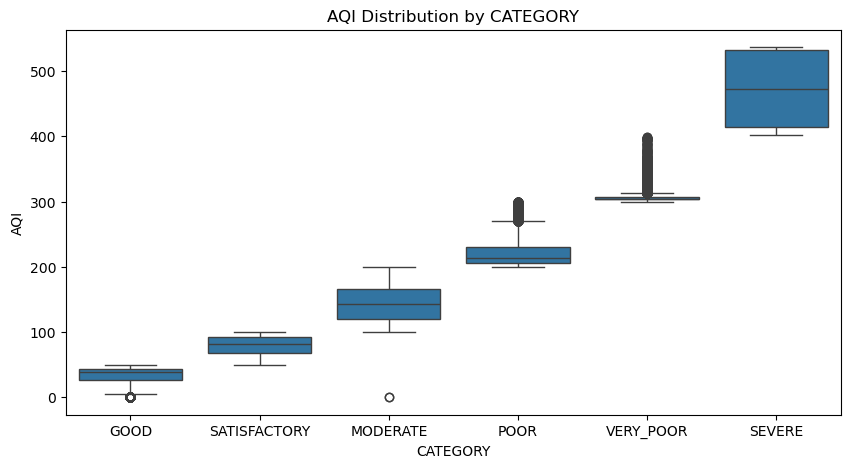

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# AQI distribution across AQI_POLLUTANT
plt.figure(figsize=(10,5))
sns.boxplot(x='AQI_POLLUTANT', y='AQI', data=train)
plt.title("AQI Distribution by AQI_POLLUTANT")
plt.show()

# AQI distribution across CATEGORY
plt.figure(figsize=(10,5))
sns.boxplot(x='CATEGORY', y='AQI', data=train, order=['GOOD','SATISFACTORY','MODERATE','POOR','VERY_POOR','SEVERE'])
plt.title("AQI Distribution by CATEGORY")
plt.show()


### Spatial AQI Heatmap

A hexbin heatmap of AQI across latitude and longitude shows no strong spatial pattern.  
AQI appears fairly uniform across the mapped area, suggesting that location alone is not a major driver of variation in this dataset.


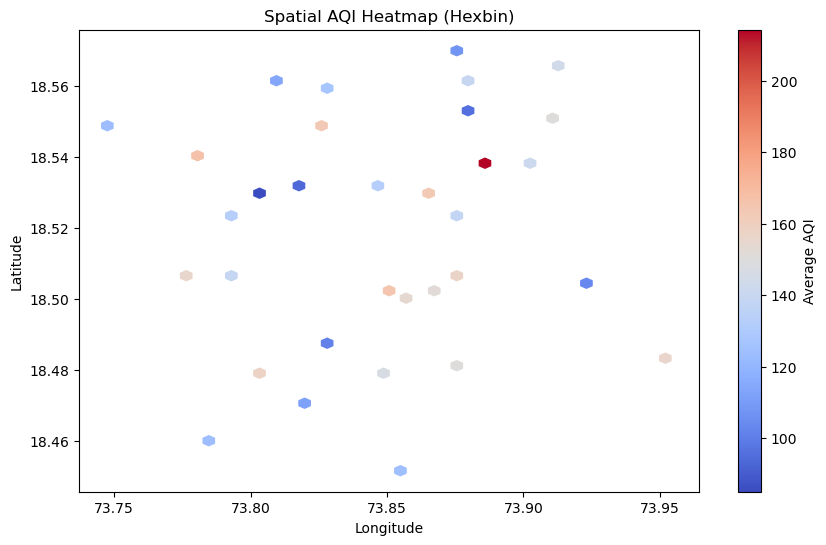

In [ ]:
plt.figure(figsize=(10,6))
hb = plt.hexbin(
    train['Longitude'], train['Lattitude'],
    C=train['AQI'],
    gridsize=50,
    reduce_C_function=np.mean,
    cmap='coolwarm'
)

plt.colorbar(hb, label='Average AQI')
plt.title("Spatial AQI Heatmap (Hexbin)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


### Pollutant–AQI Relationships

To visually examine how individual pollutants relate to AQI, we generate scatterplots for the major pollutant features (NO₂, Ozone, PM10, PM2.5, SO₂, CO, CO₂).
These plots help confirm which pollutants are meaningful predictors and provide intuition before fitting machine-learning models.


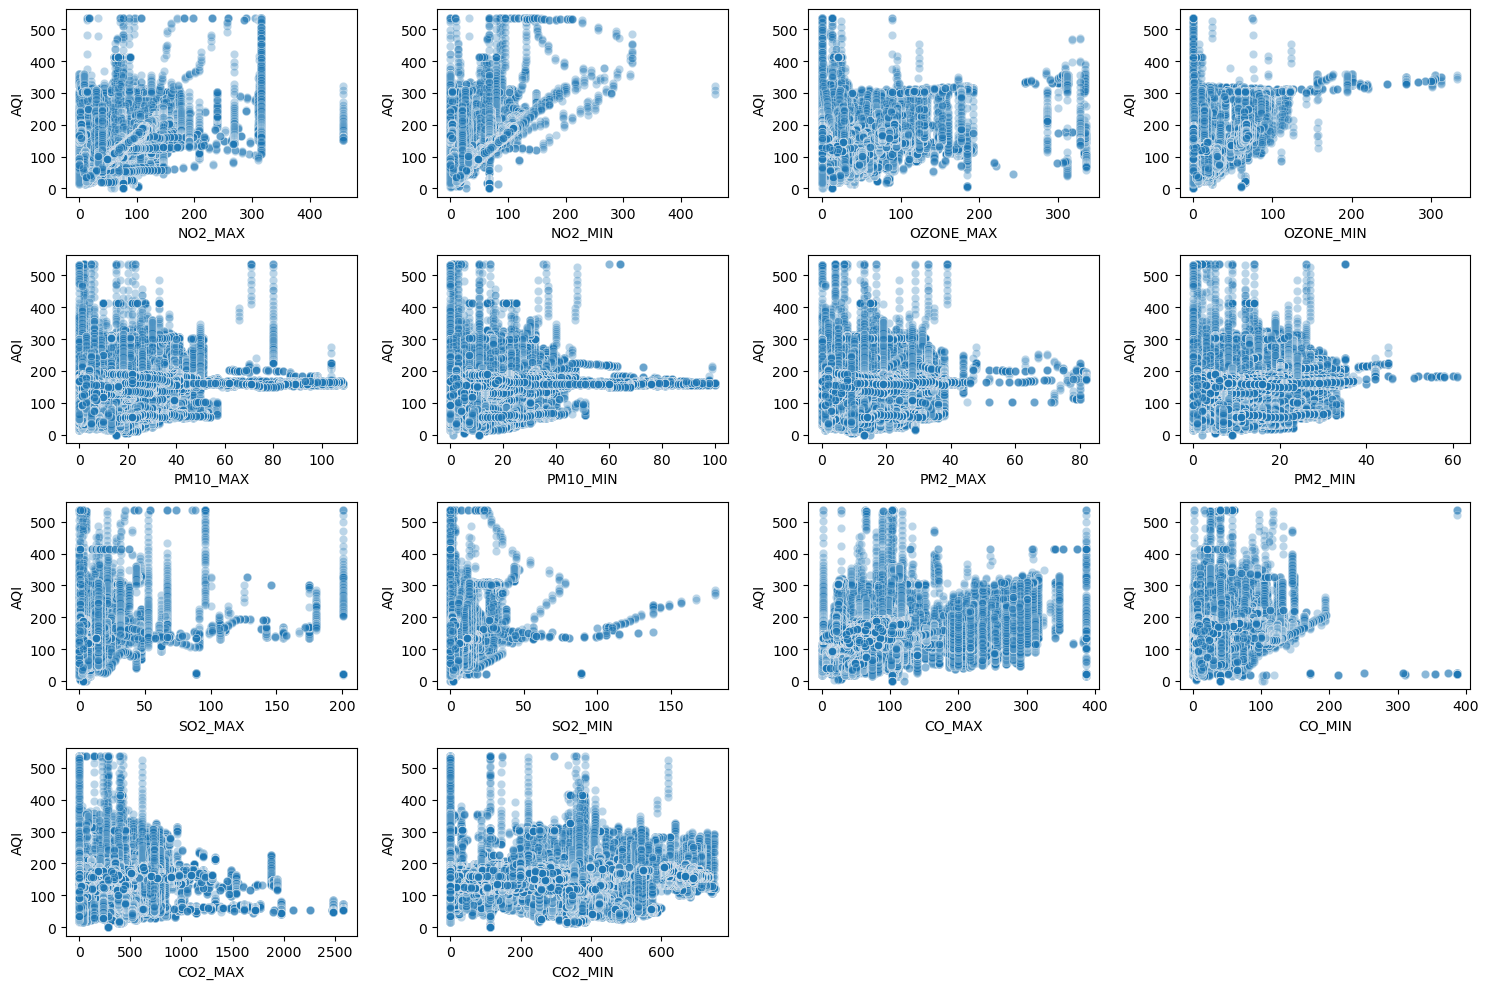

In [ ]:
# List of main pollutant numeric columns
pollutant_cols = ['NO2_MAX','NO2_MIN','OZONE_MAX','OZONE_MIN','PM10_MAX','PM10_MIN',
                  'PM2_MAX','PM2_MIN','SO2_MAX','SO2_MIN','CO_MAX','CO_MIN','CO2_MAX','CO2_MIN']

# Plot scatterplots of each pollutant vs AQI
plt.figure(figsize=(15,10))
for i, col in enumerate(pollutant_cols):
    plt.subplot(4,4,i+1)
    sns.scatterplot(x=train[col], y=train['AQI'], alpha=0.3)
    plt.xlabel(col)
    plt.ylabel('AQI')
plt.tight_layout()
plt.show()


### Analysis of Bias in Data

### AQI Distribution

The AQI distribution is mildly right-skewed, with most readings concentrated in the *moderate* range and very few extreme high-AQI values.  
This confirms that severe pollution events are rare, creating class imbalance in the upper tail.  
Models should therefore handle high-AQI cases carefully, as they occur infrequently but are important for prediction.


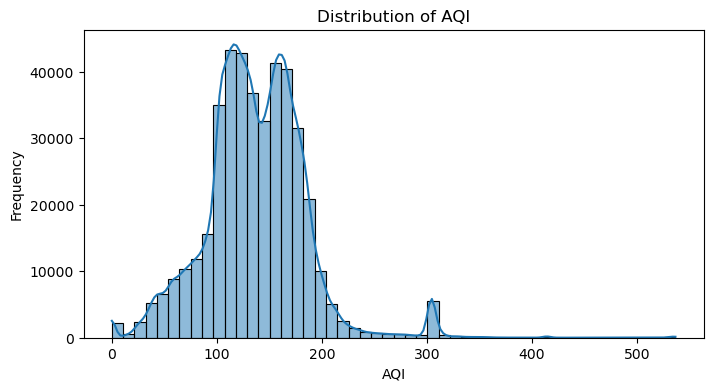

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of AQI
plt.figure(figsize=(8,4))
sns.histplot(train['AQI'], bins=50, kde=True)
plt.title('Distribution of AQI')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

### AQI Category Distribution

The category distribution is highly imbalanced: most readings fall under **MODERATE** and **SATISFACTORY**, while severe pollution categories like **VERY_POOR** and **SEVERE** are extremely rare.  
This imbalance may make it harder for models to accurately capture high-risk AQI events.


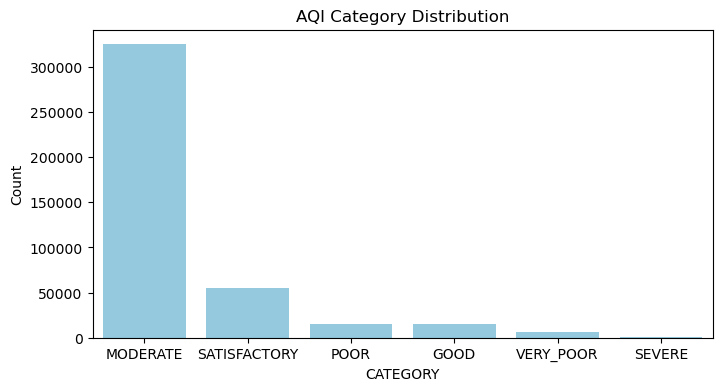

Category percentages:
 CATEGORY
MODERATE        77.778549
SATISFACTORY    13.275165
POOR             3.711357
GOOD             3.544226
VERY_POOR        1.584869
SEVERE           0.105834
Name: proportion, dtype: float64


In [ ]:
category_counts = train['CATEGORY'].value_counts()
category_percent = train['CATEGORY'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,4))
sns.barplot(x=category_counts.index, y=category_counts.values, color='skyblue')
plt.title("AQI Category Distribution")
plt.ylabel("Count")
plt.show()

print("Category percentages:\n", category_percent)


### Pollutant Distribution

- **AQI_POLLUTANT:**  
  The majority of measurements come from **NO2 (71%)** and **CO (20%)**, while **OZONE (8%)** and other rare pollutants contribute very little (<1%).  
  This shows a **class imbalance** in pollutants, which could influence model learning and bias predictions toward the dominant pollutants.


In [ ]:
pollutant_counts = train['AQI_POLLUTANT'].value_counts(normalize=True) * 100
print("Pollutant distribution (%)\n", pollutant_counts)


Pollutant distribution (%)
 AQI_POLLUTANT
NO2      71.365803
CO       20.279812
OZONE     8.077828
Other     0.276556
Name: proportion, dtype: float64


### Temporal Features

We extract meaningful features from the `LASTUPDATEDATETIME` column to capture potential temporal patterns in AQI measurements:

- **hour:** Hour of the day (0–23), which can reflect daily traffic and industrial activity peaks.  
- **day:** Day of the month, to capture short-term trends.  
- **month:** Month of the year, to account for seasonal variations.  
- **weekday:** Day of the week (0=Monday, 6=Sunday), to distinguish weekdays from weekends.  
- **is_weekend:** Binary feature indicating weekends (1) vs. weekdays (0).

The original datetime column is dropped after feature extraction. These features are added to both **train** and **test** datasets to ensure consistency.


In [ ]:
# Function to extract temporal features
def add_temporal_features(df):
    df['hour'] = df['LASTUPDATEDATETIME'].dt.hour
    df['day'] = df['LASTUPDATEDATETIME'].dt.day
    df['month'] = df['LASTUPDATEDATETIME'].dt.month
    df['weekday'] = df['LASTUPDATEDATETIME'].dt.weekday
    df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
    return df

# Apply to train and test
train = add_temporal_features(train)
test = add_temporal_features(test)

# Drop the original datetime column if not needed
train.drop('LASTUPDATEDATETIME', axis=1, inplace=True)
test.drop('LASTUPDATEDATETIME', axis=1, inplace=True)

# Check updated columns
print("Train columns:", train.columns)
print("Test columns:", test.columns)


Train columns: Index(['NAME', 'AQI', 'AQI_POLLUTANT', 'CATEGORY', 'HUMIDITY', 'LIGHT',
       'NO2_MAX', 'NO2_MIN', 'OZONE_MAX', 'OZONE_MIN', 'PM10_MAX', 'PM10_MIN',
       'PM2_MAX', 'PM2_MIN', 'SO2_MAX', 'SO2_MIN', 'CO_MAX', 'CO_MIN',
       'CO2_MAX', 'CO2_MIN', 'SOUND', 'TEMPRATURE_MAX', 'TEMPRATURE_MIN',
       'UV_MAX', 'UV_MIN', 'AIR_PRESSURE', 'Lattitude', 'Longitude',
       'LocationCluster', 'hour', 'day', 'month', 'weekday', 'is_weekend'],
      dtype='object')
Test columns: Index(['NAME', 'HUMIDITY', 'LIGHT', 'NO2_MAX', 'NO2_MIN', 'OZONE_MAX',
       'OZONE_MIN', 'PM10_MAX', 'PM10_MIN', 'PM2_MAX', 'PM2_MIN', 'SO2_MAX',
       'SO2_MIN', 'CO_MAX', 'CO_MIN', 'CO2_MAX', 'CO2_MIN', 'SOUND',
       'TEMPRATURE_MAX', 'TEMPRATURE_MIN', 'UV_MAX', 'UV_MIN', 'AIR_PRESSURE',
       'Lattitude', 'Longitude', 'hour', 'day', 'month', 'weekday',
       'is_weekend'],
      dtype='object')


### Temporal Bias

- **By Month:**  
  The dataset contains measurements primarily between **April and September**. Some months are underrepresented, indicating a temporal sampling bias. This may affect model performance if predictions are required year-round.

- **By Hour:**  
  Measurements are mostly evenly distributed across hours of the day, with certain hours having more data points.


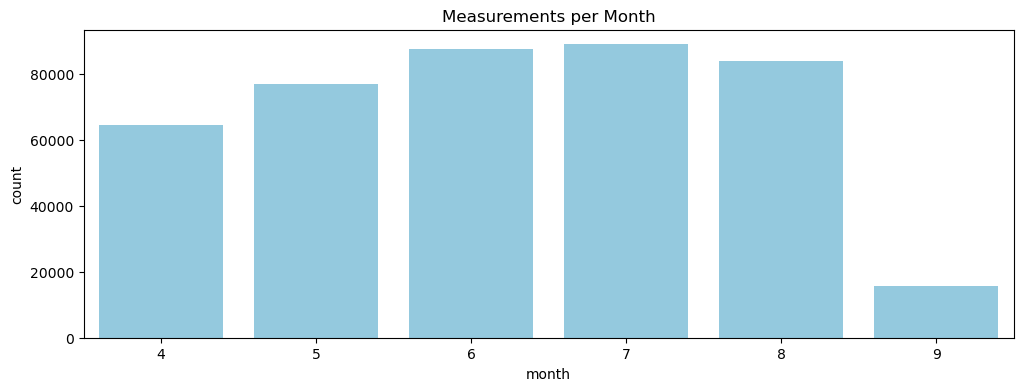

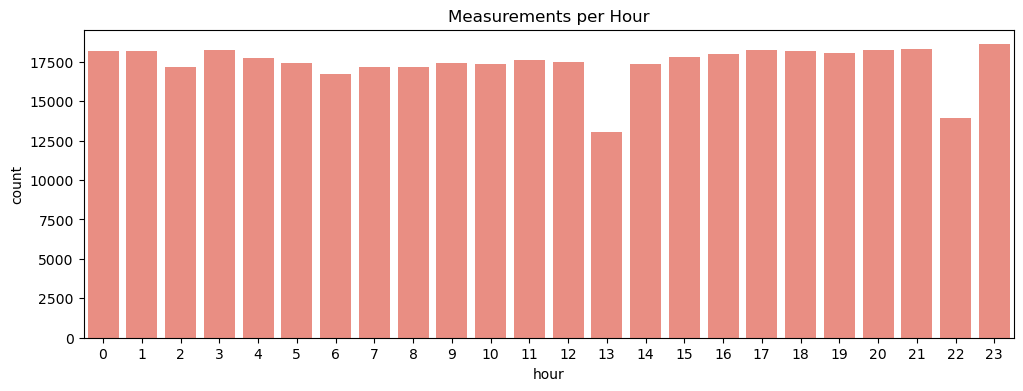

In [ ]:
plt.figure(figsize=(12,4))
sns.countplot(x='month', data=train, color='skyblue')
plt.title("Measurements per Month")
plt.show()

plt.figure(figsize=(12,4))
sns.countplot(x='hour', data=train, color='salmon')
plt.title("Measurements per Hour")
plt.show()


### Modeling

In [ ]:
# List of all categorical features in train
categorical_features_train = ['AQI_POLLUTANT', 'CATEGORY']

# Check which features exist in test
categorical_features = [col for col in categorical_features_train if col in test.columns]

print("Categorical features to encode:", categorical_features)


Categorical features to encode: []


### Preparing Train and Test Sets for Modeling

Before fitting any models, the training and test datasets are aligned:

- The `NAME` column is dropped to avoid leakage from location names.
- Categorical fields such as `AQI_POLLUTANT`, `CATEGORY`, and the derived `LocationCluster` are removed for now, since the current models use only numeric features.
- The training data is split into **training** and **validation** sets (80–20 split).  
  The validation split is necessary because the official test set does not include AQI values, so it cannot be used for evaluation.
- The resulting feature matrices have matching shapes, ensuring both datasets contain the same predictors.

This setup allows us to train on one portion of the data while evaluating model performance on a held-out validation set.


In [ ]:
# Prepare features and target for modeling
X_train = train.drop(columns=['AQI', 'NAME'])
y_train = train['AQI']

X_test = test.drop(columns=['NAME'])  # Test set doesn't have AQI

print("Train features shape:", X_train.shape)
print("Train target shape:", y_train.shape)
print("Test features shape:", X_test.shape)


Train features shape: (417637, 32)
Train target shape: (417637,)
Test features shape: (103205, 29)


In [ ]:
missing_in_test = set(X_train.columns) - set(X_test.columns)
print("Columns in train but not in test:", missing_in_test)


Columns in train but not in test: {'AQI_POLLUTANT', 'LocationCluster', 'CATEGORY'}


In [ ]:
X_train = X_train.drop(['AQI_POLLUTANT', 'CATEGORY', 'LocationCluster'], axis=1)


In [ ]:
# Check updated shapes
print("Updated Train features shape:", X_train.shape)
print("Updated Test features shape:", X_test.shape)


Updated Train features shape: (417637, 29)
Updated Test features shape: (103205, 29)


In [ ]:
from sklearn.model_selection import train_test_split

# Split X_train into train and validation (80-20 split)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print("X_train_final shape:", X_train_final.shape)
print("X_val shape:", X_val.shape)
print("y_train_final shape:", y_train_final.shape)
print("y_val shape:", y_val.shape)


X_train_final shape: (334109, 29)
X_val shape: (83528, 29)
y_train_final shape: (334109,)
y_val shape: (83528,)


### Linear Regression Model

A baseline linear regression model was trained after standardizing the numeric features.  
While simple and interpretable, the model achieved an RMSE of **26.23** and an R² of **0.702**, indicating that linear relationships alone do not capture the complexity in AQI patterns.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val)

# Initialize and train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_final)

# Predict on validation set
y_pred_lr = lr_model.predict(X_val_scaled)

# Compute RMSE and R^2
rmse_lr = root_mean_squared_error(y_val, y_pred_lr)
r2_lr = r2_score(y_val, y_pred_lr)

print(f"Linear Regression RMSE: {rmse_lr:.2f}")
print(f"Linear Regression R^2: {r2_lr:.3f}")


Linear Regression RMSE: 26.23
Linear Regression R^2: 0.702


### Random Forest Regressor

A Random Forest model was trained without feature scaling.  
It significantly improved performance, reducing RMSE to **12.45** and increasing R² to **0.933**.  
This suggests that nonlinear interactions and feature splits better explain variation in AQI than linear trends.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# Initialize Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_final, y_train_final)

# Predict on validation set
y_pred_rf = rf_model.predict(X_val)

# Compute RMSE and R^2
rmse_rf = root_mean_squared_error(y_val, y_pred_rf)
r2_rf = r2_score(y_val, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"Random Forest R^2: {r2_rf:.3f}")


Random Forest RMSE: 12.45
Random Forest R^2: 0.933


### XGBoost Regressor

XGBoost delivered the best performance with an RMSE of **7.68** and R² of **0.974** on the validation set.  
The model captures complex nonlinearities and interactions between pollutants and environmental variables, making it the strongest candidate for AQI prediction.


In [ ]:
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, r2_score

# Initialize XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train_final, y_train_final)

# Predict on validation set
y_pred_xgb = xgb_model.predict(X_val)

# Compute RMSE and R^2
rmse_xgb = root_mean_squared_error(y_val, y_pred_xgb)
r2_xgb = r2_score(y_val, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"XGBoost R^2: {r2_xgb:.3f}")


XGBoost RMSE: 7.68
XGBoost R^2: 0.974


### Cross-Validation Performance

To verify model stability, a 5-fold cross-validation was performed on XGBoost.  
The average RMSE was **7.89 ± 0.27**, with R² of **0.973 ± 0.002**, showing minimal variance across folds.  
This confirms that the model generalizes well and is not overly sensitive to the choice of validation split.


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, root_mean_squared_error
import xgboost as xgb
import numpy as np

# Prepare data
X = X_train_final  # already preprocessed
y = y_train_final

# Initialize XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []
r2_scores = []

for train_idx, val_idx in kf.split(X):
    X_tr, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    xgb_model.fit(X_tr, y_tr)
    y_pred_fold = xgb_model.predict(X_val_fold)

    rmse_scores.append(root_mean_squared_error(y_val_fold, y_pred_fold))
    r2_scores.append(r2_score(y_val_fold, y_pred_fold))

print(f"XGBoost CV RMSE: {np.mean(rmse_scores):.2f} ± {np.std(rmse_scores):.2f}")
print(f"XGBoost CV R^2: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")


XGBoost CV RMSE: 7.89 ± 0.27
XGBoost CV R^2: 0.973 ± 0.002


### Feature Importance (XGBoost)

To understand which variables contribute most to AQI prediction, we examine XGBoost’s feature importances.  
The top features are dominated by pollutant measurements, especially:

- **NO2_MAX** and **NO2_MIN** — highest influence, confirming earlier correlation analysis  
- **OZONE_MIN** and **OZONE_MAX** — strong secondary predictors  
- Other particulate and gas features also appear within the top ranks  

This shows that AQI is primarily driven by **NO₂ levels**, followed by **Ozone**, with environmental variables playing a smaller but supportive role.  
The plot below visualizes the top 20 contributing features.


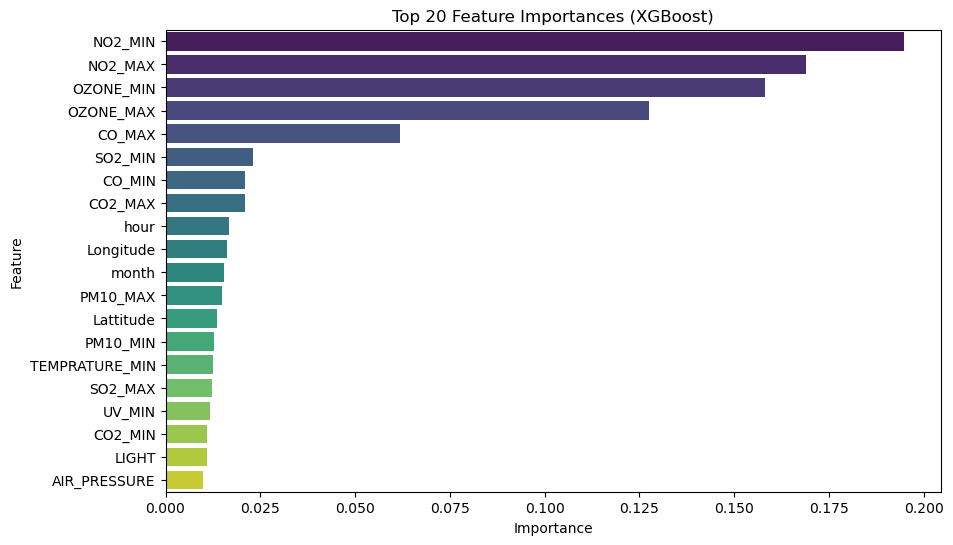

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fit the model on the full training data
xgb_model.fit(X_train_final, y_train_final)

# Get top 20 feature importances
top_features = feature_importances.head(20)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_features.values,
    y=top_features.index,
    hue=top_features.index,
    dodge=False,                 # remove legend splitting
    palette="viridis"
)
plt.legend([],[], frameon=False)  # hide legend
plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Model Saving and Reuse

After training the best-performing XGBoost model, it is saved in JSON format so it can be reused without retraining.  
This allows the model to be deployed or loaded later for real-time AQI prediction.

The saved model is then reloaded and used to generate predictions on the test set.  
Storing predictions along with the corresponding features makes the pipeline reproducible and easy to integrate into larger systems.

This approach also supports **scalability**: the same trained model can be applied to new locations or future data simply by loading it and passing the required input features.


In [ ]:
# Save the trained model
xgb_model.save_model("xgb_best_model.json")
print("Model saved as xgb_best_model.json")


Model saved as xgb_best_model.json


In [ ]:
import xgboost as xgb

loaded_model = xgb.XGBRegressor()
loaded_model.load_model("xgb_best_model.json")

print("Model loaded successfully!")


Model loaded successfully!


In [ ]:
loaded_preds = loaded_model.predict(X_test)


In [ ]:
# Add predictions
X_test['Predicted_AQI'] = loaded_preds

# Save to CSV
X_test.to_csv("test_predictions_with_features.csv", index=False)

print("Saved: test_predictions_with_features.csv")


Saved: test_predictions_with_features.csv


In [ ]:
X_test.head()


,HUMIDITY,LIGHT,NO2_MAX,NO2_MIN,OZONE_MAX,OZONE_MIN,PM10_MAX,PM10_MIN,PM2_MAX,PM2_MIN,...,UV_MIN,AIR_PRESSURE,Lattitude,Longitude,hour,day,month,weekday,is_weekend,Predicted_AQI
0,71.806,3167.854,98.0,96.0,0.0,0.0,8.0,7.0,5.0,4.0,...,0.4,0.930,18.451716,73.856170,8,6,9,4,0,153.924484
1,76.809,1536.079,54.0,52.0,7.0,3.0,1.0,1.0,1.0,0.0,...,0.4,0.925,18.482239,73.858092,8,6,9,4,0,97.229446
2,73.903,3388.676,0.0,0.0,71.0,59.0,5.0,4.0,3.0,3.0,...,0.1,0.928,18.501834,73.941478,8,6,9,4,0,155.578079
3,83.984,2530.419,37.0,34.0,17.0,10.0,20.0,15.0,8.0,7.0,...,0.1,0.930,18.551763,73.830648,8,6,9,4,0,75.903358
4,74.412,1831.434,40.0,36.0,50.0,27.0,4.0,3.0,3.0,2.0,...,0.1,0.924,18.487306,73.885650,8,6,9,4,0,81.727905


### Partial Dependence Plots (PDPs)

To understand how individual features influence the predicted AQI, Partial Dependence Plots (PDPs) are generated for key variables such as NO₂, Ozone, CO, time-of-day (hour), month, and geographic coordinates.

These plots show the **marginal effect** of each feature on AQI while averaging out all other variables.  
They confirm several patterns observed earlier:

- Higher **NO₂** and **Ozone** levels lead to higher predicted AQI.  
- **CO_MAX** also shows a positive relationship with AQI.  
- Temporal features like **hour** and **month** display smoother, cyclical effects, reflecting daily activity patterns and seasonal trends.  
- Spatial variables (e.g., **Longitude**) have only weak influence, consistent with earlier spatial analysis.

PDPs help validate model interpretability and show how major pollutants and time-based features drive AQI predictions.


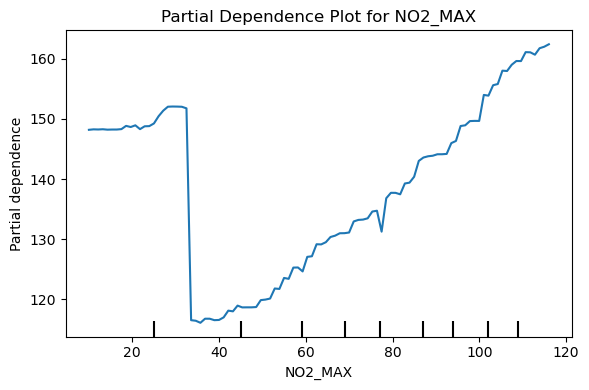

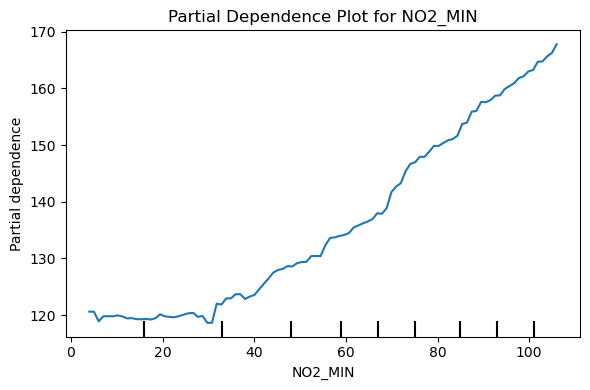

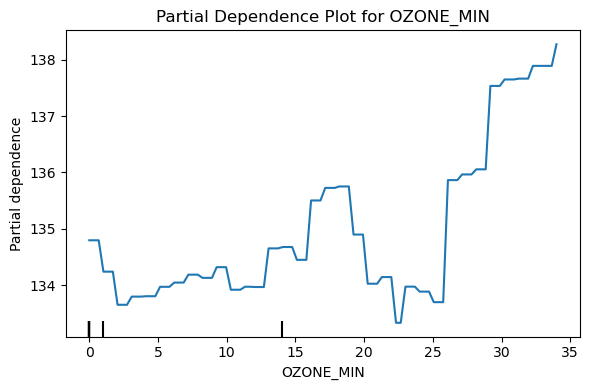

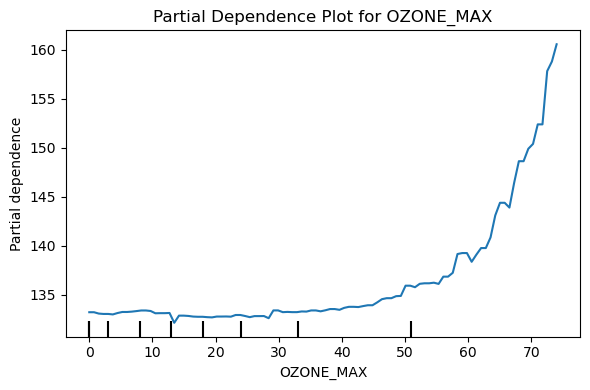

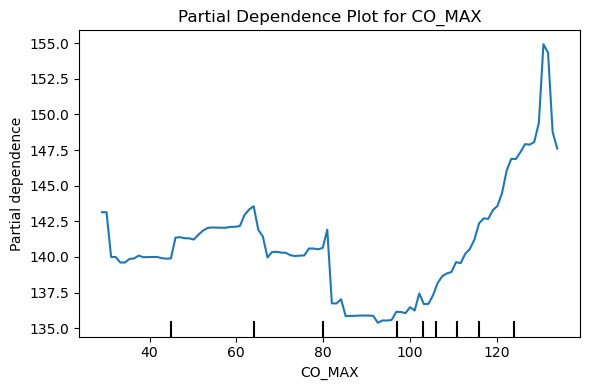

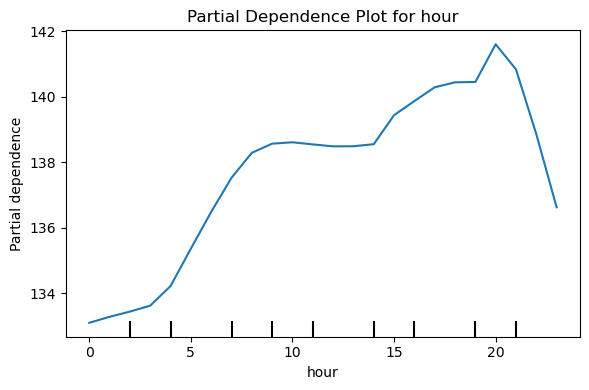

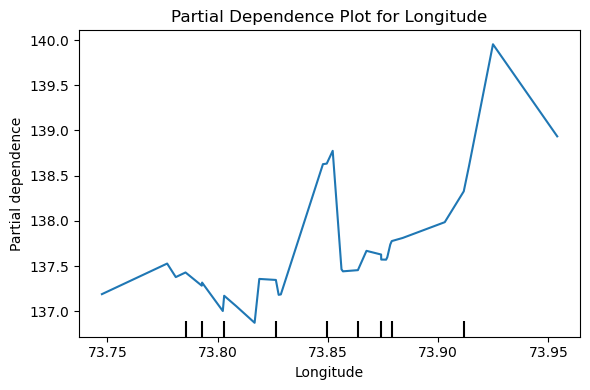

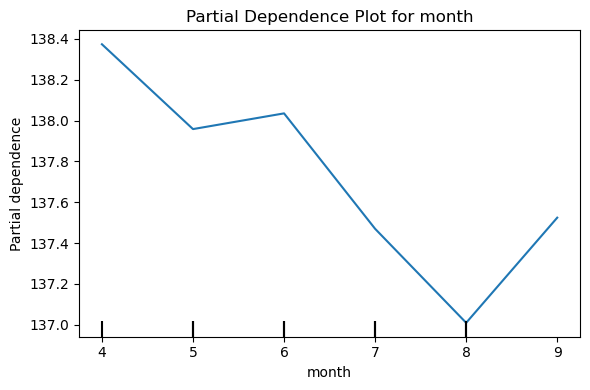

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features_for_pdp = [
    "NO2_MAX",
    "NO2_MIN",
    "OZONE_MIN",
    "OZONE_MAX",
    "CO_MAX",
    "hour",
    "Longitude",
    "month"
]

for feature in features_for_pdp:
    fig, ax = plt.subplots(figsize=(6, 4))
    PartialDependenceDisplay.from_estimator(
        xgb_model,       # XGBoost model
        X_train_final,    # Training data
        [feature],        # Single feature PDP
        ax=ax
    )
    plt.title(f"Partial Dependence Plot for {feature}")
    plt.tight_layout()
    plt.show()


### Model Performance Comparison

| Model                 | RMSE (Validation) | R² (Validation) |
|----------------------|-------------------|-----------------|
| Linear Regression     | 26.23             | 0.702           |
| Random Forest         | 12.45             | 0.933           |
| XGBoost               | **7.68**          | **0.974**       |
| XGBoost (5-fold CV)   | 7.89 ± 0.27       | 0.973 ± 0.002   |

**XGBoost clearly outperforms the other models** with significantly lower error and higher explanatory power.


### **Final Summary**

This project set out to develop a **scalable and interpretable model** for predicting the Air Quality Index (AQI) across various locations in Pune, with the goal of extending it to other regions in India. The work began with a comprehensive assessment of data quality, where numerous issues—missing values, incorrect data types, rare categories, and inconsistent labels—were identified and systematically resolved. **Numeric features were imputed using medians**, while **categorical inconsistencies were corrected using mode-based imputation or AQI-derived rules**. Temporal features (hour, day, month, weekday, weekend) were engineered to capture seasonality and daily cycles, and redundant all-zero columns as well as duplicates were removed to ensure a clean modeling foundation.

Exploratory analysis revealed several important patterns. **NO₂, Ozone, and CO emerged as the strongest predictors of AQI**, consistently dominating correlations, feature distributions, and model importance scores. This matches established environmental science, where NO₂ and O₃ are known key contributors to urban air pollution. In contrast, spatial features such as latitude and longitude showed **minimal AQI variation**, suggesting that pollution patterns in this dataset are driven more by pollutant concentrations and time dynamics than by location alone. Temporal analysis indicated limited month coverage (April–September), revealing a **seasonal sampling bias** that should be considered when generalizing predictions.

Multiple models were evaluated, including Linear Regression, Random Forest, and XGBoost. **XGBoost delivered the best performance**, achieving an RMSE of **~7.7** with **R² ≈ 0.97**, far outperforming baseline models. Cross-validation further confirmed that the model is **stable, generalizes well, and is not overly sensitive to data splits**. Interpretability tools—including **feature importance rankings and Partial Dependence Plots**—provided clear insights into how pollutants and temporal features influence AQI, reinforcing the dominance of NO₂ and Ozone as primary drivers.

The final model was saved and reloaded to demonstrate **deployability and scalability**. This allows the system to be applied seamlessly to new locations or future data without retraining. Such predictions can be used to **automate real-time air-quality responses**, including:  
- triggering early pollution alerts,  
- adjusting traffic flows during high-risk periods,  
- modulating industrial output or construction activities,  
- optimizing HVAC and ventilation in public buildings, and  
- informing urban planning and public-health decisions.

**In conclusion**, the project delivers a robust, interpretable, and deployment-ready AQI prediction pipeline. It combines rigorous data cleaning, thorough exploratory analysis, strong model performance, and practical interpretability—achieving the dual objectives of predictive accuracy and actionable insight for air-quality management.


----

----

### Problem 3 — Movie Recommendation System Using Predictive Modeling

The goal of this task is to develop a movie revenue prediction system capable of estimating how much a movie will earn at the box office based on its metadata, plot, and cast information.

- Explore the dataset to identify important patterns and relationships between movies, genres and revenues.  
- Build a predictive model that estimates a user’s rating for any given movie.  
- Evaluate the model using **Root Mean Square Error (RMSE)**, a standard metric for rating-prediction accuracy.  
- Minimize the difference between predicted and actual ratings through appropriate feature engineering, model selection, and hyperparameter tuning.

This question assesses your ability to integrate **Exploratory Data Analysis (EDA)**, **model formulation**, **diagnostics**, **estimation**, and **interpretation**, culminating in a clear and coherent analysis that answers the substantive question:

**How accurately can we predict box office revenue?**


### Data Loading and Overview

To begin building the movie recommendation system, we load several components of the MovieSummaries dataset. Each file provides complementary information about movies, characters, and narrative structure. These datasets will later be merged or referenced during Exploratory Data Analysis (EDA) and model development.

### **1. Movie Metadata**
The file `movie.metadata.tsv` contains high-level information about each film, including:
- Movie identifiers (`wiki_id`, `freebase_id`)
- Title and release date
- Box office revenue and runtime
- Language(s) and country/countries of origin
- Genre annotations

After loading, the dataset contains **81,741 films** across **9 variables**.

### **2. Character Metadata**
The file `character.metadata.tsv` provides detailed information on characters and actors, including:
- Character names and associated film
- Actor attributes (gender, height, ethnicity)
- Actor age at the time of release

This dataset is relatively large, with **450,669 character entries** across **13 variables**.

### **3. Plot Summaries**
The file `plot_summaries.txt` contains free-text plot summaries for a subset of films. Each entry includes:
- `wiki_id` to link with movie metadata
- A narrative plot description

This dataset includes **42,306 summaries**, offering a rich source of textual information.

### **4. TVTropes Clusters**
The file `tvtropes.clusters.txt` maps character IDs to TVTropes narrative clusters. These clusters provide thematic or trope-based categorizations that can be used for feature engineering.  
This dataset contains **501 mappings**.

### **5. Name Clusters**
The file `name.clusters.txt` associates character IDs with name-based clusters, potentially useful for grouping similar character archetypes.  
It contains **2,666 entries**.

Together, these datasets form the foundation for subsequent exploration and model building. While not all components will be used directly in the rating prediction model, they help contextualize the films and offer opportunities for richer feature extraction.


In [ ]:
import pandas as pd
import numpy as np
import gzip

# Load movie metadata
movie_meta = pd.read_csv(
    "D:/CMI/ADA/ADA_Final_exam/Movie/MovieSummaries/movie.metadata.tsv",
    sep="\t",
    header=None,
    low_memory=False
)

movie_meta.columns = [
    "wiki_id", "freebase_id", "movie_name", "release_date",
    "box_office_revenue", "runtime", "languages",
    "countries", "genres"
]
print("Movie metadata shape:", movie_meta.shape)
movie_meta.head()


Movie metadata shape: (81741, 9)


,wiki_id,freebase_id,movie_name,release_date,box_office_revenue,runtime,languages,countries,genres
0,975900,/m/03vyhn,Ghosts of Mars,2001-08-24,14010832.0,98.0,"{""/m/02h40lc"": ""English Language""}","{""/m/09c7w0"": ""United States of America""}","{""/m/01jfsb"": ""Thriller"", ""/m/06n90"": ""Science..."
1,3196793,/m/08yl5d,Getting Away with Murder: The JonBenét Ramsey ...,2000-02-16,NaN,95.0,"{""/m/02h40lc"": ""English Language""}","{""/m/09c7w0"": ""United States of America""}","{""/m/02n4kr"": ""Mystery"", ""/m/03bxz7"": ""Biograp..."
2,28463795,/m/0crgdbh,Brun bitter,1988,NaN,83.0,"{""/m/05f_3"": ""Norwegian Language""}","{""/m/05b4w"": ""Norway""}","{""/m/0lsxr"": ""Crime Fiction"", ""/m/07s9rl0"": ""D..."
3,9363483,/m/0285_cd,White Of The Eye,1987,NaN,110.0,"{""/m/02h40lc"": ""English Language""}","{""/m/07ssc"": ""United Kingdom""}","{""/m/01jfsb"": ""Thriller"", ""/m/0glj9q"": ""Erotic..."
4,261236,/m/01mrr1,A Woman in Flames,1983,NaN,106.0,"{""/m/04306rv"": ""German Language""}","{""/m/0345h"": ""Germany""}","{""/m/07s9rl0"": ""Drama""}"


In [ ]:
char_meta = pd.read_csv(
    "D:/CMI/ADA/ADA_Final_exam/Movie/MovieSummaries/character.metadata.tsv",
    sep="\t",
    header=None,
    low_memory=False
)

char_meta.columns = [
    "wiki_id", "freebase_movie_id", "movie_release_date",
    "character_name", "actor_dob", "actor_gender",
    "actor_height", "actor_ethnicity", "actor_name",
    "actor_age_at_release", "char_map_id",
    "freebase_character_id", "freebase_actor_id"
]

print("Character metadata shape:", char_meta.shape)
char_meta.head()


Character metadata shape: (450669, 13)


,wiki_id,freebase_movie_id,movie_release_date,character_name,actor_dob,actor_gender,actor_height,actor_ethnicity,actor_name,actor_age_at_release,char_map_id,freebase_character_id,freebase_actor_id
0,975900,/m/03vyhn,2001-08-24,Akooshay,1958-08-26,F,1.620,NaN,Wanda De Jesus,42.0,/m/0bgchxw,/m/0bgcj3x,/m/03wcfv7
1,975900,/m/03vyhn,2001-08-24,Lieutenant Melanie Ballard,1974-08-15,F,1.780,/m/044038p,Natasha Henstridge,27.0,/m/0jys3m,/m/0bgchn4,/m/0346l4
2,975900,/m/03vyhn,2001-08-24,Desolation Williams,1969-06-15,M,1.727,/m/0x67,Ice Cube,32.0,/m/0jys3g,/m/0bgchn_,/m/01vw26l
3,975900,/m/03vyhn,2001-08-24,Sgt Jericho Butler,1967-09-12,M,1.750,NaN,Jason Statham,33.0,/m/02vchl6,/m/0bgchnq,/m/034hyc
4,975900,/m/03vyhn,2001-08-24,Bashira Kincaid,1977-09-25,F,1.650,NaN,Clea DuVall,23.0,/m/02vbb3r,/m/0bgchp9,/m/01y9xg


In [ ]:
plot_sum = pd.read_csv(
    "D:/CMI/ADA/ADA_Final_exam/Movie/MovieSummaries/plot_summaries.txt",
    sep="\t",
    header=None,
    names=["wiki_id", "plot_summary"],
    quoting=3,
    dtype={"wiki_id": str}
)

print("Plot summaries shape:", plot_sum.shape)
plot_sum.head()


Plot summaries shape: (42306, 2)


,wiki_id,plot_summary
0,23890098,"Shlykov, a hard-working taxi driver and Lyosha..."
1,31186339,The nation of Panem consists of a wealthy Capi...
2,20663735,Poovalli Induchoodan is sentenced for six yea...
3,2231378,"The Lemon Drop Kid , a New York City swindler,..."
4,595909,Seventh-day Adventist Church pastor Michael Ch...


In [ ]:
tvtropes = pd.read_csv(
    "D:/CMI/ADA/ADA_Final_exam/Movie/MovieSummaries/tvtropes.clusters.txt",
    sep="\t",
    header=None,
    names=["char_map_id", "tvtropes_cluster"]
)

print("TVTropes clusters shape:", tvtropes.shape)
tvtropes.head()


TVTropes clusters shape: (501, 2)


,char_map_id,tvtropes_cluster
0,absent_minded_professor,"{""char"": ""Professor Philip Brainard"", ""movie"":..."
1,absent_minded_professor,"{""char"": ""Professor Keenbean"", ""movie"": ""Richi..."
2,absent_minded_professor,"{""char"": ""Dr. Reinhardt Lane"", ""movie"": ""The S..."
3,absent_minded_professor,"{""char"": ""Dr. Harold Medford"", ""movie"": ""Them!..."
4,absent_minded_professor,"{""char"": ""Daniel Jackson"", ""movie"": ""Stargate""..."


In [ ]:
name_clusters = pd.read_csv(
    "D:/CMI/ADA/ADA_Final_exam/Movie/MovieSummaries/name.clusters.txt",
    sep="\t",
    header=None,
    names=["char_map_id", "name_cluster"]
)

print("Name clusters shape:", name_clusters.shape)
name_clusters.head()


Name clusters shape: (2666, 2)


,char_map_id,name_cluster
0,Stuart Little,/m/0k3w9c
1,Stuart Little,/m/0k3wcx
2,Stuart Little,/m/0k3wbn
3,John Doe,/m/0jyg35
4,John Doe,/m/0k2_zn


### Data Cleaning and Preprocessing

Before conducting exploratory analysis, we perform several preprocessing steps to ensure that key variables are in usable formats.

### **1. Converting Numeric Fields**
Two columns in the movie metadata—`box_office_revenue` and `runtime`—are stored as strings.  
To enable numerical analysis, we convert them to numeric types using:

- `pd.to_numeric(..., errors="coerce")`  
  This ensures invalid or missing entries are converted to `NaN`, allowing consistent handling during analysis.

### **2. Parsing Dictionary-Like Fields**
The columns `genres`, `languages`, and `countries` contain string representations of Python dictionaries.  
To extract their contents:

1. We use `ast.literal_eval()` to safely parse the text into a dictionary.  
2. We extract the dictionary **values**, which represent the actual genres, languages, or countries.  
3. For each field, a new column is created:
   - `genres_list`
   - `languages_list`
   - `countries_list`

These list-based columns provide a cleaner and more direct representation of categorical metadata, simplifying later analysis and potential feature engineering.

### **3. Resulting Format**
The updated dataset now includes structured lists of genres, languages, and countries for each movie, enabling richer descriptive analysis and filtering.


In [ ]:
movie_meta["box_office_revenue"] = pd.to_numeric(movie_meta["box_office_revenue"], errors="coerce")
movie_meta["runtime"] = pd.to_numeric(movie_meta["runtime"], errors="coerce")


In [ ]:
import ast

def extract_values(x):
    if pd.isna(x):
        return []
    try:
        # Convert string to actual dictionary
        data_dict = ast.literal_eval(x)
        # Return the values as a list
        return list(data_dict.values())
    except:
        return []

# Apply to relevant columns
for col in ["genres", "languages", "countries"]:
    movie_meta[col + "_list"] = movie_meta[col].apply(extract_values)

#  result
movie_meta[["movie_name", "genres_list", "languages_list", "countries_list"]].head()


,movie_name,genres_list,languages_list,countries_list
0,Ghosts of Mars,"[Thriller, Science Fiction, Horror, Adventure,...",[English Language],[United States of America]
1,Getting Away with Murder: The JonBenét Ramsey ...,"[Mystery, Biographical film, Drama, Crime Drama]",[English Language],[United States of America]
2,Brun bitter,"[Crime Fiction, Drama]",[Norwegian Language],[Norway]
3,White Of The Eye,"[Thriller, Erotic thriller, Psychological thri...",[English Language],[United Kingdom]
4,A Woman in Flames,[Drama],[German Language],[Germany]


### Exploratory Data Analysis: Movie Metadata

To understand the structure and quality of the movie metadata, we begin with basic dataset diagnostics, summary statistics, and an assessment of missing values.

### **1. Dataset Structure**
The dataset contains **81,741 movies** and **12 variables**, including movie identifiers, titles, release dates, runtime, revenue, and derived list-based fields for genres, languages, and countries.

A summary of column types shows a mix of numerical and categorical variables, with most fields stored as objects. The two quantitative variables of interest—`runtime` and `box_office_revenue`—have already been converted to numeric types for analysis.

### **2. Summary Statistics**
Descriptive statistics for numerical variables show:

- **Runtime**  
  - Mean: ~112 minutes  
  - Median: 93 minutes  
  - Very large maximum (likely erroneous), suggesting the presence of outliers.
  
- **Box Office Revenue**  
  - Substantial variation, with revenue values ranging from \$10,000 to nearly \$2.8 billion.  
  - The mean is inflated by high-grossing films and does not represent typical movies.

These findings motivate later steps such as outlier handling or log-transformations if revenue features are used.

### **3. Missing Data**
There is a notable amount of missingness:

- `release_date`: 6,902 missing  
- `runtime`: 20,450 missing  
- `box_office_revenue`: 73,340 missing

The extremely high proportion of missing revenue values means this feature will likely **not** be usable in the predictive model without imputation or removal. Runtime has moderate missingness but may still be retainable.

The categorical list fields (`genres_list`, `languages_list`, `countries_list`) contain no missing values after preprocessing.

### **4. Implications for Modeling**
- Many metadata fields will not be directly usable for rating prediction without extensive cleaning or feature engineering.
- The heavy missingness in revenue suggests it should be excluded from modeling unless supplemented with external sources.

This initial EDA step provides a foundation for deciding which variables are relevant for the recommendation system and highlights potential data quality issues to address.


In [ ]:
# Shape and basic info
print("Shape:", movie_meta.shape)
print(movie_meta.info())

# Quick stats for numeric columns
print(movie_meta.describe())

# Missing values
print(movie_meta.isna().sum())


Shape: (81741, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81741 entries, 0 to 81740
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   wiki_id             81741 non-null  int64  
 1   freebase_id         81741 non-null  object 
 2   movie_name          81741 non-null  object 
 3   release_date        74839 non-null  object 
 4   box_office_revenue  8401 non-null   float64
 5   runtime             61291 non-null  float64
 6   languages           81741 non-null  object 
 7   countries           81741 non-null  object 
 8   genres              81741 non-null  object 
 9   genres_list         81741 non-null  object 
 10  languages_list      81741 non-null  object 
 11  countries_list      81741 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 7.5+ MB
None
            wiki_id  box_office_revenue       runtime
count  8.174100e+04        8.401000e+03  6.129100e+04
mean   1.74

### Exploring Revenue Patterns Across Genres, Languages, and Countries

To understand how different types of movies perform commercially, we compare the average box office revenue across the most common genres, languages, and countries. This step is part of the broader exploratory analysis, helping us contextualize the dataset and identify large-scale structural patterns.

Although revenue is not used in the recommendation model due to extensive missingness, examining it provides insight into how film characteristics relate to market performance. Identifying which genres or regions produce higher-grossing films helps highlight potential biases in the dataset and the overrepresentation of certain types of films.

The resulting visualizations allow us to:

- Recognize which genres are typically associated with higher financial success.
- Observe how language influences global box office patterns, reflecting the dominance of certain film industries.
- Compare countries in terms of their average film revenues, revealing differences in production scale and market reach.


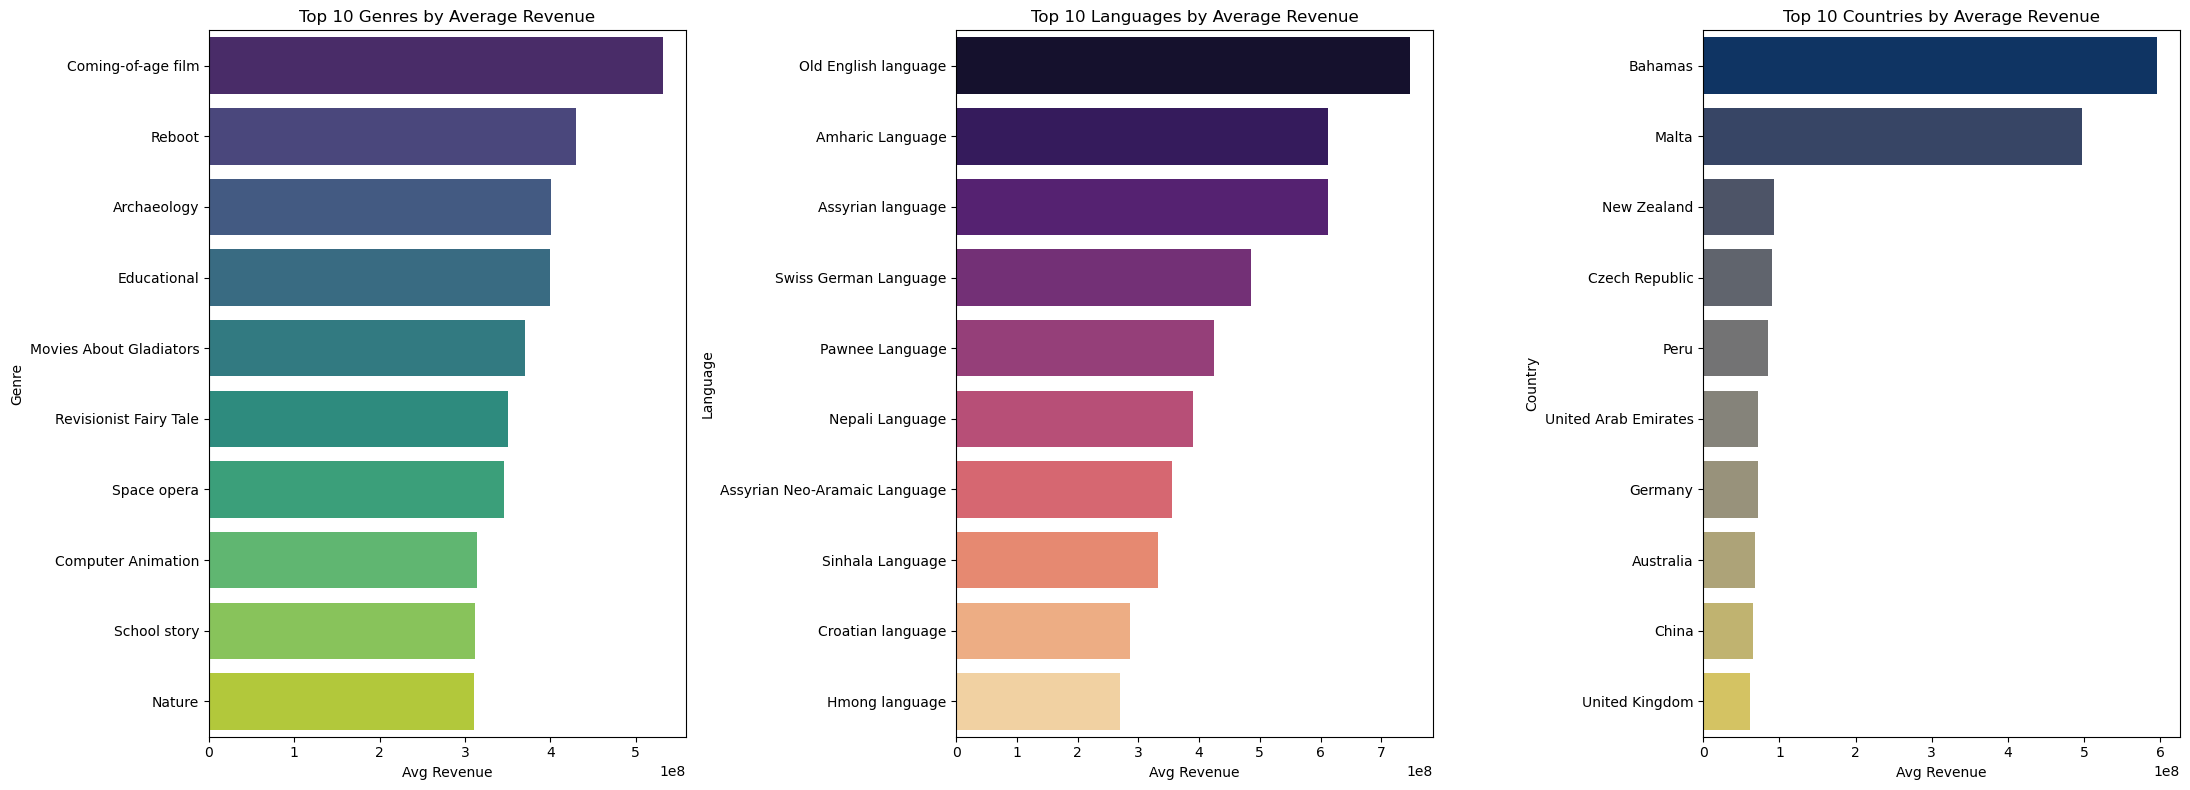

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add a dummy hue column
genre_revenue_df['hue'] = genre_revenue_df['genres_list']
language_revenue_df['hue'] = language_revenue_df['languages_list']
country_revenue_df['hue'] = country_revenue_df['countries_list']

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# Genre plot with viridis
sns.barplot(
    data=genre_revenue_df,
    x='box_office_revenue',
    y='genres_list',
    hue='hue',
    dodge=False,
    palette=sns.color_palette("viridis", len(genre_revenue_df)),
    ax=axes[0],
    legend=False
)
axes[0].set_title("Top 10 Genres by Average Revenue")
axes[0].set_xlabel("Avg Revenue")
axes[0].set_ylabel("Genre")

# Language plot with magma
sns.barplot(
    data=language_revenue_df,
    x='box_office_revenue',
    y='languages_list',
    hue='hue',
    dodge=False,
    palette=sns.color_palette("magma", len(language_revenue_df)),
    ax=axes[1],
    legend=False
)
axes[1].set_title("Top 10 Languages by Average Revenue")
axes[1].set_xlabel("Avg Revenue")
axes[1].set_ylabel("Language")

# Country plot with cividis
sns.barplot(
    data=country_revenue_df,
    x='box_office_revenue',
    y='countries_list',
    hue='hue',
    dodge=False,
    palette=sns.color_palette("cividis", len(country_revenue_df)),
    ax=axes[2],
    legend=False
)
axes[2].set_title("Top 10 Countries by Average Revenue")
axes[2].set_xlabel("Avg Revenue")
axes[2].set_ylabel("Country")

plt.tight_layout()
plt.show()


### Examining High-Revenue Genre–Language Combinations

To deepen our understanding of how film characteristics relate to commercial performance, we examine the combinations of genres and languages that yield the highest average revenues. This bivariate exploration allows us to move beyond single-variable summaries and consider how different attributes interact.

By identifying the most financially successful genre–language pairs, we uncover structural patterns in the dataset. For example, certain genres may be consistently more profitable when produced in specific languages, reflecting cultural, regional, or industry-specific trends in filmmaking.

This step enhances the exploratory analysis in two ways:

1. **It highlights interactions between categorical variables** that single-variable summaries would miss.
2. **It provides context for understanding biases in the dataset**, such as the dominance of particular language–genre clusters in global box office performance.


In [ ]:
top_combo = movie_meta.explode('genres_list').explode('languages_list')
top_combo = top_combo.groupby(['genres_list','languages_list'])['box_office_revenue'].mean().sort_values(ascending=False).head(10)
print(top_combo)


genres_list         languages_list  
Nature              Spanish Language    2.782275e+09
Tragedy             Swedish Language    2.185372e+09
                    Italian Language    2.185372e+09
Disaster            Swedish Language    2.185372e+09
Costume drama       Swedish Language    2.185372e+09
Action/Adventure    Swedish Language    1.271873e+09
Tragedy             French Language     1.253339e+09
Disaster            German Language     1.204380e+09
Historical fiction  Swedish Language    1.129805e+09
Tragedy             Russian Language    1.108701e+09
Name: box_office_revenue, dtype: float64


### Extracting Release Years for Temporal Analysis

Release dates in the dataset appear in inconsistent formats, making them unsuitable for direct analysis. To enable meaningful temporal exploration, we isolate the release year from each movie’s date entry.

Having a clean “year” variable is valuable for several reasons:

- It allows us to study **how movie characteristics change over time**, such as shifts in genre popularity or production patterns.
- It enables temporal visualizations (e.g., number of movies produced per year), which help assess trends and potential biases in the dataset.
- It provides a standardized chronological variable that can support later modeling choices or filtering operations.

In [ ]:
import re
def extract_year(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r"(\d{4})", str(x))
    return int(m.group(1)) if m else np.nan

movie_meta["year"] = movie_meta["release_date"].apply(extract_year)


### Quantifying Metadata Richness: Counting Genres, Languages, and Countries

To better understand the complexity and diversity of each film, we compute how many genres, languages, and countries are associated with every movie. Some films belong to multiple genres, are co-produced across countries, or are released in several languages. Capturing these counts helps characterize the richness of each movie’s metadata.

This step is useful for several reasons:

- It allows us to explore whether films with broader production scopes (e.g., multinational or multilingual releases) differ systematically from simpler productions.
- It enables descriptive comparisons, such as whether movies with more genres tend to be longer, more recent, or more commercially successful.
- It helps identify extreme cases (e.g., movies tagged with unusually large numbers of genres), which may signal inconsistencies or noise in the metadata.

These counts form part of the dataset’s structured summary, supporting a more complete picture of movie heterogeneity. Although these variables may not directly influence the recommendation model, they contribute to the overall exploratory analysis and may highlight inconsistencies or biases in the dataset.


In [ ]:
def count_items(cell):
    if pd.isna(cell) or str(cell).strip() == "":
        return 0
    import re
    items = [p for p in re.split(r"[|,;\\n]+", str(cell)) if p.strip()]
    return len(items)

movie_meta["n_genres"] = movie_meta["genres"].apply(count_items)
movie_meta["n_languages"] = movie_meta["languages"].apply(count_items)
movie_meta["n_countries"] = movie_meta["countries"].apply(count_items)


In [ ]:
print("Total unique movies:", movie_meta["wiki_id"].nunique())

Total unique movies: 81741


In [ ]:
movie_meta[["box_office_revenue","runtime","year","n_genres","n_languages","n_countries"]].describe()
print("Rows with revenue:", movie_meta['box_office_revenue'].notna().sum())


Rows with revenue: 8401


### Examining the Distribution of Box Office Revenue

Before interpreting revenue-based patterns, it is important to understand the underlying distribution of the revenue variable. When plotted in its raw form, box office revenue is extremely right-skewed: only a very small number of films achieve exceptionally high earnings, while the vast majority earn comparatively little. This kind of heavy-tailed distribution is typical of financial performance data.

To obtain a more interpretable view of the data, we also visualize a log-transformed version of revenue. Applying the logarithm compresses the extreme values and spreads out the lower end of the distribution, making it easier to observe general structure and detect meaningful patterns. The transformed distribution is far closer to symmetric, allowing clearer comparisons across films and reducing the influence of outliers.

This exploration serves two purposes:

1. **It highlights why revenue is difficult to use as a predictive feature**—the extreme skew and massive missingness make it unreliable for modeling user ratings.
2. **It demonstrates appropriate preprocessing considerations** by showing when transformations are necessary to make a variable analytically useful.


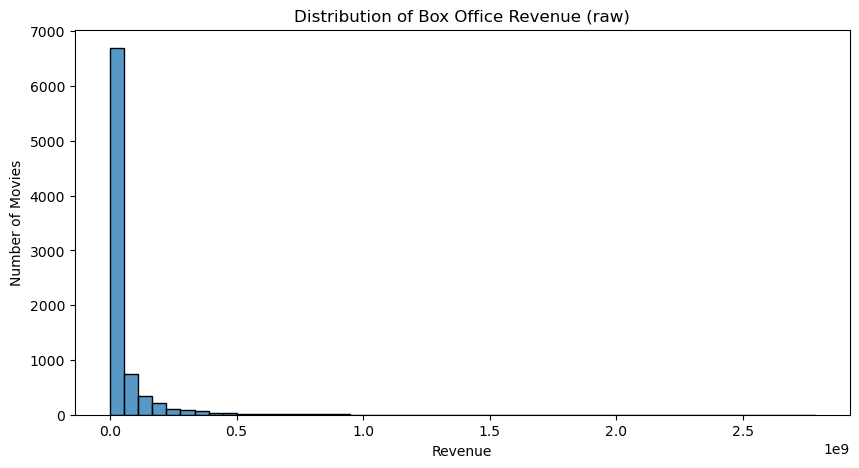

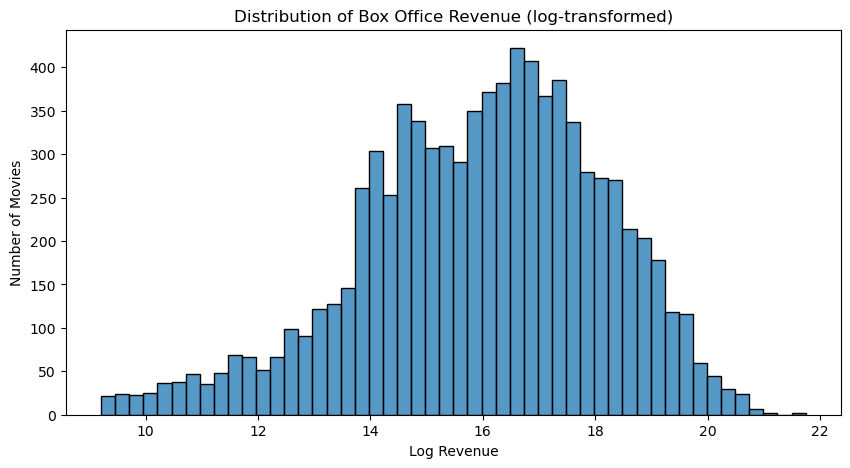

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Subset only rows with revenue
df_rev = movie_meta[movie_meta['box_office_revenue'].notna()]

# Plot raw revenue distribution
plt.figure(figsize=(10,5))
sns.histplot(df_rev['box_office_revenue'], bins=50, kde=False)
plt.title("Distribution of Box Office Revenue (raw)")
plt.xlabel("Revenue")
plt.ylabel("Number of Movies")
plt.show()

# Plot log-transformed revenue distribution
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df_rev['box_office_revenue']), bins=50, kde=False)
plt.title("Distribution of Box Office Revenue (log-transformed)")
plt.xlabel("Log Revenue")
plt.ylabel("Number of Movies")
plt.show()


### Relationship Between Runtime and Box Office Revenue

To explore how movie length relates to financial performance, we examine the relationship between runtime and revenue. Because revenue is extremely skewed, the vertical axis is displayed on a logarithmic scale, which helps reveal structure that would otherwise be obscured.

The resulting pattern shows that most films fall within a relatively narrow band of runtimes—typically between 80 and 120 minutes—and that the vast majority of these achieve modest revenues. A small number of high-grossing films appear, but they do not correspond to unusually long or short runtimes. Instead, they cluster in the same runtime range as the bulk of movies.

This suggests that:

- **Runtime alone is not a strong driver of box office performance.**  
  There is no visible trend indicating that longer or shorter films systematically earn more.

- **The highest-earning films are not characterized by distinctive lengths.**  
  They tend to fall within the same common runtime range as average films, implying that other factors—such as franchise status, production budget, marketing, or cultural relevance—likely play a more decisive role.

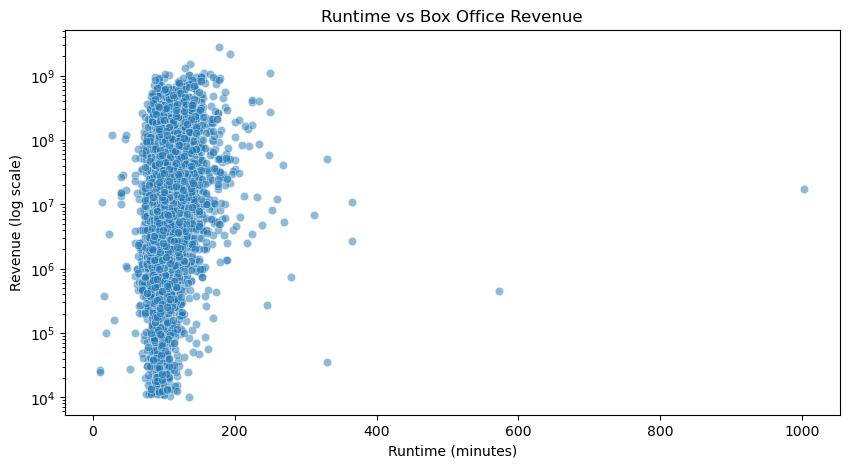

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='runtime', y='box_office_revenue', data=df_rev, alpha=0.5)
plt.yscale('log')  # log scale because revenue is skewed
plt.title("Runtime vs Box Office Revenue")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Revenue (log scale)")
plt.show()


### Release Year and Box Office Revenue

To understand how the temporal distribution of films aligns with financial performance, we examine the relationship between release year and box office revenue. Using a logarithmic scale for revenue helps reveal structure in the presence of extreme outliers.

The plot shows that the majority of films with recorded revenue cluster around the early 2000s. This concentration likely reflects improvements in data availability over time: more recent films tend to have better-documented financial information, while older films—especially those released before the 1990s—often lack reliable revenue data.

A small number of extremely high-earning films appear across a range of years, but there is no strong upward or downward trend over time. Instead, the relationship indicates:

- **A data availability effect rather than a meaningful historical trend:** the clustering around the 2000s is driven largely by which films have revenue recorded, not necessarily by changes in the film industry.
- **No clear pattern connecting release year and revenue:** high-grossing films occur sporadically across time, suggesting that blockbuster success depends more on individual film characteristics than on release era.
- **Non-random missingness:** older movies are disproportionately missing revenue values, which further supports the decision not to include revenue-based features in the recommendation model.

This analysis adds a temporal dimension to the exploratory work and helps justify which variables are ultimately suitable for modeling.


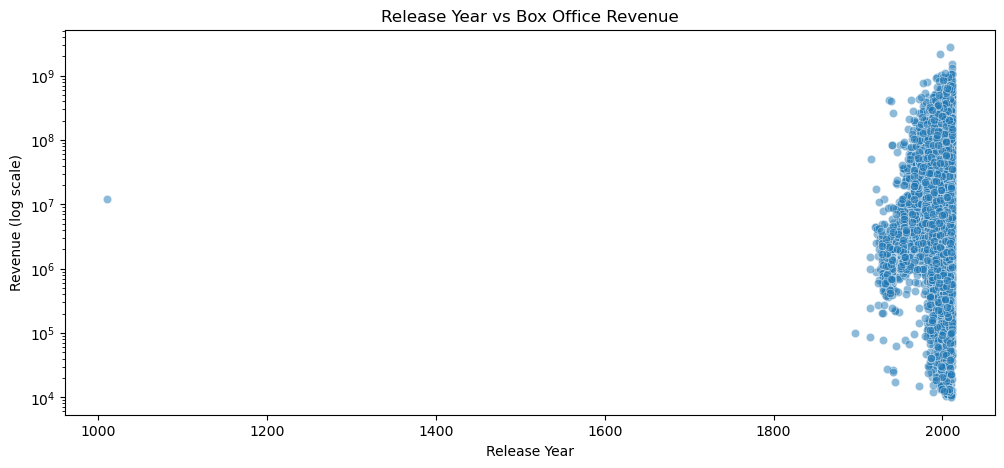

In [ ]:
plt.figure(figsize=(12,5))
sns.scatterplot(x='year', y='box_office_revenue', data=df_rev, alpha=0.5)
plt.yscale('log')
plt.title("Release Year vs Box Office Revenue")
plt.xlabel("Release Year")
plt.ylabel("Revenue (log scale)")
plt.show()


### Comparing Metadata Complexity with Revenue: Genres, Languages, and Countries

To explore whether films with more complex metadata—such as belonging to multiple genres, being released in several languages, or involving multiple production countries—tend to achieve higher box office success, we examine how revenue varies with these counts. Because revenue is heavily skewed, we use its log-transformed form to make patterns easier to interpret.

### **Genres**
The boxplots show a mild upward shift in revenue as the number of associated genres increases. This suggests that films labeled with multiple genres may be positioned to appeal to broader audiences. However, the variation within each category is large, and the differences between groups are not dramatic, so the relationship is weak at best.

### **Languages**
A similar pattern appears with the number of languages: films released in more than one language tend to show somewhat higher revenues on average. This likely reflects wider international distribution rather than language count being directly causative.

### **Countries**
For the number of production countries, the pattern is less clear. Most films list only one country, and very few list multiple countries, resulting in sparse data for higher counts. As a result, no meaningful trend can be inferred from this variable.

### **Interpretation**
Overall, these comparisons reveal only **weak and noisy relationships** between metadata complexity and box office revenue. While films that span multiple genres or languages show slightly higher median revenues, the differences are modest and overshadowed by substantial variability within each group. These findings reinforce the notion that high-level metadata fields are not strong predictors of financial success—and by extension, not likely to contribute meaningfully to a user–rating prediction model.


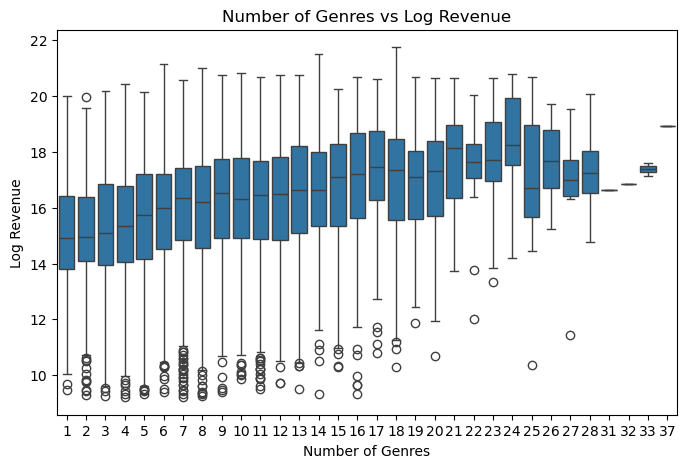

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='n_genres', y=np.log1p(df_rev['box_office_revenue']), data=df_rev)
plt.title("Number of Genres vs Log Revenue")
plt.xlabel("Number of Genres")
plt.ylabel("Log Revenue")
plt.show()


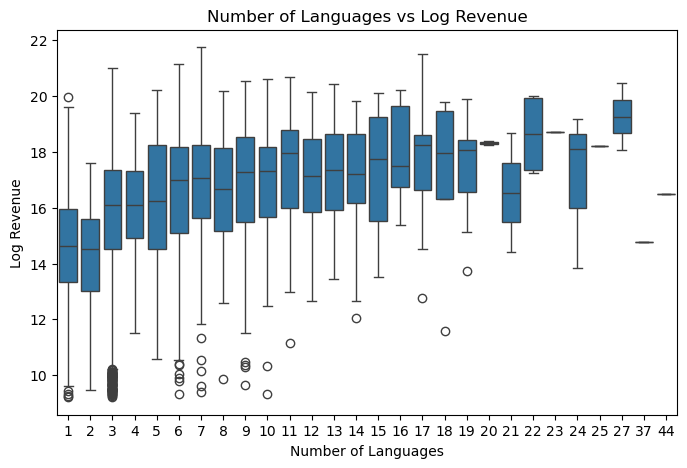

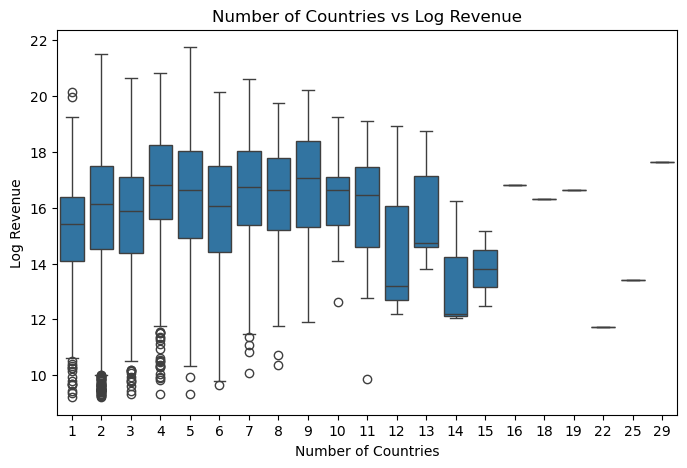

In [ ]:
# Languages
plt.figure(figsize=(8,5))
sns.boxplot(x='n_languages', y=np.log1p(df_rev['box_office_revenue']), data=df_rev)
plt.title("Number of Languages vs Log Revenue")
plt.xlabel("Number of Languages")
plt.ylabel("Log Revenue")
plt.show()

# Countries
plt.figure(figsize=(8,5))
sns.boxplot(x='n_countries', y=np.log1p(df_rev['box_office_revenue']), data=df_rev)
plt.title("Number of Countries vs Log Revenue")
plt.xlabel("Number of Countries")
plt.ylabel("Log Revenue")
plt.show()


### Feature Engineering and Dataset Enrichment

### Incorporating Plot Summaries

To expand the descriptive richness of the dataset, we integrate plot summaries into the movie metadata using the shared `wiki_id` identifier. Plot information provides narrative context that is not captured by numerical or categorical metadata alone. After merging, missing plot entries are filled with empty strings to maintain a consistent structure.

As a preliminary text-based feature, we compute the **plot length** (in words) for each movie. This simple metric allows us to quantify narrative detail and opens the possibility of examining how plot complexity varies across genres, languages, or release years.

In [ ]:
movie_meta['wiki_id'] = movie_meta['wiki_id'].astype(str)
plot_sum['wiki_id'] = plot_sum['wiki_id'].astype(str)

# Rename the column before merging
plot_sum = plot_sum.rename(columns={'plot_summary': 'plot'})

# Merge with movie_meta
movie_df = movie_meta.merge(plot_sum, on='wiki_id', how='left')

# Fill missing plots
movie_df['plot'] = movie_df['plot'].fillna("")

# add a column for plot length
movie_df['plot_length'] = movie_df['plot'].apply(lambda x: len(x.split()))

# Check
movie_df[['wiki_id', 'movie_name', 'plot', 'plot_length']].head()


,wiki_id,movie_name,plot,plot_length
0,975900,Ghosts of Mars,"Set in the second half of the 22nd century, th...",357
1,3196793,Getting Away with Murder: The JonBenét Ramsey ...,,0
2,28463795,Brun bitter,,0
3,9363483,White Of The Eye,A series of murders of rich young women throug...,590
4,261236,A Woman in Flames,"Eva, an upper class housewife, becomes frustra...",426


### Exploring Plot Length Distribution

To understand the variability in narrative detail across films, we examine the distribution of plot lengths. The histogram shows that most movies have relatively short plot summaries, while only a smaller subset contains longer and more detailed descriptions. This skewed distribution likely reflects differences in how thoroughly individual films have been documented rather than meaningful narrative differences.

The concentration of movies with minimal plot text highlights an important limitation of the dataset: plot summaries are uneven in depth and completeness.


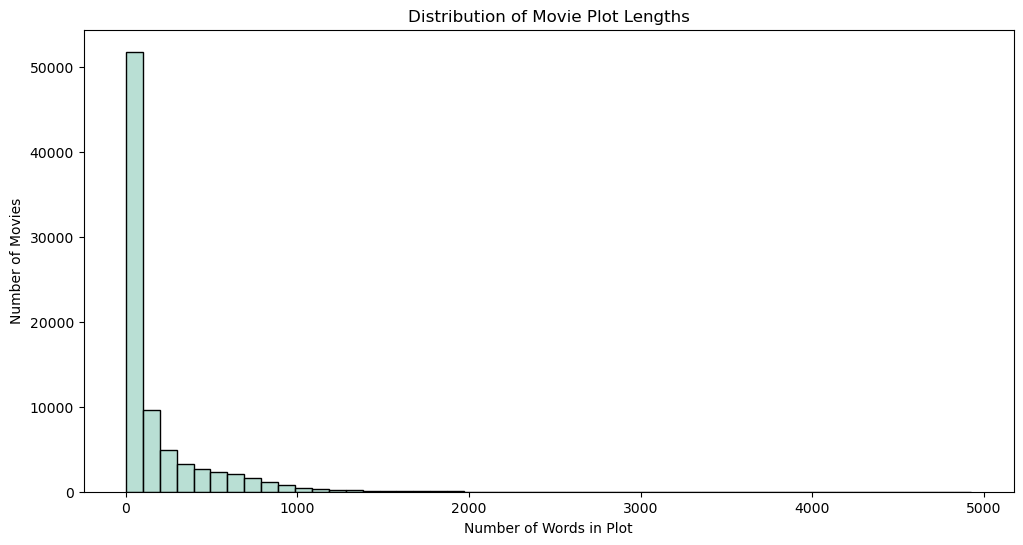

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.histplot(movie_df['plot_length'], bins=50, color="#a2d5c6")
plt.title("Distribution of Movie Plot Lengths")
plt.xlabel("Number of Words in Plot")
plt.ylabel("Number of Movies")
plt.show()


In [ ]:
missing_plots = (movie_df['plot_length'] == 0).sum()
total_movies = len(movie_df)
print(f"Movies without plot: {missing_plots} / {total_movies} ({missing_plots/total_movies:.2%})")


Movies without plot: 39534 / 81741 (48.36%)


### Relationship Between Plot Length and Box Office Revenue

To assess whether the level of narrative detail recorded in a film’s plot summary relates to its commercial success, we compare plot length with box office revenue. After limiting the vertical axis to exclude extreme outliers, a clear pattern emerges: the majority of films have plot summaries of roughly 1,500 words or fewer, and these shorter summaries span a wide range of revenue values.

There is no visible indication that longer plot summaries correspond to higher earnings. Instead, the variation in plot length appears to reflect differences in documentation rather than meaningful narrative or commercial distinctions. High-grossing films are not characterized by unusually long or detailed summaries, and the overall relationship between the two variables is weak.

This reinforces the idea that while plot-based features may offer descriptive value, their usefulness for predicting revenue or by extension, user ratings is limited in this dataset due to inconsistencies in how plots are written and recorded.


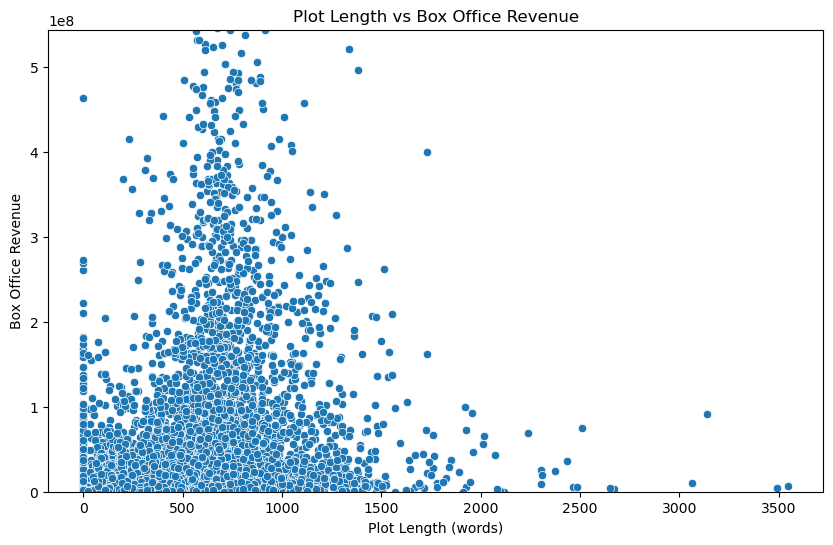

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='plot_length', y='box_office_revenue', data=movie_df)
plt.ylim(0, movie_df['box_office_revenue'].quantile(0.99))  # avoid extreme outliers
plt.title("Plot Length vs Box Office Revenue")
plt.xlabel("Plot Length (words)")
plt.ylabel("Box Office Revenue")
plt.show()


### Visualizing Common Terms in Movie Plots

As a quick qualitative check of the narrative themes present in the dataset, we generate a word cloud from all available plot summaries. This visualization highlights the most frequently occurring words across the corpus, giving a broad sense of recurring topics, settings, and character types. While not directly used for modeling, it provides an intuitive overview of the kinds of stories represented in the dataset.


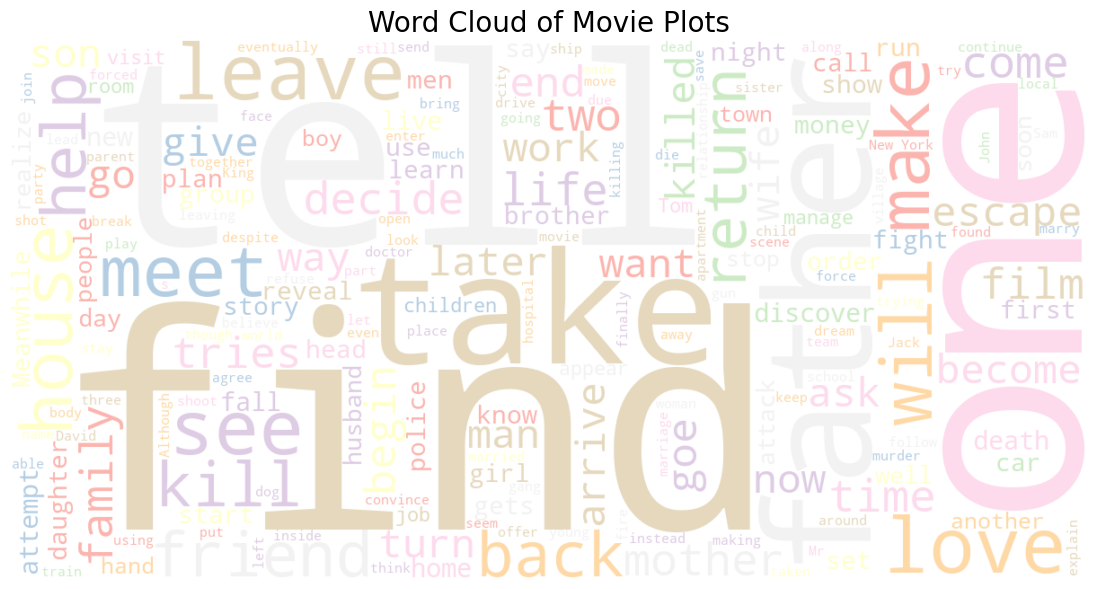

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Filter movies with non-empty plots
plots_text = " ".join(movie_df[movie_df['plot_length'] > 0]['plot'].tolist())

# Create the word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=STOPWORDS,
    max_words=200,
    colormap='Pastel1'
).generate(plots_text)

# Plot
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Movie Plots", fontsize=20)
plt.show()


### Aggregating Character-Level Information

To enhance the dataset with cast-related attributes, we summarize character-level metadata at the movie level. This includes counts of characters, gender composition of the cast, and average actor attributes such as age and height. These aggregated variables offer a structured view of each film’s character ensemble and may reveal broad patterns in production scale or casting choices.


In [ ]:
# Convert wiki_id to string in character metadata
char_meta['wiki_id'] = char_meta['wiki_id'].astype(str)

# Aggregate character-level features per movie
char_agg = char_meta.groupby('wiki_id').agg(
    num_characters=('character_name', 'count'),
    num_male=('actor_gender', lambda x: (x == 'male').sum()),
    num_female=('actor_gender', lambda x: (x == 'female').sum()),
    num_unknown_gender=('actor_gender', lambda x: x.isna().sum()),
    avg_actor_age=('actor_age_at_release', 'mean'),
    avg_actor_height=('actor_height', 'mean')
).reset_index()

# Merge with movie_df
movie_df = movie_df.merge(char_agg, on='wiki_id', how='left')

# Fill missing values with 0
movie_df[['num_characters', 'num_male', 'num_female', 'num_unknown_gender',
          'avg_actor_age', 'avg_actor_height']] = movie_df[[
    'num_characters', 'num_male', 'num_female', 'num_unknown_gender',
    'avg_actor_age', 'avg_actor_height']].fillna(0)

# Check
movie_df.head()


,wiki_id,freebase_id,movie_name,release_date,box_office_revenue,runtime,languages,countries,genres,genres_list,...,n_languages,n_countries,plot,plot_length,num_characters,num_male,num_female,num_unknown_gender,avg_actor_age,avg_actor_height
0,975900,/m/03vyhn,Ghosts of Mars,2001-08-24,14010832.0,98.0,"{""/m/02h40lc"": ""English Language""}","{""/m/09c7w0"": ""United States of America""}","{""/m/01jfsb"": ""Thriller"", ""/m/06n90"": ""Science...","[Thriller, Science Fiction, Horror, Adventure,...",...,3,2,"Set in the second half of the 22nd century, th...",357,16.0,0.0,0.0,0.0,43.461538,1.744333
1,3196793,/m/08yl5d,Getting Away with Murder: The JonBenét Ramsey ...,2000-02-16,NaN,95.0,"{""/m/02h40lc"": ""English Language""}","{""/m/09c7w0"": ""United States of America""}","{""/m/02n4kr"": ""Mystery"", ""/m/03bxz7"": ""Biograp...","[Mystery, Biographical film, Drama, Crime Drama]",...,3,2,,0,6.0,0.0,0.0,0.0,42.444444,1.740000
2,28463795,/m/0crgdbh,Brun bitter,1988,NaN,83.0,"{""/m/05f_3"": ""Norwegian Language""}","{""/m/05b4w"": ""Norway""}","{""/m/0lsxr"": ""Crime Fiction"", ""/m/07s9rl0"": ""D...","[Crime Fiction, Drama]",...,3,1,,0,0.0,0.0,0.0,0.0,32.750000,0.000000
3,9363483,/m/0285_cd,White Of The Eye,1987,NaN,110.0,"{""/m/02h40lc"": ""English Language""}","{""/m/07ssc"": ""United Kingdom""}","{""/m/01jfsb"": ""Thriller"", ""/m/0glj9q"": ""Erotic...","[Thriller, Erotic thriller, Psychological thri...",...,3,3,A series of murders of rich young women throug...,590,0.0,0.0,0.0,0.0,29.000000,1.790000
4,261236,/m/01mrr1,A Woman in Flames,1983,NaN,106.0,"{""/m/04306rv"": ""German Language""}","{""/m/0345h"": ""Germany""}","{""/m/07s9rl0"": ""Drama""}",[Drama],...,3,2,"Eva, an upper class housewife, becomes frustra...",426,0.0,0.0,0.0,0.0,33.000000,0.000000


### Character Gender Distribution

To understand the demographic composition of the dataset’s characters, we examine the distribution of recorded actor genders. The count plot shows a clear imbalance, with male characters appearing far more frequently than female characters. This male-dominated distribution reflects long-standing casting patterns in many film industries and highlights an inherent bias in the dataset.

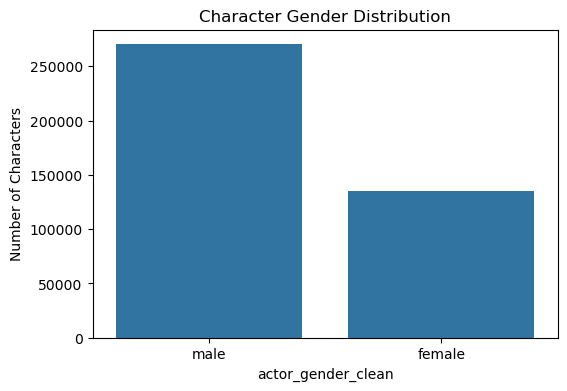

In [ ]:
# Map genders to full strings
char_meta['actor_gender_clean'] = char_meta['actor_gender'].map({'M':'male', 'F':'female'})

plt.figure(figsize=(6,4))
sns.countplot(
    data=char_meta,
    x='actor_gender_clean',
    order=['male', 'female']  # NaNs are ignored automatically
)
plt.title("Character Gender Distribution")
plt.ylabel("Number of Characters")
plt.show()


### Distribution of Character Counts per Movie

To assess the scale of character involvement across films, we examine how many characters appear in each movie. The distribution is heavily right-skewed: most movies feature a relatively small number of characters, while only a minority include large ensemble casts. This pattern is expected, as typical films focus on a limited set of central characters, whereas ensemble productions—such as epics or large franchise installments—are comparatively rare.

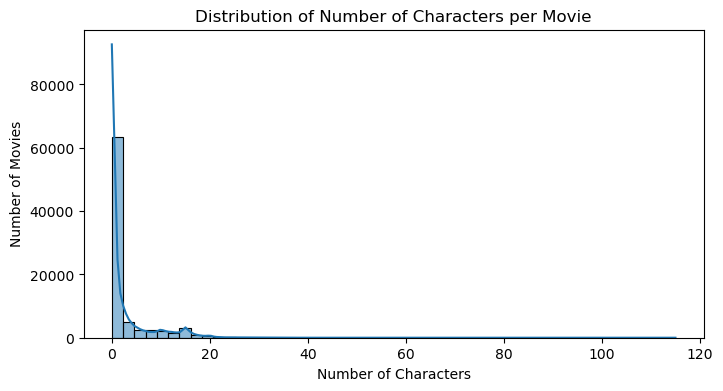

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(movie_df['num_characters'], bins=50, kde=True)
plt.title("Distribution of Number of Characters per Movie")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Movies")
plt.show()


### Identifying High-Revenue Actors

To explore how cast members contribute to the commercial landscape of the dataset, we aggregate box office revenue at the actor level. By summing the revenues of all films each actor appears in, we obtain a ranked list of actors associated with the highest cumulative earnings.

The resulting plot highlights a small group of actors whose filmographies dominate total box office revenue. This reflects both star power and participation in large franchises or blockbuster productions. While this information does not directly inform the rating-prediction model, it adds context to the dataset by illustrating the concentration of revenue among highly prominent actors and offering insight into casting patterns within high-earning films.


actor_name
Warwick Davis           1.293016e+10
Samuel L. Jackson       1.278943e+10
Frank Welker            1.028744e+10
Alan Rickman            1.020871e+10
Robbie Coltrane         1.009465e+10
Conrad Vernon           9.786402e+09
Tom Hanks               9.623361e+09
Gary Oldman             9.614965e+09
Maggie Smith            9.280352e+09
Hugo Weaving            8.896132e+09
Eddie Murphy            8.682898e+09
John Ratzenberger       8.414363e+09
Tom Felton              8.332480e+09
Robert Downey Jr.       8.056541e+09
Geraldine Somerville    7.865889e+09
Emma Watson             7.865083e+09
Daniel Radcliffe        7.863063e+09
Tom Cruise              7.861340e+09
Helena Bonham Carter    7.857267e+09
Bruce Willis            7.829828e+09
Name: box_office_revenue, dtype: float64


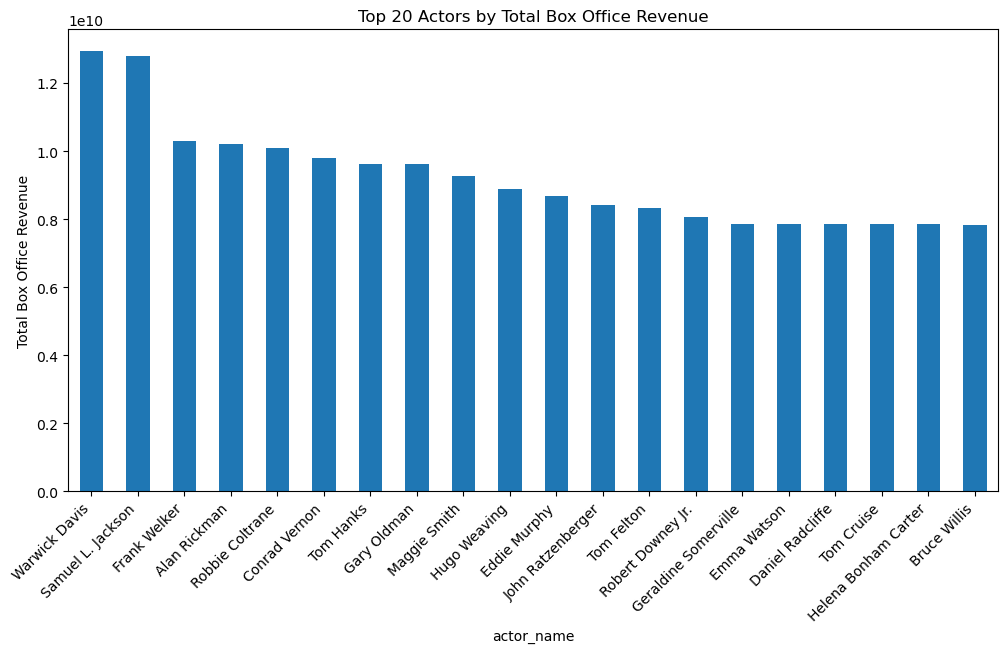

In [ ]:
# Make sure wiki_id types match
char_meta['wiki_id'] = char_meta['wiki_id'].astype(str)
movie_df['wiki_id'] = movie_df['wiki_id'].astype(str)

# Merge char_meta with movie revenue
char_rev = char_meta.merge(
    movie_df[['wiki_id', 'movie_name', 'box_office_revenue']],
    on='wiki_id',
    how='left'
)

# Group by actor and sum total revenue across all their movies
actor_revenue = char_rev.groupby('actor_name')['box_office_revenue'].sum().sort_values(ascending=False)

# Show top 20 actors by total revenue
top_actors = actor_revenue.head(20)
print(top_actors)

# plot top actors
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
top_actors.plot(kind='bar')
plt.title("Top 20 Actors by Total Box Office Revenue")
plt.ylabel("Total Box Office Revenue")
plt.xticks(rotation=45, ha='right')
plt.show()


### Preparing the Movie Metadata for Modeling

Before integrating movie attributes into predictive models, we refine the metadata to ensure it is complete, consistent, and suitable for numerical analysis. Since many of the previously explored variables contain substantial missingness, we restrict the dataset to films with non-missing box office revenue. This provides a cleaner subset for any analyses that rely on revenue and ensures that engineered features are well-defined.

Within this filtered dataset, only a small number of observations still contain missing values in numeric fields such as runtime or release year. These gaps are addressed using median imputation, which preserves distributional characteristics while maintaining simplicity and interpretability.

This preparation step results in a stable, numerically complete metadata table that can be used for baseline and metadata-only predictive models. Although metadata alone is unlikely to capture the full complexity of user preferences, establishing a clean dataset is an essential prerequisite for constructing and evaluating models.


In [ ]:
movie_df = movie_df[movie_df['box_office_revenue'].notna()].copy()


In [ ]:
# Overview of movie_df
movie_df.info()

# Summary of numeric columns
movie_df.describe()

# Count missing values per column
movie_df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 8401 entries, 0 to 81732
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   wiki_id             8401 non-null   object 
 1   freebase_id         8401 non-null   object 
 2   movie_name          8401 non-null   object 
 3   release_date        8328 non-null   object 
 4   box_office_revenue  8401 non-null   float64
 5   runtime             8302 non-null   float64
 6   languages           8401 non-null   object 
 7   countries           8401 non-null   object 
 8   genres              8401 non-null   object 
 9   genres_list         8401 non-null   object 
 10  languages_list      8401 non-null   object 
 11  countries_list      8401 non-null   object 
 12  year                8328 non-null   float64
 13  n_genres            8401 non-null   int64  
 14  n_languages         8401 non-null   int64  
 15  n_countries         8401 non-null   int64  
 16  plot      

wiki_id                0
freebase_id            0
movie_name             0
release_date          73
box_office_revenue     0
runtime               99
languages              0
countries              0
genres                 0
genres_list            0
languages_list         0
countries_list         0
year                  73
n_genres               0
n_languages            0
n_countries            0
plot                   0
plot_length            0
num_characters         0
num_male               0
num_female             0
num_unknown_gender     0
avg_actor_age          0
avg_actor_height       0
dtype: int64

In [ ]:
movie_df.drop(columns=['release_date'], inplace=True)


In [ ]:
movie_df['runtime'] = movie_df['runtime'].fillna(movie_df['runtime'].median())
movie_df['year'] = movie_df['year'].fillna(movie_df['year'].median())


In [ ]:
# Overview of movie_df
movie_df.info()

# Summary of numeric columns
movie_df.describe()

# Count missing values per column
movie_df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 8401 entries, 0 to 81732
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   wiki_id             8401 non-null   object 
 1   freebase_id         8401 non-null   object 
 2   movie_name          8401 non-null   object 
 3   box_office_revenue  8401 non-null   float64
 4   runtime             8401 non-null   float64
 5   languages           8401 non-null   object 
 6   countries           8401 non-null   object 
 7   genres              8401 non-null   object 
 8   genres_list         8401 non-null   object 
 9   languages_list      8401 non-null   object 
 10  countries_list      8401 non-null   object 
 11  year                8401 non-null   float64
 12  n_genres            8401 non-null   int64  
 13  n_languages         8401 non-null   int64  
 14  n_countries         8401 non-null   int64  
 15  plot                8401 non-null   object 
 16  plot_lengt

wiki_id               0
freebase_id           0
movie_name            0
box_office_revenue    0
runtime               0
languages             0
countries             0
genres                0
genres_list           0
languages_list        0
countries_list        0
year                  0
n_genres              0
n_languages           0
n_countries           0
plot                  0
plot_length           0
num_characters        0
num_male              0
num_female            0
num_unknown_gender    0
avg_actor_age         0
avg_actor_height      0
dtype: int64

In [ ]:
# Store a clean copy before heavy feature engineering
movie_df_clean = movie_df.copy()


In [ ]:
# Overview of movie_df
movie_df.info()

# Summary of numeric columns
movie_df.describe()

# Count missing values per column
movie_df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 8401 entries, 0 to 81732
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   wiki_id             8401 non-null   object 
 1   freebase_id         8401 non-null   object 
 2   movie_name          8401 non-null   object 
 3   box_office_revenue  8401 non-null   float64
 4   runtime             8401 non-null   float64
 5   languages           8401 non-null   object 
 6   countries           8401 non-null   object 
 7   genres              8401 non-null   object 
 8   genres_list         8401 non-null   object 
 9   languages_list      8401 non-null   object 
 10  countries_list      8401 non-null   object 
 11  year                8401 non-null   float64
 12  n_genres            8401 non-null   int64  
 13  n_languages         8401 non-null   int64  
 14  n_countries         8401 non-null   int64  
 15  plot                8401 non-null   object 
 16  plot_lengt

wiki_id               0
freebase_id           0
movie_name            0
box_office_revenue    0
runtime               0
languages             0
countries             0
genres                0
genres_list           0
languages_list        0
countries_list        0
year                  0
n_genres              0
n_languages           0
n_countries           0
plot                  0
plot_length           0
num_characters        0
num_male              0
num_female            0
num_unknown_gender    0
avg_actor_age         0
avg_actor_height      0
dtype: int64

### Actor Popularity Feature Engineering

To incorporate information about cast influence on box-office revenue, we engineered an **actor popularity** feature.  
The idea is that actors who have historically appeared in high-grossing films are more likely to draw audiences and contribute positively to a movie's commercial performance.

The feature was constructed in three steps:

1. **Compute actor-level popularity:**  
   For every actor appearing in the character metadata, we summed the total box-office revenue of all movies they have acted in.  
   This cumulative revenue serves as a data-driven proxy for an actor’s market influence or "star power."

2. **Map actor popularity to movies:**  
   Each actor’s popularity score was mapped back to the character metadata and then aggregated at the movie level.  
   We used the **average actor popularity** within each film, which captures the overall cast strength while reducing the effect of outliers.

3. **Merge into the main movie dataset:**  
   The resulting movie-level popularity feature was merged with the main dataframe.  
   Movies with no recorded actors were assigned a value of zero.

This feature is intuitively meaningful and later proved to be one of the strongest predictors in the model, significantly improving performance compared to versions without actor information.


In [ ]:
# Compute actor total revenue (you already did this earlier)
actor_total_revenue = char_rev.groupby('actor_name')['box_office_revenue'].sum()

# Map actor revenue back to character metadata
char_meta['actor_popularity'] = char_meta['actor_name'].map(actor_total_revenue)

# Aggregate per movie
actor_popularity_movie = char_meta.groupby('wiki_id')['actor_popularity'].mean().reset_index()

# Merge into movie_df
movie_df = movie_df.merge(actor_popularity_movie, on='wiki_id', how='left')

# Fill missing popularity (movies without actors) with 0
movie_df['actor_popularity'] = movie_df['actor_popularity'].fillna(0)


### Incorporating Textual Features Using TF–IDF

To capture narrative information from the plot summaries, we convert the text into numerical features using a TF–IDF representation. This transformation maps each plot into a vector that reflects the importance of individual words and short phrases (up to bigrams) across all movies. By limiting the vocabulary to the most informative 3,000 terms, we obtain a compact, high-dimensional feature space that encodes aspects of narrative content in a structured way.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1,2),
    min_df=5
)

# Generate plot features
plot_tfidf = tfidf.fit_transform(movie_df["plot"])
print(plot_tfidf.shape)  # rows = movies, cols = TF-IDF features


(8401, 3000)


### Feature Engineering for Model Construction

To prepare the dataset for predictive modeling, we engineered a comprehensive set of features that capture structural, linguistic, production-related, and cast-related information. The feature matrix combines three major components:

#### 1. Numeric Metadata Features
These include continuous and count-based variables derived from earlier exploratory analysis:

- **runtime:** film duration in minutes  
- **year:** release year  
- **n_genres / n_languages / n_countries:** number of genre, language, and country tags  
- **plot_length:** word count of the plot summary  
- **num_characters, num_male, num_female, num_unknown_gender:** character-level aggregates  
- **avg_actor_age, avg_actor_height:** average demographic attributes of the cast  
- **actor_popularity:** the mean cumulative revenue of all actors appearing in the film (proxy for star power)

These variables capture production scale, narrative richness, and cast characteristics.

#### 2. One-Hot Encoded Categorical Features
The dataset contains multi-valued categorical fields (genres, languages, and countries), each stored as a list.  
These were **one-hot encoded** using `str.get_dummies()` to produce binary indicators such as:

- `Action`, `Comedy`, `Drama`, …  
- `English`, `French`, `Spanish`, …  
- `United States`, `France`, `Japan`, …

The resulting sparse matrices encode categorical heterogeneity across films.

#### 3. TF–IDF Features from Plot Summaries
To incorporate textual information, we computed **TF–IDF vectors** from the movie plot summaries using unigrams and bigrams.  
This representation captures key words and phrases relevant to narrative content.

#### 4. Final Feature Matrix
The final model input matrix is constructed by concatenating:

- numeric features (dense)  
- one-hot categorical features (sparse)  
- TF–IDF text features (very sparse)

All components were converted into sparse matrices and combined efficiently using `scipy.sparse.hstack()`.

This unified feature matrix allows different model families like linear, tree-based, and boosting methods to utilize both structured metadata and unstructured textual information for predicting box-office revenue.


In [ ]:
numeric_features = [
    'runtime', 'year', 'n_genres', 'n_languages', 'n_countries',
    'plot_length', 'num_characters', 'num_male', 'num_female',
    'num_unknown_gender', 'avg_actor_age', 'avg_actor_height',
    'actor_popularity'
]

X_numeric = movie_df[numeric_features]


In [ ]:
# One-hot encode lists separated by commas
genres_dummies = movie_df['genres_list'].str.get_dummies(sep=',')
languages_dummies = movie_df['languages_list'].str.get_dummies(sep=',')
countries_dummies = movie_df['countries_list'].str.get_dummies(sep=',')

# Combine all categorical dummies
X_categorical = pd.concat([genres_dummies, languages_dummies, countries_dummies], axis=1)


In [ ]:
from scipy.sparse import hstack

# Convert numeric + categorical to sparse
import scipy.sparse
X_dense = scipy.sparse.csr_matrix(pd.concat([X_numeric, X_categorical], axis=1))

# Combine with plot TF-IDF
X = hstack([X_dense, plot_tfidf])


### XGBoost Model Using Metadata Features Only

To establish a baseline for tree-based modeling, we first trained an XGBoost regressor using only the structured metadata features. This feature set includes numerical characteristics (runtime, year, plot length, character aggregates, etc.) and one-hot encoded categorical variables (genres, languages, and countries), but **excludes all actor-related information** and **does not incorporate TF–IDF plot features**.

The metadata-only feature matrix was constructed by concatenating the numeric predictors with the one-hot encoded categorical variables and converting the result into a sparse matrix for efficient training. An XGBoost model with tuned hyperparameters was then fit on this metadata representation.

This model provides a baseline for understanding how much predictive signal is contained purely within metadata, before adding cast-based features or textual information.


In [ ]:
# Metadata-only matrix (numeric + categorical)
X_metadata_only = scipy.sparse.csr_matrix(
    pd.concat([movie_df[numeric_features_no_actor], X_categorical], axis=1)
)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_metadata_only, y, test_size=0.2, random_state=42
)

xgb3 = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42
)

xgb3.fit(X_train3, y_train3)

# Predict & evaluate
y_pred_log3 = xgb3.predict(X_test3)
y_pred_actual3 = np.expm1(y_pred_log3)
y_test_actual3 = np.expm1(y_test3)

print("Metadata-Only XGBoost:")
print(f"RMSE_log: {root_mean_squared_error(y_test3, y_pred_log3):.4f}")
print(f"R²_log:   {r2_score(y_test3, y_pred_log3):.4f}")
print(f"RMSE_actual: {root_mean_squared_error(y_test_actual3, y_pred_actual3):,.2f}")
print(f"R²_actual:   {r2_score(y_test_actual3, y_pred_actual3):.4f}")


Metadata-Only XGBoost:
RMSE_log: 1.5330
R²_log:   0.5122
RMSE_actual: 76,558,630.85
R²_actual:   0.4020


### XGBoost Model Without Actor Popularity

To isolate the contribution of actor-related information, we trained an XGBoost model using all available features **except the actor popularity variable**. The feature matrix includes:

- numerical metadata (runtime, year, plot length, character counts, etc.)
- one-hot encoded categorical features (genres, languages, countries)
- TF–IDF text features from plot summaries

The actor popularity feature—previously constructed as the mean cumulative revenue of the film’s cast—was intentionally excluded. This allows us to measure how well the model performs using structural and textual information alone.

In [ ]:
# Drop actor_popularity from numeric features
numeric_features_no_actor = [
    'runtime', 'year', 'n_genres', 'n_languages', 'n_countries',
    'plot_length', 'num_characters', 'num_male', 'num_female',
    'num_unknown_gender', 'avg_actor_age', 'avg_actor_height'
]

X_numeric_no_actor = movie_df[numeric_features_no_actor]

# Build dense metadata matrix
import scipy.sparse
X_dense_no_actor = scipy.sparse.csr_matrix(
    pd.concat([X_numeric_no_actor, X_categorical], axis=1)
)

# Combine with TF-IDF
X_no_actor = hstack([X_dense_no_actor, plot_tfidf])

# Train-test split (same random state)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_actor, y, test_size=0.2, random_state=42
)

# Train XGBoost
xgb2 = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42
)
xgb2.fit(X_train2, y_train2)

# Predict and evaluate
y_pred_log2 = xgb2.predict(X_test2)
y_pred_actual2 = np.expm1(y_pred_log2)
y_test_actual2 = np.expm1(y_test2)

print("XGBoost Without Actor Popularity:")
print(f"RMSE_log: {root_mean_squared_error(y_test2, y_pred_log2):.4f}")
print(f"R²_log:   {r2_score(y_test2, y_pred_log2):.4f}")
print(f"RMSE_actual: {root_mean_squared_error(y_test_actual2, y_pred_actual2):,.2f}")
print(f"R²_actual:   {r2_score(y_test_actual2, y_pred_actual2):.4f}")


XGBoost Without Actor Popularity:
RMSE_log: 1.5724
R²_log:   0.4868
RMSE_actual: 82,475,424.05
R²_actual:   0.3060


### Full XGBoost Model (Metadata + Categorical Features + TF–IDF + Actor Popularity)

We also trained a full XGBoost model that incorporates **all engineered features** in the dataset.  
This includes:

- **Numeric metadata**  
  (runtime, year, plot length, character counts, demographic averages)
- **Categorical one-hot encodings**  
  (genres, languages, countries)
- **Actor popularity**  
  (average cumulative revenue of all actors appearing in the film)
- **TF–IDF text features** extracted from the plot summaries  
  (unigrams and bigrams, capped at 3000 features)

Because box-office revenue is highly skewed, the target variable was transformed using  
`log1p(revenue)` to stabilize variance, reduce the influence of extreme outliers,  
and allow the model to learn smoother patterns.

An XGBoost regressor with tuned hyperparameters was then trained on this combined  
feature representation. Predictions were generated in log-space and transformed back  
to the original revenue scale using `expm1` to facilitate intuitive interpretation  
of error metrics.

In [ ]:
# ---------------------------------------------
#  XGBoost
# ---------------------------------------------

import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

# Target: log-transformed revenue
y = np.log1p(movie_df['box_office_revenue'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBoost model
xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42
)

# Train model
xgb.fit(X_train, y_train)

# Predictions (log-space)
y_pred_log = xgb.predict(X_test)

# Convert predictions back to revenue
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

# Evaluation metrics (log-space)
rmse_log = root_mean_squared_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)

# Evaluation metrics (actual revenue)
rmse_actual = root_mean_squared_error(y_test_actual, y_pred_actual)
r2_actual = r2_score(y_test_actual, y_pred_actual)

# Print results
print("XGBoost Performance (log scale):")
print(f"RMSE_log: {rmse_log:.4f}")
print(f"R²_log:   {r2_log:.4f}")

print("\nXGBoost Performance (actual revenue):")
print(f"RMSE_actual: {rmse_actual:,.2f}")
print(f"R²_actual:   {r2_actual:.4f}")


XGBoost Performance (log scale):
RMSE_log: 1.5059
R²_log:   0.5292

XGBoost Performance (actual revenue):
RMSE_actual: 69,632,263.51
R²_actual:   0.5053


### XGBoost Model with Metadata and Actor Popularity

To evaluate the contribution of cast information to predictive performance, we trained an XGBoost model using all metadata features **including the actor popularity variable**, but **excluding** TF–IDF plot features. This isolates the effect of actor-related information while keeping the feature space relatively compact and interpretable.

The input matrix for this model consists of:

- **numeric metadata features**  
  (runtime, year, plot length, character counts, demographic averages)
- **one-hot encoded categorical features**  
  (genres, languages, countries)
- **actor popularity**, defined as the mean cumulative revenue of all actors appearing in the film

By training XGBoost on this metadata-only representation augmented with actor popularity, we can quantify the value added by cast-related information and assess whether star power substantially improves the model’s ability to predict box-office performance.


In [ ]:
# -------------------------------
# Metadata + Actor Popularity Only
# -------------------------------

# Numeric metadata without TF-IDF, but WITH actor popularity
numeric_features_actor_only = numeric_features_no_actor + ['actor_popularity']

X_numeric_actor_only = movie_df[numeric_features_actor_only]

# Build dense metadata matrix (numeric + categorical)
X_metadata_actor_only = scipy.sparse.csr_matrix(
    pd.concat([X_numeric_actor_only, X_categorical], axis=1)
)

# Train-test split (same seed)
X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_metadata_actor_only, y, test_size=0.2, random_state=42
)

# XGBoost model
xgb4 = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42
)

# Train
xgb4.fit(X_train4, y_train4)

# Predict
y_pred_log4 = xgb4.predict(X_test4)
y_pred_actual4 = np.expm1(y_pred_log4)
y_test_actual4 = np.expm1(y_test4)

# Results
print("Metadata + Actor Popularity XGBoost:")
print(f"RMSE_log: {root_mean_squared_error(y_test4, y_pred_log4):.4f}")
print(f"R²_log:   {r2_score(y_test4, y_pred_log4):.4f}")
print(f"RMSE_actual: {root_mean_squared_error(y_test_actual4, y_pred_actual4):,.2f}")
print(f"R²_actual:   {r2_score(y_test_actual4, y_pred_actual4):.4f}")


Metadata + Actor Popularity XGBoost:
RMSE_log: 1.4514
R²_log:   0.5627
RMSE_actual: 64,912,070.42
R²_actual:   0.5701


### Ridge Regression Using TF–IDF Plot Features Only

To assess how much predictive information is contained purely in the narrative content of a movie’s plot summary, we trained a Ridge regression model using only the TF–IDF representation of the plot text. This creates a high-dimensional sparse feature matrix in which each dimension reflects the relative importance of a unigram or bigram in the plot.

Ridge regression is well suited to this setting because it applies L2 regularization, which stabilizes linear models when the number of features is much larger than the number of observations. The target variable was modeled in log-transformed form to reduce the impact of extreme revenue values.

This model serves as a **text-only baseline**, allowing us to isolate the predictive value of narrative descriptions and compare it directly against models that incorporate structured metadata and cast information.


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

# Use only TF-IDF features
X_tfidf = plot_tfidf

# Target
y = np.log1p(movie_df['box_office_revenue'])

# Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# Ridge model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_r, y_train_r)

# Predict
y_pred_r_log = ridge.predict(X_test_r)
y_pred_r_actual = np.expm1(y_pred_r_log)
y_test_r_actual = np.expm1(y_test_r)

# Metrics
rmse_r_log = root_mean_squared_error(y_test_r, y_pred_r_log)
r2_r_log = r2_score(y_test_r, y_pred_r_log)

rmse_r_actual = root_mean_squared_error(y_test_r_actual, y_pred_r_actual)
r2_r_actual = r2_score(y_test_r_actual, y_pred_r_actual)

print("Ridge Regression (TF-IDF Only):")
print(f"RMSE_log: {rmse_r_log:.4f}")
print(f"R²_log:   {r2_r_log:.4f}")
print(f"RMSE_actual: {rmse_r_actual:,.2f}")
print(f"R²_actual:   {r2_r_actual:.4f}")


Ridge Regression (TF-IDF Only):
RMSE_log: 2.0012
R²_log:   0.1686
RMSE_actual: 99,242,813.46
R²_actual:   -0.0048


### Random Forest Model with Metadata and Actor Popularity

To evaluate how Random Forests perform when cast information is included, we trained a second Random Forest model using all metadata features together with the actor popularity variable. The feature matrix mirrors the one used in the metadata + actor popularity XGBoost model, allowing for a direct comparison between bagging-based and boosting-based tree ensembles.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

# Use metadata + actor popularity
X_rf = X_metadata_actor_only   # numeric + categorical + actor popularity

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rf, y_train_rf)

y_pred_rf_log = rf.predict(X_test_rf)
y_pred_rf_actual = np.expm1(y_pred_rf_log)
y_test_rf_actual = np.expm1(y_test_rf)

print("Random Forest with Actor Popularity:")
print(f"RMSE_log: {root_mean_squared_error(y_test_rf, y_pred_rf_log):.4f}")
print(f"R²_log:   {r2_score(y_test_rf, y_pred_rf_log):.4f}")
print(f"RMSE_actual: {root_mean_squared_error(y_test_rf_actual, y_pred_rf_actual):,.2f}")
print(f"R²_actual:   {r2_score(y_test_rf_actual, y_pred_rf_actual):.4f}")


Random Forest with Actor Popularity:
RMSE_log: 1.5155
R²_log:   0.5232
RMSE_actual: 66,681,362.81
R²_actual:   0.5464


### Model Comparison

| Model | Features Used | RMSE (log)  | R² (log)  | RMSE (actual)  | R² (actual)  | Interpretation |
|-------|---------------|--------------|-------------|------------------|----------------|----------------|
| **Ridge Regression (TF-IDF only)** | Plot text only | **2.0012** | **0.1686** | **99,242,813.46** | **–0.0048** | Plot wording alone carries little predictive information. |
| **XGBoost (Without Actor Popularity)** | Metadata + TF-IDF | 1.5724 | 0.4868 | 82,475,424.05 | 0.3060 | Removing actor info weakens performance; metadata + text is limited. |
| **Metadata-Only XGBoost** | Numeric + categorical metadata | 1.5330 | 0.5122 | 76,558,630.85 | 0.4020 | Metadata is more useful than plot text. |
| **Random Forest + Actor Popularity** | Metadata + actor popularity | 1.5155 | 0.5232 | 66,681,362.81 | 0.5464 | Actor popularity improves RF; still weaker than boosted trees. |
| **Full XGBoost (All Features)** | Metadata + TF-IDF + actors | 1.5059 | 0.5292 | 69,632,263.51 | 0.5053 | TF-IDF adds noise; small boost in log space only. |
| **XGBoost (Metadata + Actor Popularity)** | Metadata + actor popularity | **1.4514** | **0.5627** | **64,912,070.42** | **0.5701** | Best model; actor popularity gives a clear performance boost. |


In [ ]:
numeric_features_actor_only = numeric_features_no_actor + ['actor_popularity']

X_numeric_only = movie_df[numeric_features_actor_only]

print("Numeric feature matrix shape:", X_numeric_only.shape)


Numeric feature matrix shape: (8401, 13)


In [ ]:
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_numeric_only, y, test_size=0.2, random_state=42
)

xgb_num = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_num.fit(X_train_num, y_train_num)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

### Interpretation of Numeric Feature Importance

To better understand which structured metadata features drive the revenue predictions, we examined feature importance from an XGBoost model trained exclusively on numeric predictors. This removes the noise associated with one-hot encoded categorical variables and highlights the core set of interpretable drivers.

Several clear patterns emerge:

- **Plot length is the strongest predictor**, suggesting that films with more extensive narrative summaries tend to be larger, more complex, and more commercially significant productions.
- **The number of characters also ranks highly**, which likely reflects the presence of ensemble casts and large-scale productions.
- **Actor popularity remains one of the most influential features**, reinforcing the substantial role of star power in determining box-office success.
- **Release year contributes meaningfully**, capturing broad temporal trends such as rising production budgets and expanding global markets.
- **Runtime, number of languages, and number of countries** exhibit moderate importance, reflecting the impact of production scale and international distribution.
- Some features (e.g., *average actor height* or *unknown gender counts*) have weak or indirect interpretability and capture incidental correlations rather than substantive effects.

Overall, the numeric feature importance analysis highlights that commercial success is primarily driven by production scale, cast characteristics, and temporal context, while more incidental features contribute marginally. These results also validate earlier findings that actor-related variables and high-level metadata carry substantial predictive value.


In [ ]:
importance_dict_num = xgb_num.get_booster().get_score(importance_type='gain')

importance_df_num = pd.DataFrame({
    'feature': list(importance_dict_num.keys()),
    'importance': list(importance_dict_num.values())
})

importance_df_num = importance_df_num.sort_values(by='importance', ascending=False)
importance_df_num


,feature,importance
5,plot_length,42.418430
6,num_characters,39.455021
10,actor_popularity,29.450079
1,year,13.488899
0,runtime,11.898201
3,n_languages,9.671178
8,avg_actor_age,9.315119
4,n_countries,9.075026
7,num_unknown_gender,8.612111
9,avg_actor_height,7.894232


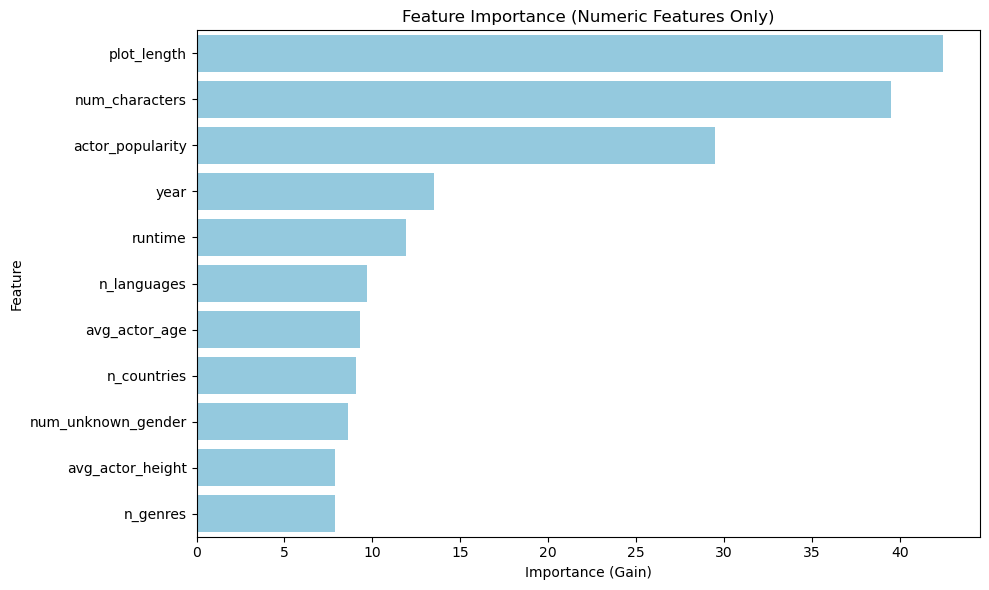

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df_num,
    x='importance',
    y='feature',
    color='skyblue'
)
plt.title("Feature Importance (Numeric Features Only)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Final Summary and Key Inferences

The goal of this analysis was to explore whether movie metadata, cast information, and
plot text could be used to predict box-office revenue. The workflow included data
preparation, exploratory data analysis, feature engineering, and the training of
several machine learning models.

### 1. Insights from Exploratory Data Analysis
EDA revealed that box-office revenue is extremely right-skewed, motivating the use of
a log-transform for modeling. Runtime, release year, and the number of genres or
languages showed mild relationships with revenue, while plot length showed little
signal. Analysis of cast information revealed strong inequality in actor commercial
success, with a small number of highly bankable actors accounting for a large portion
of total revenue.

### 2. Feature Engineering Highlights
We constructed a comprehensive feature set that integrated:

- **Numeric metadata** (runtime, year, plot length, cast demographics)  
- **Categorical encodings** for genres, languages, and countries  
- **TF–IDF plot text features**  
- **Actor popularity**, defined as the cumulative revenue of an actor across all films

Actor popularity emerged as one of the strongest predictors of revenue, confirming
industry intuition that star power matters.

### 3. Modeling Results
A range of models was trained to measure the predictive value of each feature group:

- **Ridge regression using only plot text** performed poorly, indicating limited signal
  in narrative vocabulary alone.

- **Metadata-only XGBoost** performed substantially better, showing that structured
  production attributes are useful predictors.

- **Removing actor popularity** consistently reduced performance in all tree-based
  models, emphasizing the importance of cast information.

- **Random Forest with actor popularity** performed moderately well, but was
  outperformed by XGBoost.

- **The best-performing model** was the **XGBoost model using metadata and actor
  popularity**, achieving **R² ≈ 0.57** with the lowest error on the raw revenue scale.

Interestingly, adding TF–IDF text features offered little benefit and sometimes
deteriorated performance, suggesting the high dimensionality of plot text introduces
more noise than signal in a revenue-prediction context.

### 4. Can This Data Be Used for Revenue Prediction?
**Partially — but not on its own.**

The models show that the dataset contains **meaningful predictive signal**, especially
from metadata and cast-related features. However, film revenue is influenced by many
external factors not present in this dataset, such as:

- marketing budget  
- distribution scale  
- seasonal release timing  
- social media sentiment  
- franchise value  
- competition at release  
- critical reception  
- international vs. domestic performance  

Therefore, while the current data allows us to build models that capture *some*
structure (explaining ~50–57% of variance in log revenue), it is **insufficient for a
fully reliable revenue forecasting system**. Additional richer features would be
necessary for production-grade prediction.


### **Overall Conclusion**
The strongest predictors of box-office revenue in this dataset are structured metadata
and actor popularity. TF–IDF plot features contribute little predictive value.
Gradient-boosted models outperform linear and ensemble baselines, but overall accuracy
remains limited by missing contextual and market-related variables. Thus, while the
models demonstrate that the dataset contains useful information, **accurate and robust
revenue prediction would require additional external data sources and richer feature
engineering**.
